## VDJdb

In [ ]:
from scipy import stats
from scipy.optimize import minimize

def fit_negative_binomial(counts):
    """
    Fit a Negative Binomial distribution to count data.
    Returns (n, p) parameters.
    
    Negative Binomial is parameterized as:
    - n: number of successes
    - p: probability of success
    Mean = n(1-p)/p, Variance = n(1-p)/p^2
    """
    counts = np.array(counts)
    if len(counts) == 0 or np.all(counts == 0):
        # Return a default flat distribution
        return 1, 0.5
    
    mean = np.mean(counts)
    var = np.var(counts)
    
    # Handle edge cases
    if var <= mean or mean == 0:
        # Use Poisson-like parameters
        return max(mean, 0.1), 0.5
    
    # Method of moments estimators
    p = mean / var
    n = mean * p / (1 - p)
    
    # Ensure valid parameters
    n = max(n, 0.1)
    p = np.clip(p, 0.01, 0.99)
    
    return n, p


def compute_probabilistic_binding_scores(data_df, tcr_col='cell_clono_cdr3_aa'):
    """
    Compute probabilistic binding scores for each cell and epitope.
    
    For each cell:
    1. Fit a Negative Binomial distribution to negative control UMI counts
    2. For each specific dextramer, compute P(UMI >= observed | noise)
    3. Binding score = 1 - P(UMI >= observed | noise)
    
    Parameters:
    -----------
    data_df : pd.DataFrame
        The binarized matrix with UMI counts
    tcr_col : str
        Column name for TCR sequences
        
    Returns:
    --------
    scores_df : pd.DataFrame
        DataFrame with cell index, TCR, epitope columns, and binding scores
    """
    
    # Identify column types
    nc_cols = [col for col in data_df.columns 
               if col.endswith('_NC') and not col.endswith('_binder')]
    
    epitope_cols = [col for col in data_df.columns 
                    if any(col.startswith(x) for x in ['A0', 'B0', 'C0'])
                    and not col.endswith('_binder')
                    and not col.endswith('_NC')
                    and col not in ['CD3', 'CD19', 'CD4', 'CD8a', 'CD14', 'CD45RA', 
                                   'CD45RO', 'CD127', 'CD197_CCR7', 'HLA-DR', 'CD279_PD-1']]
    
    print(f"Found {len(nc_cols)} negative control columns")
    print(f"Found {len(epitope_cols)} epitope columns")
    
    # Filter to cells with TCR annotation
    data = data_df[data_df[tcr_col].notna()].copy()
    
    # Convert to numeric
    for col in nc_cols + epitope_cols:
        data[col] = pd.to_numeric(data[col], errors='coerce').fillna(0)
    
    # Compute binding scores for each cell
    binding_scores = []
    
    for idx, row in data.iterrows():
        # Get negative control counts for this cell
        nc_counts = row[nc_cols].values
        
        # Fit Negative Binomial to noise
        n, p = fit_negative_binomial(nc_counts)
        
        # Compute binding score for each epitope
        cell_scores = {'barcode': row.get('barcode', idx), 'TCR': row[tcr_col]}
        
        for epitope in epitope_cols:
            observed_umi = row[epitope]
            
            # P(X >= observed | noise distribution)
            # = 1 - P(X < observed) = 1 - CDF(observed - 1)
            if observed_umi == 0:
                p_value = 1.0
            else:
                p_value = 1 - stats.nbinom.cdf(observed_umi - 1, n, p)
            
            # Binding score: probability that this is NOT noise
            binding_score = 1 - p_value
            cell_scores[epitope] = binding_score
        
        binding_scores.append(cell_scores)
    
    scores_df = pd.DataFrame(binding_scores)
    
    print(f"\nComputed binding scores for {len(scores_df)} cells")
    print(f"Score range: {scores_df[epitope_cols].min().min():.4f} - {scores_df[epitope_cols].max().max():.4f}")
    
    return scores_df


# Example usage:
print("Computing probabilistic binding scores...")
binding_scores = compute_probabilistic_binding_scores(binarized)

# Show some examples
print("\nExample binding scores (first 5 cells, first 5 epitopes):")
epitope_cols = [col for col in binding_scores.columns if col.startswith(('A0', 'B0', 'C0'))]
print(binding_scores[['barcode', 'TCR'] + epitope_cols[:5]].head())

Matrix shape: (50, 50)
Fill rate: 2.4%


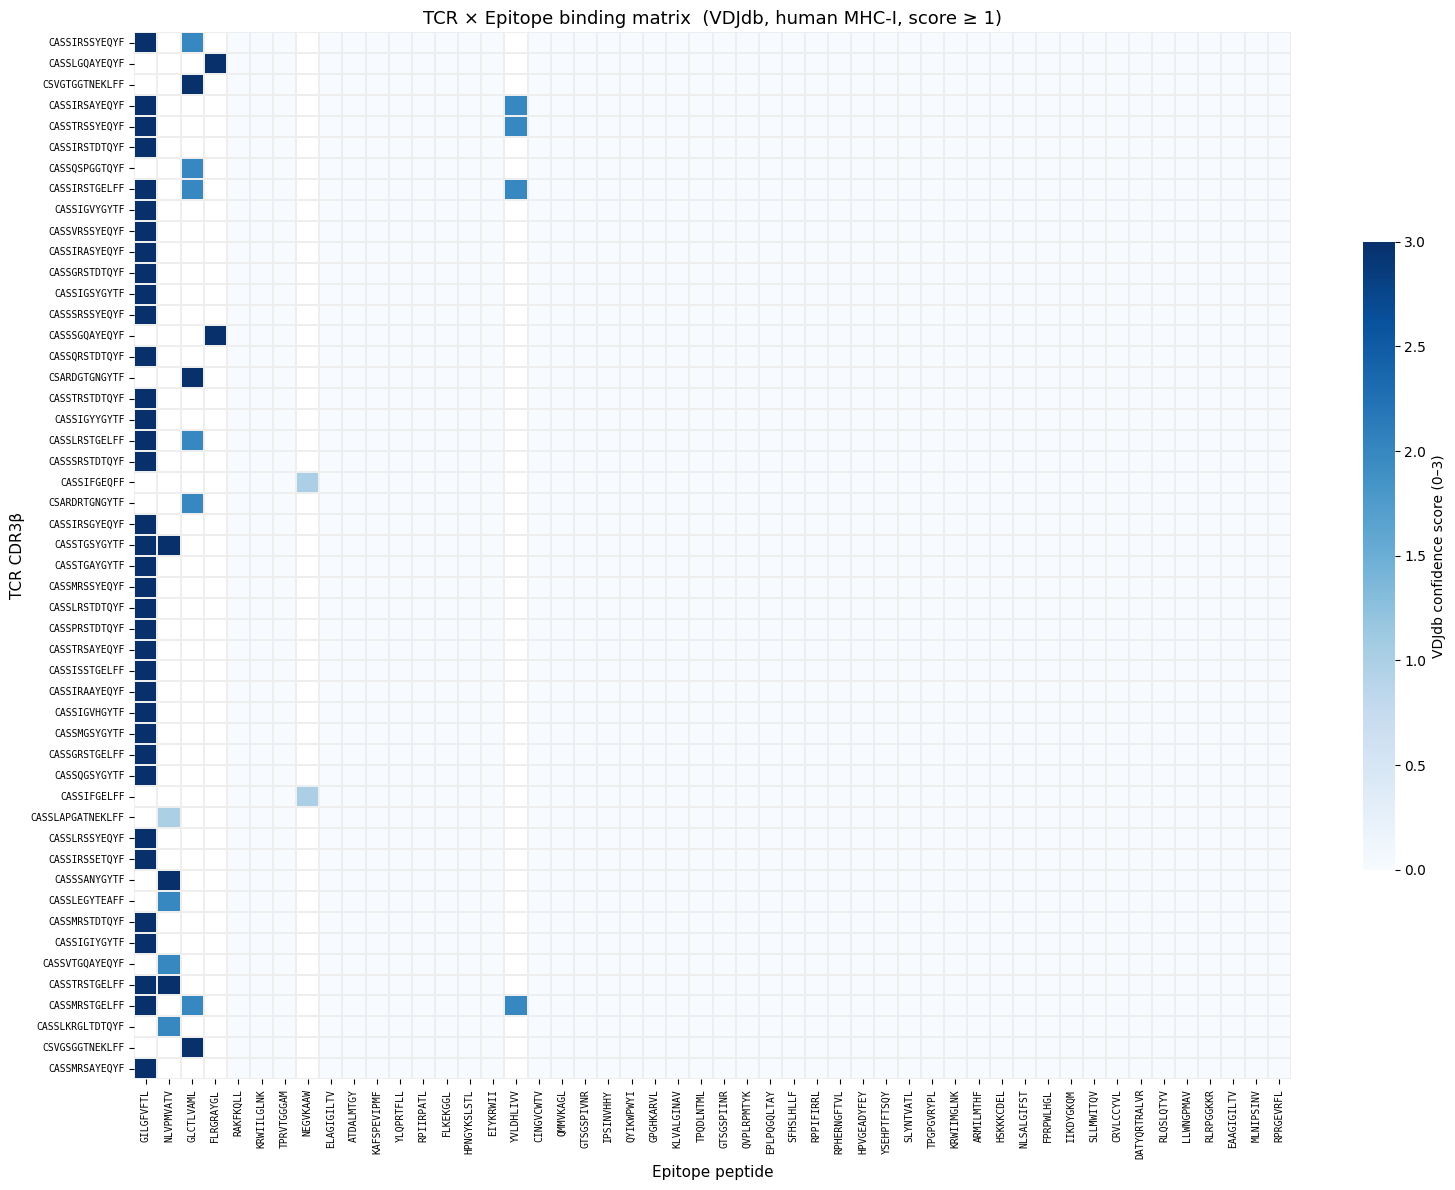

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

# Filter
df = df[
    (df['species'] == 'HomoSapiens') &
    (df['mhc.class'] == 'MHCI') &
    (df['vdjdb.score'] >= 1) &
    (df['gene'] == 'TRB')
]

# Co-occurrence selection: top 50 epitopes, then top 50 TCRs within those
top_epitopes = df['antigen.epitope'].value_counts().head(50).index
df_ep = df[df['antigen.epitope'].isin(top_epitopes)]
top_tcrs = df_ep['cdr3'].value_counts().head(50).index

df_sub = df_ep[df_ep['cdr3'].isin(top_tcrs)]

# Pivot
matrix = df_sub.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',       # <-- fixed
    aggfunc='max'
).reindex(index=top_tcrs, columns=top_epitopes, fill_value=0)

print(f"Matrix shape: {matrix.shape}")
print(f"Fill rate: {(matrix > 0).sum().sum() / matrix.size:.1%}")

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
sns.heatmap(
    matrix,
    cmap='Blues',
    vmin=0, vmax=3,
    linewidths=0.3,
    linecolor='#eeeeee',
    cbar_kws={'label': 'VDJdb confidence score (0–3)', 'shrink': 0.6},
    ax=ax
)
ax.set_xlabel("Epitope peptide", fontsize=11)
ax.set_ylabel("TCR CDR3β", fontsize=11)
ax.set_title("TCR × Epitope binding matrix  (VDJdb, human MHC-I, score ≥ 1)", fontsize=13)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7, fontfamily='monospace')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7, fontfamily='monospace')
plt.tight_layout()
plt.savefig("tcr_epitope_matrix.png", dpi=150)
plt.show()

Matrix shape: (50, 10)
Fill rate: 12.0%


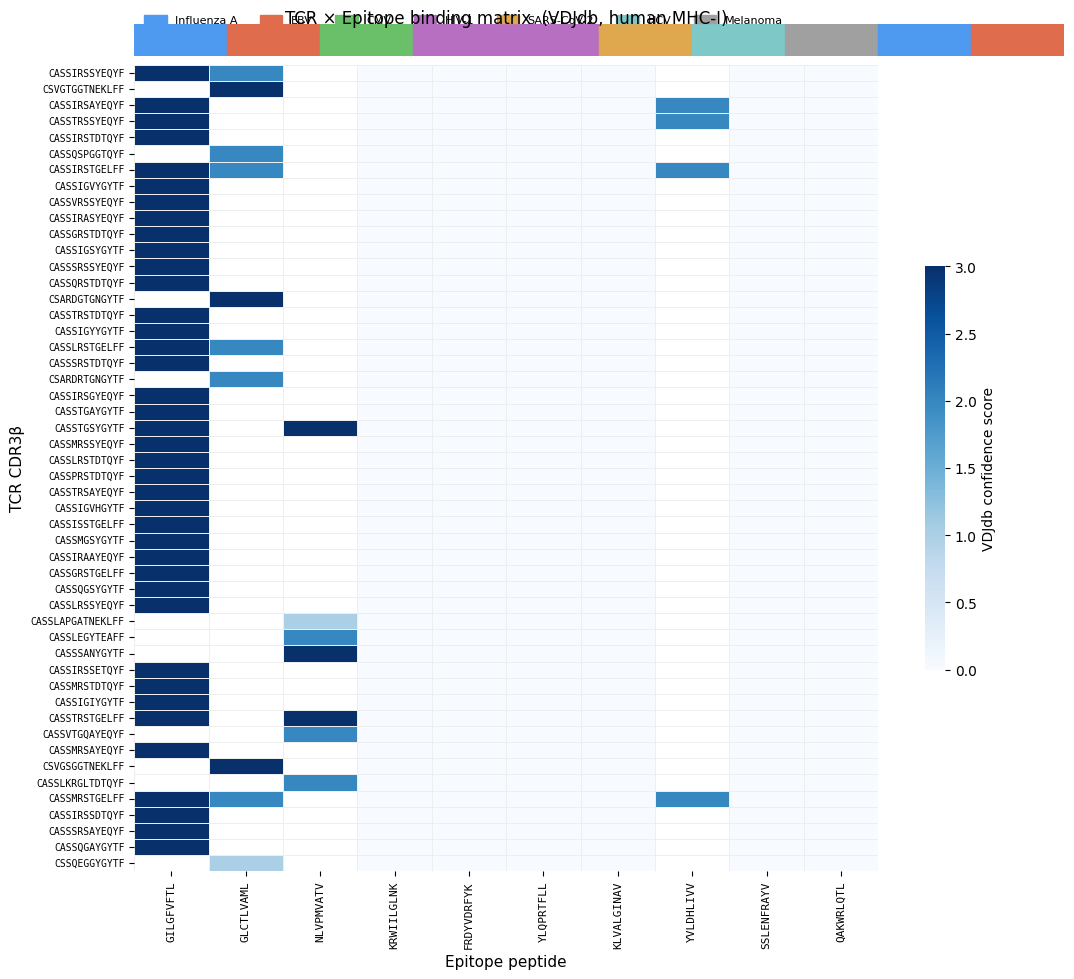

In [ ]:
# Exact epitopes from the original plot
selected_epitopes = [
    "GILGFVFTL",   # Influenza A / M1
    "GLCTLVAML",   # EBV / BMLF1
    "NLVPMVATV",   # CMV / pp65
    "KRWIILGLNK",  # HIV-1 / Gag
    "FRDYVDRFYK",  # HIV-1 / Gag
    "YLQPRTFLL",   # SARS-CoV-2 / Spike
    "KLVALGINAV",  # HCV / NS3
    "YVLDHLIVV",   # Melanoma / MART-1
    "SSLENFRAYV",  # Influenza A / NP
    "QAKWRLQTL",   # EBV / EBNA3A
]

# Filter df to only those epitopes (must already have loaded + filtered df above)
df_sub = df[df['antigen.epitope'].isin(selected_epitopes)]

# Get the TCRs that bind any of these epitopes, top 50 by frequency
top_tcrs = df_sub['cdr3'].value_counts().head(50).index
df_sub = df_sub[df_sub['cdr3'].isin(top_tcrs)]

# Pivot
matrix = df_sub.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=top_tcrs, columns=selected_epitopes, fill_value=0)

print(f"Matrix shape: {matrix.shape}")
print(f"Fill rate: {(matrix > 0).sum().sum() / matrix.size:.1%}")

import matplotlib.patches as mpatches

pathogen_map = {
    "GILGFVFTL":  "Influenza A",
    "SSLENFRAYV": "Influenza A",
    "GLCTLVAML":  "EBV",
    "QAKWRLQTL":  "EBV",
    "NLVPMVATV":  "CMV",
    "KRWIILGLNK": "HIV-1",
    "FRDYVDRFYK": "HIV-1",
    "YLQPRTFLL":  "SARS-CoV-2",
    "KLVALGINAV": "HCV",
    "YVLDHLIVV":  "Melanoma",
}

pathogen_colors = {
    "Influenza A": "#4e9af1",
    "EBV":         "#e06c4e",
    "CMV":         "#6abf69",
    "HIV-1":       "#b76fc1",
    "SARS-CoV-2":  "#e0a84e",
    "HCV":         "#7ec8c8",
    "Melanoma":    "#a0a0a0",
}

strip_colors = [pathogen_colors[pathogen_map[ep]] for ep in selected_epitopes]

fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 11),
    gridspec_kw={'height_ratios': [0.04, 1], 'hspace': 0.02}
)

# Top strip
for i, color in enumerate(strip_colors):
    axes[0].add_patch(mpatches.Rectangle((i, 0), 1, 1, color=color))
axes[0].set_xlim(0, len(selected_epitopes))
axes[0].set_ylim(0, 1)
axes[0].axis('off')

# Legend for strip
handles = [mpatches.Patch(color=v, label=k) for k, v in pathogen_colors.items()
           if k in pathogen_map.values()]
axes[0].legend(handles=handles, loc='upper left', ncol=len(handles),
               bbox_to_anchor=(0, 1.6), fontsize=8, frameon=False)

# Heatmap
sns.heatmap(
    matrix,
    cmap='Blues',
    vmin=0, vmax=3,
    linewidths=0.5,
    linecolor='#eeeeee',
    cbar_kws={'label': 'VDJdb confidence score', 'shrink': 0.5},
    ax=axes[1]
)
axes[1].set_xlabel("Epitope peptide", fontsize=11)
axes[1].set_ylabel("TCR CDR3β", fontsize=11)
axes[1].set_title("TCR × Epitope binding matrix  (VDJdb, human MHC-I)", fontsize=12, pad=30)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=90, fontsize=8, fontfamily='monospace')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0,  fontsize=7, fontfamily='monospace')

#plt.savefig("tcr_epitope_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

Epitopes found in data: 18
Missing: []
Final matrix: (30, 4)
Fill rate: 30.8%


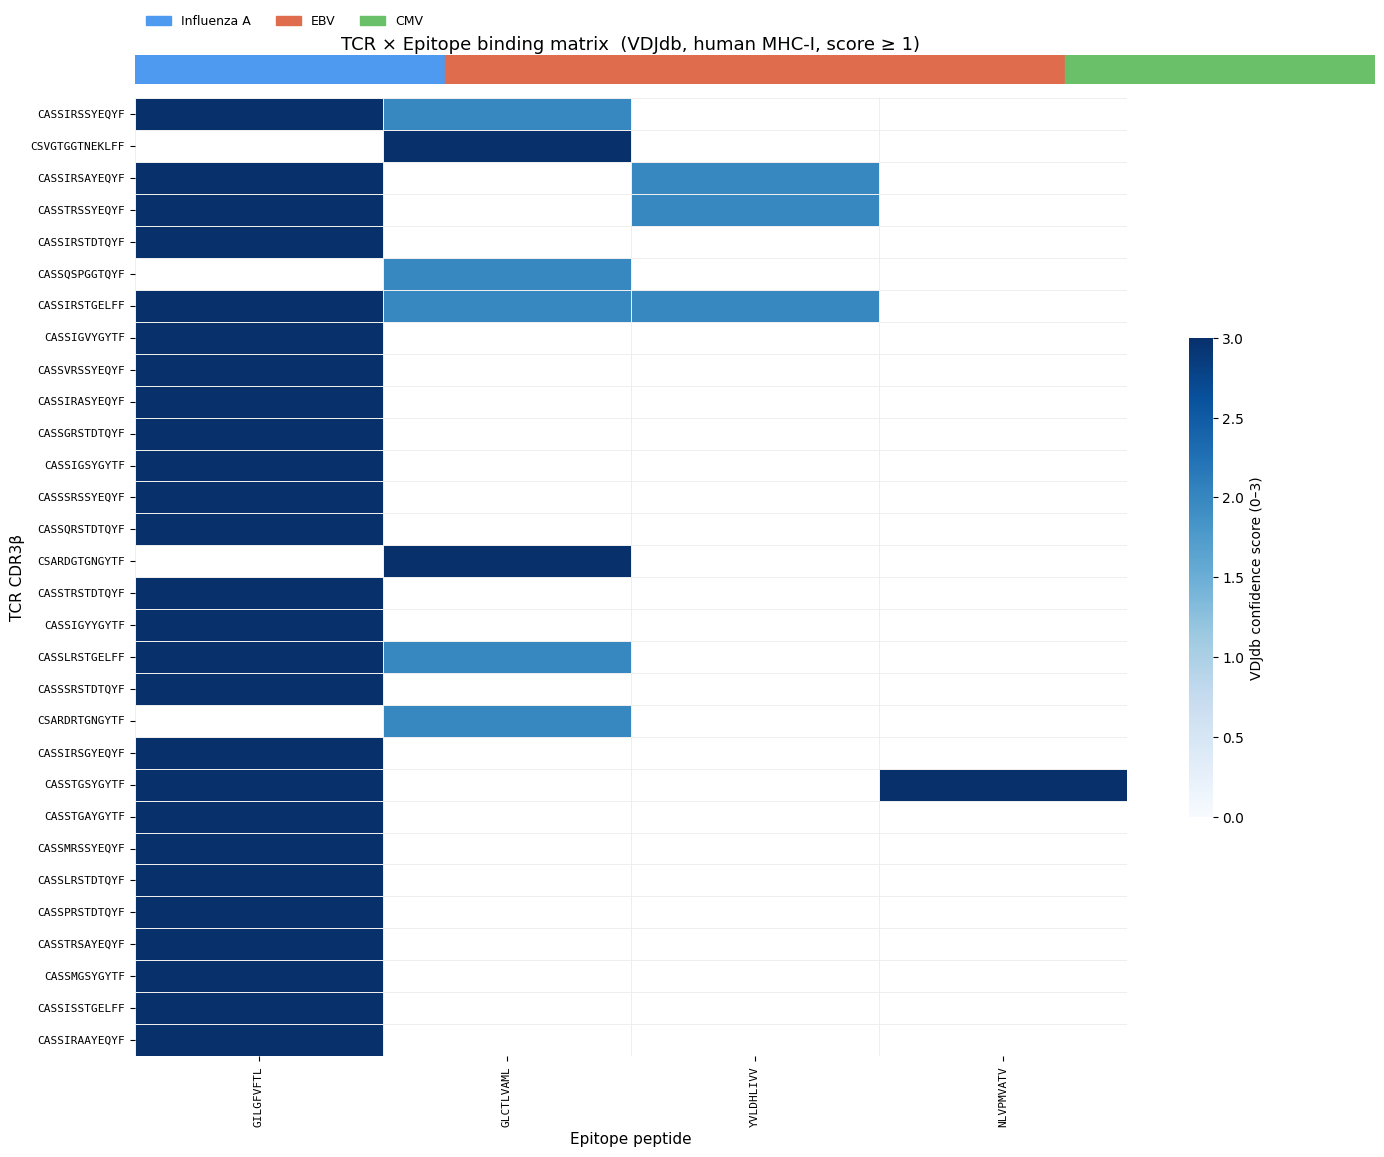

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

df = df[
    (df['species'] == 'HomoSapiens') &
    (df['mhc.class'] == 'MHCI') &
    (df['vdjdb.score'] >= 1) &
    (df['gene'] == 'TRB')
]

# ~30 well-known epitopes across diverse pathogens
selected_epitopes = [
    # Influenza A
    "GILGFVFTL", "SSLENFRAYV", "FMYSDFHFI", "NIIRNMSVI",
    # EBV
    "GLCTLVAML", "QAKWRLQTL", "RAKFKQLL", "YVLDHLIVV",
    # CMV
    "NLVPMVATV", "TPRVTGGGAM", "IPSINVHHY", "EFFWDANDIY",
    # HIV-1
    "KRWIILGLNK", "FRDYVDRFYK", "GPGHKARVL", "KAFSPEVIPMF",
    # SARS-CoV-2
    "YLQPRTFLL", "NYNYLYRLF", "LTDEMIAQY", "KLWAQCVQL",
    # HCV
    "KLVALGINAV", "CINGVCWTV", "DLMGYIPLV",
    # HTLV-1
    "LLFGYPVYV", "SFHSLHLLF",
    # HBV
    "FLLTRILTI", "GLSRYVARL",
    # HSV
    "RAKFKQLL", "SSIEFARL",
]

# Deduplicate in case of repeats, preserve order
seen = set()
selected_epitopes = [e for e in selected_epitopes
                     if not (e in seen or seen.add(e))]

# Keep only epitopes actually present in the data
available = set(df['antigen.epitope'].unique())
selected_epitopes = [e for e in selected_epitopes if e in available]
print(f"Epitopes found in data: {len(selected_epitopes)}")
print("Missing:", [e for e in selected_epitopes if e not in available])

# Get top 30 TCRs by frequency within these epitopes
df_sub = df[df['antigen.epitope'].isin(selected_epitopes)]
top_tcrs = df_sub['cdr3'].value_counts().head(30).index
df_sub = df_sub[df_sub['cdr3'].isin(top_tcrs)]

# Pivot
matrix = df_sub.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=top_tcrs, columns=selected_epitopes, fill_value=0)

# Drop any all-zero columns (epitopes with no matching top TCRs)
matrix = matrix.loc[:, (matrix > 0).any(axis=0)]
print(f"Final matrix: {matrix.shape}")
print(f"Fill rate: {(matrix > 0).sum().sum() / matrix.size:.1%}")

# ── Pathogen color map ────────────────────────────────────────────────────────
pathogen_map = {
    "GILGFVFTL":   "Influenza A",  "SSLENFRAYV":  "Influenza A",
    "FMYSDFHFI":   "Influenza A",  "NIIRNMSVI":   "Influenza A",
    "GLCTLVAML":   "EBV",          "QAKWRLQTL":   "EBV",
    "RAKFKQLL":    "EBV/HSV",      "YVLDHLIVV":   "EBV",
    "NLVPMVATV":   "CMV",          "TPRVTGGGAM":  "CMV",
    "IPSINVHHY":   "CMV",          "EFFWDANDIY":  "CMV",
    "KRWIILGLNK":  "HIV-1",        "FRDYVDRFYK":  "HIV-1",
    "GPGHKARVL":   "HIV-1",        "KAFSPEVIPMF": "HIV-1",
    "YLQPRTFLL":   "SARS-CoV-2",   "NYNYLYRLF":   "SARS-CoV-2",
    "LTDEMIAQY":   "SARS-CoV-2",   "KLWAQCVQL":   "SARS-CoV-2",
    "KLVALGINAV":  "HCV",          "CINGVCWTV":   "HCV",
    "DLMGYIPLV":   "HCV",          "LLFGYPVYV":   "HTLV-1",
    "SFHSLHLLF":   "HTLV-1",       "FLLTRILTI":   "HBV",
    "GLSRYVARL":   "HBV",          "SSIEFARL":    "HSV",
}

pathogen_colors = {
    "Influenza A": "#4e9af1",
    "EBV":         "#e06c4e",
    "EBV/HSV":     "#e06c4e",
    "CMV":         "#6abf69",
    "HIV-1":       "#b76fc1",
    "SARS-CoV-2":  "#e0a84e",
    "HCV":         "#7ec8c8",
    "HTLV-1":      "#e07bb0",
    "HBV":         "#a0c878",
    "HSV":         "#c8a87e",
}

strip_colors = [
    pathogen_colors.get(pathogen_map.get(ep, ""), "#cccccc")
    for ep in matrix.columns
]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 1,
    figsize=(16, 13),
    gridspec_kw={'height_ratios': [0.03, 1], 'hspace': 0.03}
)

# Pathogen color strip
for i, color in enumerate(strip_colors):
    axes[0].add_patch(mpatches.Rectangle((i, 0), 1, 1, color=color))
axes[0].set_xlim(0, len(matrix.columns))
axes[0].set_ylim(0, 1)
axes[0].axis('off')

# Strip legend (deduplicated)
seen_labels = set()
handles = []
for ep in matrix.columns:
    label = pathogen_map.get(ep, "Other")
    if label not in seen_labels:
        handles.append(mpatches.Patch(
            color=pathogen_colors.get(label, "#cccccc"), label=label
        ))
        seen_labels.add(label)
axes[0].legend(
    handles=handles, loc='upper left',
    bbox_to_anchor=(0, 2.8), ncol=len(handles),
    fontsize=9, frameon=False
)

# Heatmap
sns.heatmap(
    matrix,
    cmap='Blues',
    vmin=0, vmax=3,
    linewidths=0.4,
    linecolor='#eeeeee',
    cbar_kws={'label': 'VDJdb confidence score (0–3)', 'shrink': 0.5},
    ax=axes[1]
)
axes[1].set_xlabel("Epitope peptide", fontsize=11)
axes[1].set_ylabel("TCR CDR3β", fontsize=11)
axes[1].set_title(
    "TCR × Epitope binding matrix  (VDJdb, human MHC-I, score ≥ 1)",
    fontsize=13, pad=35
)
axes[1].set_xticklabels(
    axes[1].get_xticklabels(), rotation=90, fontsize=8, fontfamily='monospace'
)
axes[1].set_yticklabels(
    axes[1].get_yticklabels(), rotation=0, fontsize=8, fontfamily='monospace'
)

plt.savefig("tcr_epitope_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [15]:
import pandas as pd
import numpy as np

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

df = df[
    (df['species'] == 'HomoSapiens') &
    (df['mhc.class'] == 'MHCI') &
    (df['vdjdb.score'] >= 1) &
    (df['gene'] == 'TRB')
]

# Full matrix dimensions
n_tcr      = df['cdr3'].nunique()
n_epitopes = df['antigen.epitope'].nunique()
n_pairs    = df.groupby(['cdr3', 'antigen.epitope']).ngroups

total_cells = n_tcr * n_epitopes
fill_rate   = n_pairs / total_cells

print(f"Unique TCRs:        {n_tcr:,}")
print(f"Unique epitopes:    {n_epitopes:,}")
print(f"Total matrix cells: {total_cells:,}")
print(f"Observed pairs:     {n_pairs:,}")
print(f"Fill rate:          {fill_rate:.6%}")

Unique TCRs:        5,509
Unique epitopes:    349
Total matrix cells: 1,922,641
Observed pairs:     5,715
Fill rate:          0.297247%


Full matrix: (5509, 349),  fill rate: 0.297%

Fill rate vs submatrix size:
   N_TCR     N_EP    Fill rate   Filled cells
----------------------------------------------
      10        5       40.0%             20
      20        5       33.0%             33
      50        5       25.2%             63
     100        5       22.6%            113
     200        5       21.3%            213
     500        5       20.5%            513
      10       10       20.0%             20
      20       10       17.0%             34
      50       10       12.8%             64
     100       10       11.4%            114
     200       10       10.7%            214
     500       10       10.3%            514
      10       20       13.5%             27
      20       20       11.8%             46
      50       20        7.7%             77
     100       20        6.3%            127
     200       20        5.7%            227
     500       20        5.3%            527
      10       30     

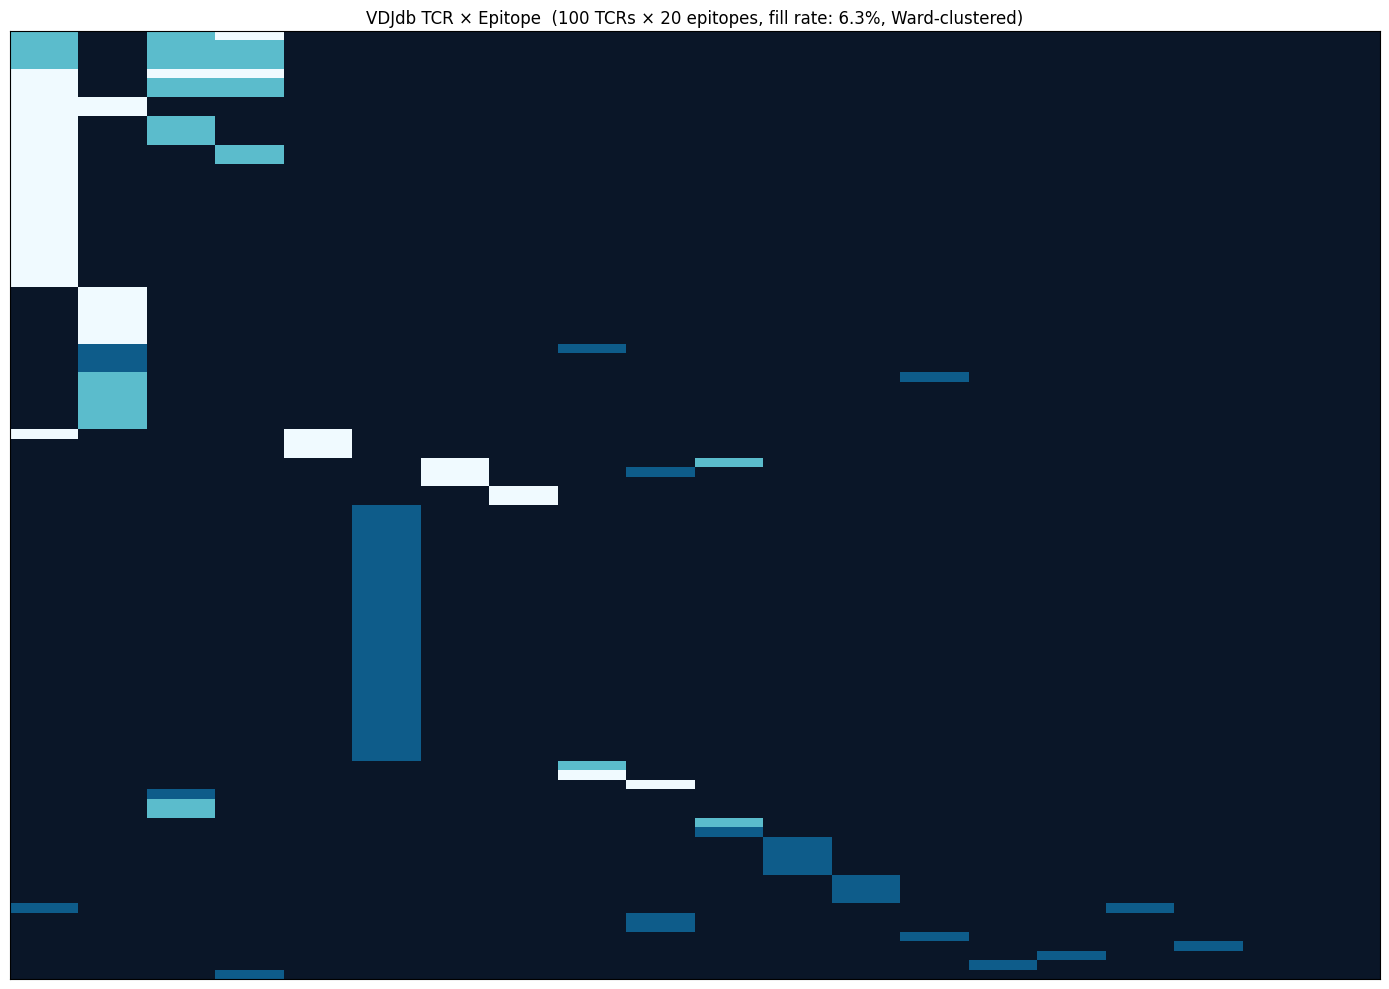

In [16]:
import pandas as pd
import numpy as np

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

df = df[
    (df['species'] == 'HomoSapiens') &
    (df['mhc.class'] == 'MHCI') &
    (df['vdjdb.score'] >= 1) &
    (df['gene'] == 'TRB')
]

# ── Build full binary pivot ───────────────────────────────────────────────────
pivot = df.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
)
# 1 = tested and binds, NaN = untested (or doesn't bind)
# For fill rate purposes NaN = 0
binary = pivot.notna().astype(int)

print(f"Full matrix: {binary.shape},  fill rate: {binary.values.mean():.3%}")

# ── Greedy submatrix selection ────────────────────────────────────────────────
# Strategy: 
#   1. Pick top K epitopes by number of TCRs tested
#   2. Within those epitopes, pick top N TCRs by number of those epitopes they appear in
#   3. Iterate K and N to maximize fill rate

def submatrix_fill(binary, n_tcr, n_ep):
    # Step 1: top epitopes by TCR count
    top_ep  = binary.sum(axis=0).nlargest(n_ep).index
    sub     = binary[top_ep]
    # Step 2: top TCRs by how many of those epitopes they appear in
    top_tcr = sub.sum(axis=1).nlargest(n_tcr).index
    sub     = sub.loc[top_tcr]
    fill    = sub.values.mean()
    return sub, fill

# Scan over matrix sizes to find the fill rate / size tradeoff
print("\nFill rate vs submatrix size:")
print(f"{'N_TCR':>8} {'N_EP':>8} {'Fill rate':>12} {'Filled cells':>14}")
print("-" * 46)

results = []
for n_ep in [5, 10, 20, 30, 50]:
    for n_tcr in [10, 20, 50, 100, 200, 500]:
        sub, fill = submatrix_fill(binary, n_tcr, n_ep)
        filled = int(fill * n_tcr * n_ep)
        results.append((n_tcr, n_ep, fill, filled))
        print(f"{n_tcr:>8} {n_ep:>8} {fill:>11.1%} {filled:>14,}")

# ── Pick the best tradeoff and plot ──────────────────────────────────────────
# Usually n_ep=10-20, n_tcr=50-200 gives the sweetspot
n_ep_choice  = 20
n_tcr_choice = 100

sub, fill = submatrix_fill(binary, n_tcr_choice, n_ep_choice)
print(f"\nChosen submatrix: {sub.shape},  fill rate: {fill:.1%}")

# Recover actual scores (not just binary) for the chosen submatrix
sub_scores = pivot.loc[sub.index, sub.columns].fillna(0)

# ── Cluster and plot ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

lake_colors = ["#0a1628","#0d2b4e","#0e4272","#0e5c8a","#1278a0",
               "#2a9ab5","#5bbccc","#9dd8e0","#cdeef5","#f0faff"]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)

def ward_order(m):
    ro = leaves_list(linkage(pdist(m,   metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

row_order, col_order = ward_order(sub_scores.values)
mat = sub_scores.iloc[row_order, col_order]

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(mat.values, aspect='auto', cmap=lake_cmap,
          vmin=0, vmax=3, interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.8)
ax.set_title(
    f"VDJdb TCR × Epitope  ({n_tcr_choice} TCRs × {n_ep_choice} epitopes, "
    f"fill rate: {fill:.1%}, Ward-clustered)",
    fontsize=12
)
plt.tight_layout()
#plt.savefig("vdjdb_dense_submatrix.png", dpi=150, bbox_inches='tight')
plt.show()

## Binding data

In [88]:
import pandas as pd

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Table_S8.csv"
df_s8 = pd.read_csv(path)
print(df_s8.columns)
df_s8.head(3)

Index(['epitope', 'cancer', 'cancer.type.lev1', 'category', 'gene',
       'cancer.type.lev2', 'CDR3b', 'binder', 'binder_pred', 'predict_proba'],
      dtype='object')


,epitope,cancer,cancer.type.lev1,category,gene,cancer.type.lev2,CDR3b,binder,binder_pred,predict_proba
0,ACDPHSGHFV,melanoma,melanoma,neoepitope,CDK4,melanoma,ASSVVAGFNEQF,1,1,0.856667
1,AEHSLQVAY,melanoma,melanoma,neoepitope,SEC22C,melanoma,SVEDRRGPFYGYTF,1,1,0.960000
2,ALDPHSGHFV,tcga,tcga,neoepitope,CDK4,other,ASSVVAGFNEQF,1,1,0.843333


In [89]:
b = pd.to_numeric(df_s8["binder"], errors="coerce").fillna(0).astype(int)
print("rows with binder==1:", int(b.eq(1).sum()))
print(
    "unique (epitope, CDR3b) with any binder==1:",
    int(df_s8.loc[b.eq(1)].drop_duplicates(["epitope", "CDR3b"]).shape[0]),
)


rows with binder==1: 1696
unique (epitope, CDR3b) with any binder==1: 870


In [78]:
import numpy as np
import pandas as pd

n_cdr = df_s8["CDR3b"].nunique()
n_ep = df_s8["epitope"].nunique()
n_cells = n_cdr * n_ep

n_pairs_measured = df_s8.groupby(["CDR3b", "epitope"], dropna=False).ngroups
# same as: df_s8[["CDR3b", "epitope"]].drop_duplicates().shape[0]

n_missing_grid = n_cells - n_pairs_measured  # zeros from fill_value (no rows for that pair)

n_bind_1 = int((binder_matrix.values != 0).sum())  # should be 870 for your case

# Zeros that are "in grid but measured" = measured pairs minus positives
n_measured_zero = n_pairs_measured - n_bind_1

print(f"matrix shape: {binder_matrix.shape} (= {n_cdr} × {n_ep})")
print(f"total cells: {n_cells:,}")
print(f"unique (CDR3b, epitope) pairs with ≥1 row in data: {n_pairs_measured:,}")
print(f"cells implicitly zero (no row for that pair): {n_missing_grid:,}")
print(f"cells with binder 1: {n_bind_1:,}")
print(f"cells measured but binder 0: {n_measured_zero:,}")
print(f"fraction of grid never in data: {n_missing_grid / n_cells:.2%}")

matrix shape: (57921, 107) (= 46928 × 445)
total cells: 20,882,960
unique (CDR3b, epitope) pairs with ≥1 row in data: 73,496
cells implicitly zero (no row for that pair): 20,809,464
cells with binder 1: 6,140,428
cells measured but binder 0: -6,066,932
fraction of grid never in data: 99.65%


Fill rate (fraction of nonzero entries in binding matrix): 99.68%


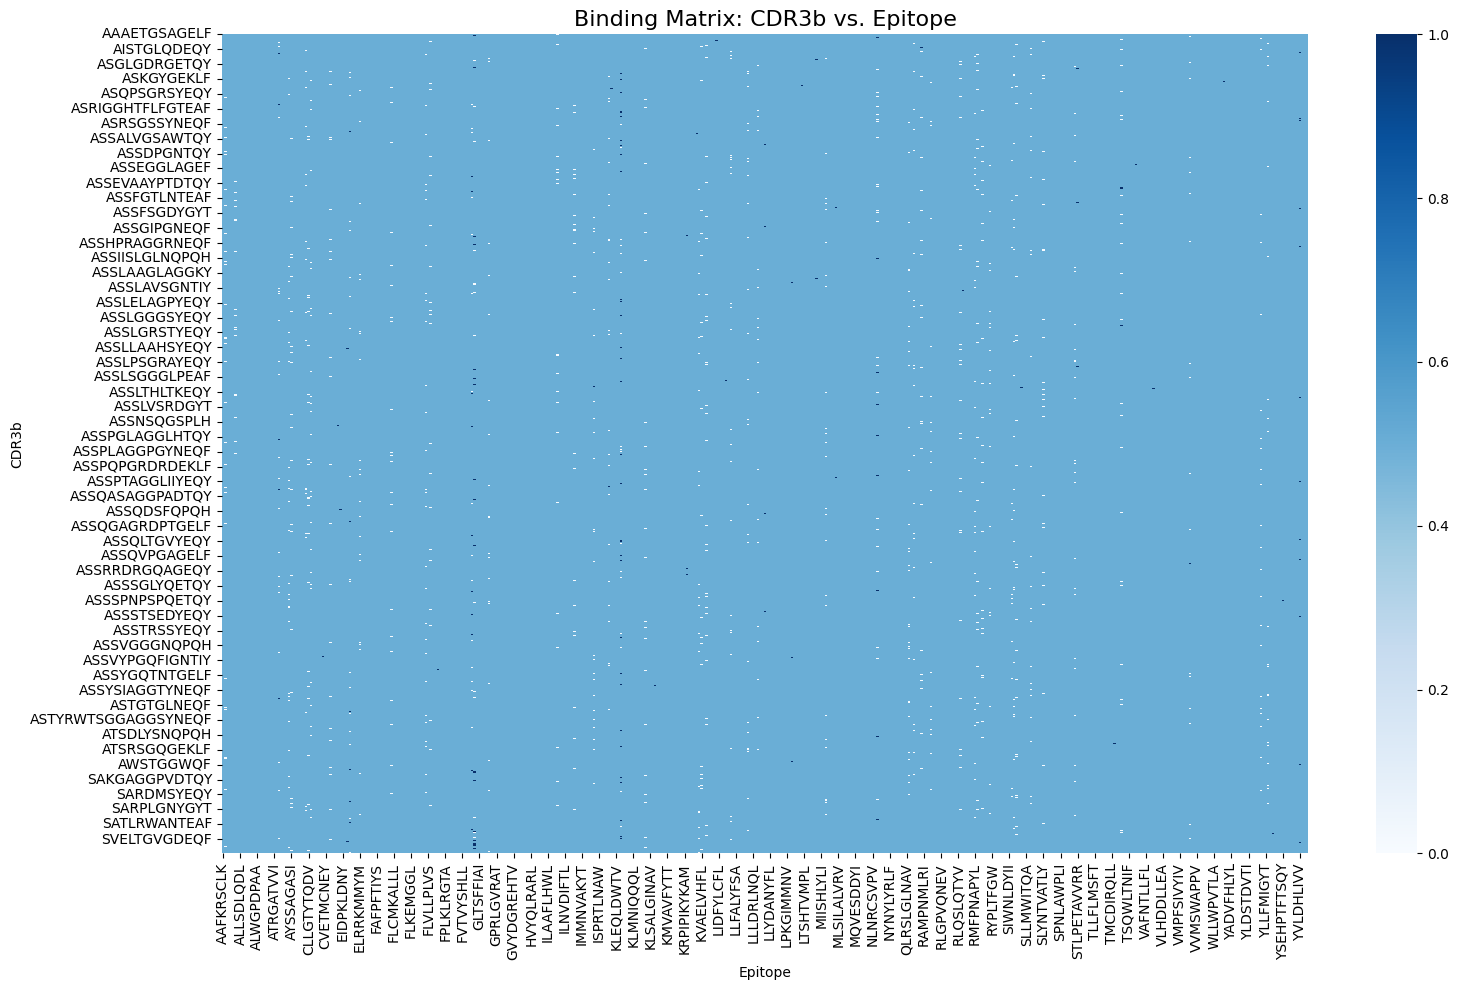

In [79]:

# One row per (epitope, CDR3b): if duplicates exist, take max binder (0/1)
binder_matrix = (
    df_s8.pivot_table(
        index="CDR3b",
        columns="epitope",
        values="binder",
        aggfunc="max",  # use "any" if you prefer bool logic on 0/1
        fill_value=0.5,
    )
    .astype(float)
)
# Print fill rate: fraction of nonzero entries
fill_rate = (binder_matrix.values != 0).sum() / binder_matrix.size
print(f"Fill rate (fraction of nonzero entries in binding matrix): {fill_rate:.2%}")

# Visualize the binary matrix as a heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(binder_matrix, cmap="Blues", cbar=True, linewidths=0.0)
plt.title("Binding Matrix: CDR3b vs. Epitope", fontsize=16)
plt.xlabel("Epitope")
plt.ylabel("CDR3b")
plt.tight_layout()
plt.show()

measured fraction in block: 5.46%
measured cells: 546 / 10,000


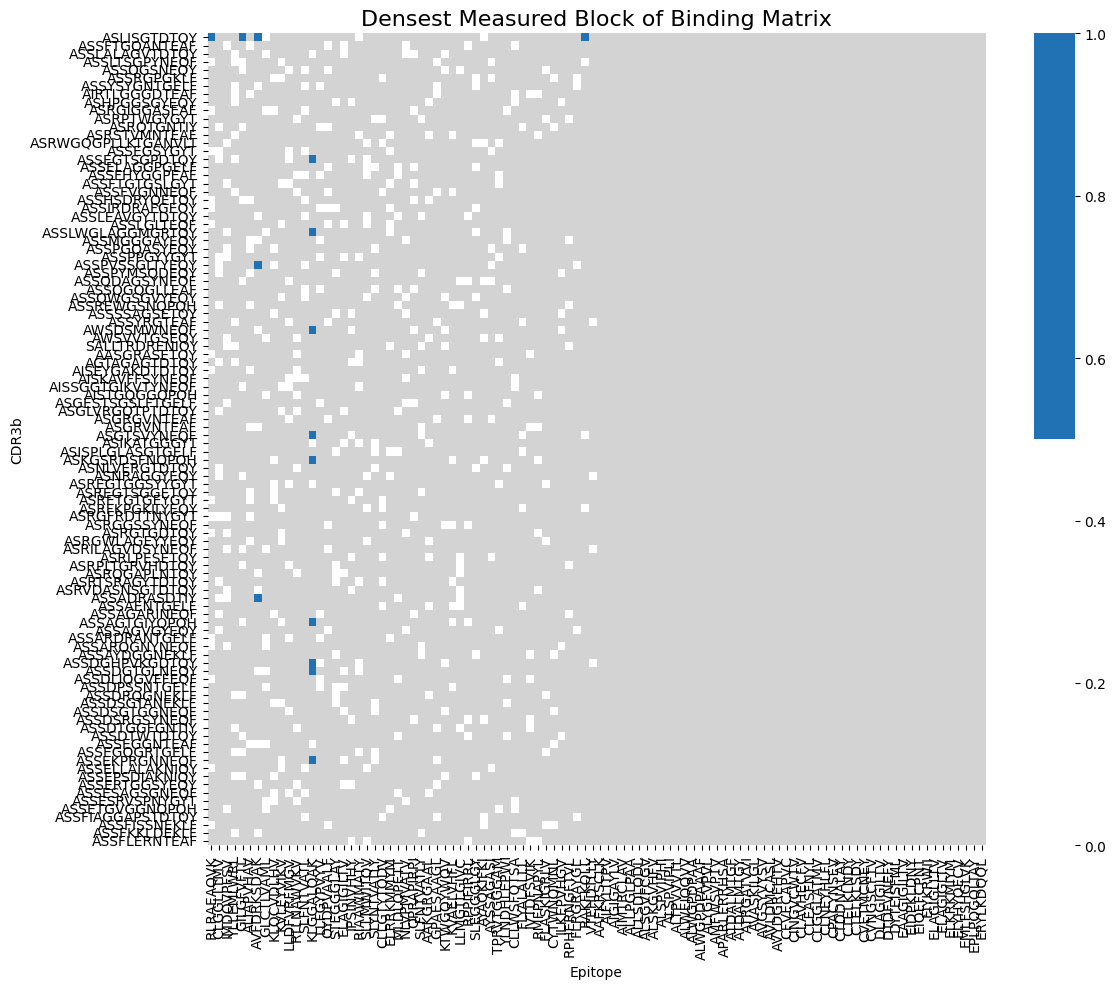

In [81]:
measured = (
    pd.crosstab(df_s8["CDR3b"], df_s8["epitope"])
    .gt(0)
    .reindex(index=binder_matrix.index, columns=binder_matrix.columns)
    .fillna(False)
)

def densest_measured_block(measured, n_rows, n_cols, max_iter=50, seed_mult=3):
    """Return (row_index, col_index) with high fraction of measured cells."""
    # start from globally busiest rows
    rows = measured.sum(axis=1).nlargest(min(n_rows * seed_mult, len(measured))).index
    cols = measured.loc[rows].sum(axis=0).nlargest(n_cols).index

    for _ in range(max_iter):
        rows = measured.loc[:, cols].sum(axis=1).nlargest(n_rows).index
        cols = measured.loc[rows, :].sum(axis=0).nlargest(n_cols).index

    return rows, cols

n_rows, n_cols = 100, 100  # tune to what your screen can show

rows, cols = densest_measured_block(measured, n_rows, n_cols)

bm_dense = binder_matrix.loc[rows, cols]
mask_dense = measured.loc[rows, cols]

density = mask_dense.to_numpy().mean()
print(f"measured fraction in block: {density:.2%}")
print(f"measured cells: {int(mask_dense.to_numpy().sum()):,} / {mask_dense.size:,}")

import numpy as np

Y = binder_matrix.loc[rows, cols].to_numpy(dtype=float)
M = mask_dense.to_numpy()

# Map to values: unmeasured (gray)=np.nan, 0=white, 1=blue
# We'll visualize as: np.nan (not measured), 0 (white), 1 (blue) -- but need custom colormap
Y_plot = np.where(M, Y, np.nan)  # NaN = unmeasured for plotting

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

# Custom 3-color colormap: gray for np.nan, white for 0, blue for 1
custom_cmap = ListedColormap(["white", "#2171b5"])  # white for 0, blue for 1

plt.figure(figsize=(12, 10))
# Need to handle background (unmeasured) as gray; mask=~measured shows the gray cells
ax = sns.heatmap(
    Y_plot,
    cmap=custom_cmap,
    cbar=True,
    linewidths=0,
    xticklabels=cols,
    yticklabels=rows,
    vmin=0,
    vmax=1,
    mask=np.isnan(Y_plot),
)
# Fill background for non-measured with gray
ax.set_facecolor('lightgray')  # background for non-measured cells
plt.title("Densest Measured Block of Binding Matrix", fontsize=16)
plt.xlabel("Epitope")
plt.ylabel("CDR3b")
plt.tight_layout()
plt.show()

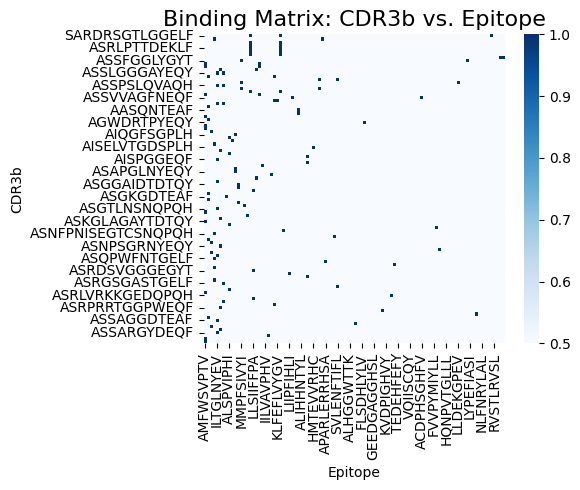

In [68]:
bm = binder_matrix.loc[binder_matrix.sum(axis=1) > 0, binder_matrix.sum(axis=0) > 0]
# plt.figure(figsize=(max(12, bm.shape[1] * 0.12), max(10, bm.shape[0] * 0.08)))
# sns.heatmap(bm, cmap="Blues", cbar=True, linewidths=0)

top_ep = binder_matrix.sum(axis=0).nlargest(100).index
top_tcr = binder_matrix[top_ep].sum(axis=1).nlargest(100).index
bm = binder_matrix.loc[top_tcr, top_ep]
# sns.heatmap(bm2, cmap="Blues", cbar=True)


plt.figure(figsize=(6, 5))
sns.heatmap(bm, cmap="Blues", cbar=True, linewidths=0.0)
plt.title("Binding Matrix: CDR3b vs. Epitope", fontsize=16)
plt.xlabel("Epitope")
plt.ylabel("CDR3b")
plt.tight_layout()
plt.show()

In [63]:
# unique pairs present anywhere in the original data
observed_pairs = df_s8[["CDR3b", "epitope"]].drop_duplicates()

# every cell in bm is one (CDR3b, epitope) combination
grid = pd.MultiIndex.from_product([bm.index, bm.columns], names=["CDR3b", "epitope"]).to_frame(index=False)

with_data = grid.merge(observed_pairs, on=["CDR3b", "epitope"], how="inner")

n_cells = bm.shape[0] * bm.shape[1]
n_with_data = len(with_data)

print(f"cells in bm: {n_cells:,}")
print(f"cells with ≥1 row in df_s8: {n_with_data:,} ({n_with_data / n_cells:.2%})")
print(f"cells with no row (structural zero / untested): {n_cells - n_with_data:,}")

cells in bm: 100
cells with ≥1 row in df_s8: 14 (14.00%)
cells with no row (structural zero / untested): 86


## Atlas

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# ── Load directly from URL ────────────────────────────────────────────────────
url = "https://atlas.ibbr.umd.edu/web/tables/ATLAS.tsv"
df = pd.read_csv(url, sep="\t", na_values=["\\N", "nan", ""])

print(df.shape)
print(df.columns.tolist())
df.head(3)

(226494, 23)
['complex.id', 'gene', 'cdr3', 'v.segm', 'j.segm', 'species', 'mhc.a', 'mhc.b', 'mhc.class', 'antigen.epitope', 'antigen.gene', 'antigen.species', 'reference.id', 'vdjdb.score', 'TCR_hash', 'method', 'meta', 'cdr3fix', 'web.method', 'web.method.seq', 'web.cdr3fix.nc', 'web.cdr3fix.unmp', 'vdjdb.pgen.score']


,complex.id,gene,cdr3,v.segm,j.segm,species,mhc.a,mhc.b,mhc.class,antigen.epitope,...,vdjdb.score,TCR_hash,method,meta,cdr3fix,web.method,web.method.seq,web.cdr3fix.nc,web.cdr3fix.unmp,vdjdb.pgen.score
0,0,TRB,CASSIVGGNEQFF,TRBV19*01,TRBJ2-1*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,...,3,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSIVGGNEQFF"", ""cdr3_old"": ""CASSIVG...",sort,amplicon,no,no,2
1,0,TRB,CASSMRSTGELFF,TRBV19*01,TRBJ2-2*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,...,3,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSMRSTGELFF"", ""cdr3_old"": ""CASSMRS...",sort,amplicon,no,no,2
2,0,TRB,CASSIRSAWAQYF,TRBV19*01,TRBJ2-3*01,HomoSapiens,HLA-A*02:01,B2M,MHCI,GILGFVFTL,...,2,NaN,"{""identification"": ""tetramer-sort "", ""frequenc...","{""study.id"": """", ""cell.subset"": ""CD8+"", ""subje...","{""cdr3"": ""CASSIRSAWAQYF"", ""cdr3_old"": ""CASSIRS...",sort,amplicon,no,no,2


In [9]:
# ── Inspect the Kd column raw values ─────────────────────────────────────────
# Some entries are ">200" strings — need to parse carefully
print(df['Kd_microM'].dtype)
print(df['Kd_microM'].value_counts().head(20))

object
Kd_microM
n.d.      57
>200      43
30.6       4
12         4
>300       4
8.6        3
24.6       3
32         3
5.2        3
15         3
0.0001     3
5.5        3
27         3
>100       3
0.001      2
6          2
1.1        2
46         2
>500       2
273.2      2
Name: count, dtype: int64


In [10]:
# ── Parse Kd: handle ">X" entries and "X +/- Y" format ──────────────────────
def parse_kd(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('>'):
        # ">200" means undetectable binding — treat as NaN or a ceiling
        return np.nan          # swap for float('inf') if you'd rather show it
    # Strip "+/- X" uncertainty
    val = val.split('+')[0].strip()
    try:
        return float(val)
    except ValueError:
        return np.nan

df['Kd_parsed'] = df['Kd_microM'].apply(parse_kd)

print(f"Total rows: {len(df)}")
print(f"Rows with valid Kd: {df['Kd_parsed'].notna().sum()}")
print(f"Kd range: {df['Kd_parsed'].min():.3f} – {df['Kd_parsed'].max():.1f} µM")

Total rows: 697
Rows with valid Kd: 584
Kd range: 0.000 – 1936.7 µM


In [11]:
# ── Filter to wild-type TCR and wild-type peptide entries only ────────────────
wt = df[
    (df['TCR_mut'] == 'WT') &
    (df['PEP_mut'] == 'WT') &
    (df['Kd_parsed'].notna())
].copy()

print(f"WT entries with valid Kd: {len(wt)}")
print(f"Unique TCRs:     {wt['TCRname'].nunique()}")
print(f"Unique peptides: {wt['PEPseq'].nunique()}")
print(f"Unique MHCs:     {wt['MHCname'].nunique()}")

# Preview the range
wt[['TCRname', 'PEPseq', 'MHCname', 'Kd_parsed', 'DeltaG_kcal_per_mol']].head(10)

WT entries with valid Kd: 175
Unique TCRs:     51
Unique peptides: 46
Unique MHCs:     24


,TCRname,PEPseq,MHCname,Kd_parsed,DeltaG_kcal_per_mol
0,LC13,FLRGRAYGL,HLA-B*08:01,12.500000,-6.69
40,JM22,GILGFVFTL,HLA-A*02:01,5.200000,-7.21
63,A6,LLFGYPVYV,HLA-A*02:01,2.113503,-7.74
90,RA14,NLVPMVATV,HLA-A*02:01,27.700000,-6.21
101,TK3,HPVGEADYFEY,HLA-B*35:01,2.200000,-7.72
113,MS2-3C8,FSWGAEGQRPGFG,HLA-DRA*01:01 | HLA-DRB1*04:01,5.000000,-7.23
120,A6,LLFGYPVYV,HLA-A*02:01,0.910000,-8.24
124,KK50.4,VMAPRTLIL,HLA-E*01:03,30.200000,-6.17
125,KK50.4,VMAPRTLIL,HLA-E*01:01,32.700000,-6.12
126,KK50.4,VMAPRTLIL,HLA-E*01:03,28.400000,-6.2


In [13]:
# ── Build TCR × peptide matrix ────────────────────────────────────────────────
# Where multiple entries exist for same (TCR, peptide), take the minimum Kd
# (strongest binding = most reliable WT measurement)
matrix_kd = wt.pivot_table(
    index='TCRname',
    columns='PEPseq',
    values='Kd_parsed',
    aggfunc='min'
)

print(matrix_kd)
# Drop rows/cols that are entirely NaN
matrix_kd = matrix_kd.dropna(how='all', axis=0).dropna(how='all', axis=1)

print(f"Matrix shape: {matrix_kd.shape}")
print(f"Fill rate: {matrix_kd.notna().sum().sum() / matrix_kd.size:.1%}")

PEPseq      AAGIGILTV  ADLIAYLKQATKG  ALWGFFPVL  ALWGPDPAAA  ANERADLIAYLKQATK  \
TCRname                                                                         
14.C6             NaN            NaN        NaN         NaN               NaN   
1E6               NaN            NaN        NaN       270.0               NaN   
1G4               NaN            NaN        NaN         NaN               NaN   
226               NaN          0.321        NaN         NaN               NaN   
2B4               NaN         13.700        NaN         NaN               5.5   
2C                NaN            NaN        NaN         NaN               NaN   
2Cm13             NaN            NaN        NaN         NaN               NaN   
2Cm67             NaN            NaN        NaN         NaN               NaN   
3B                NaN            NaN        NaN         NaN               NaN   
42F3              NaN            NaN        NaN         NaN               NaN   
A6                NaN       

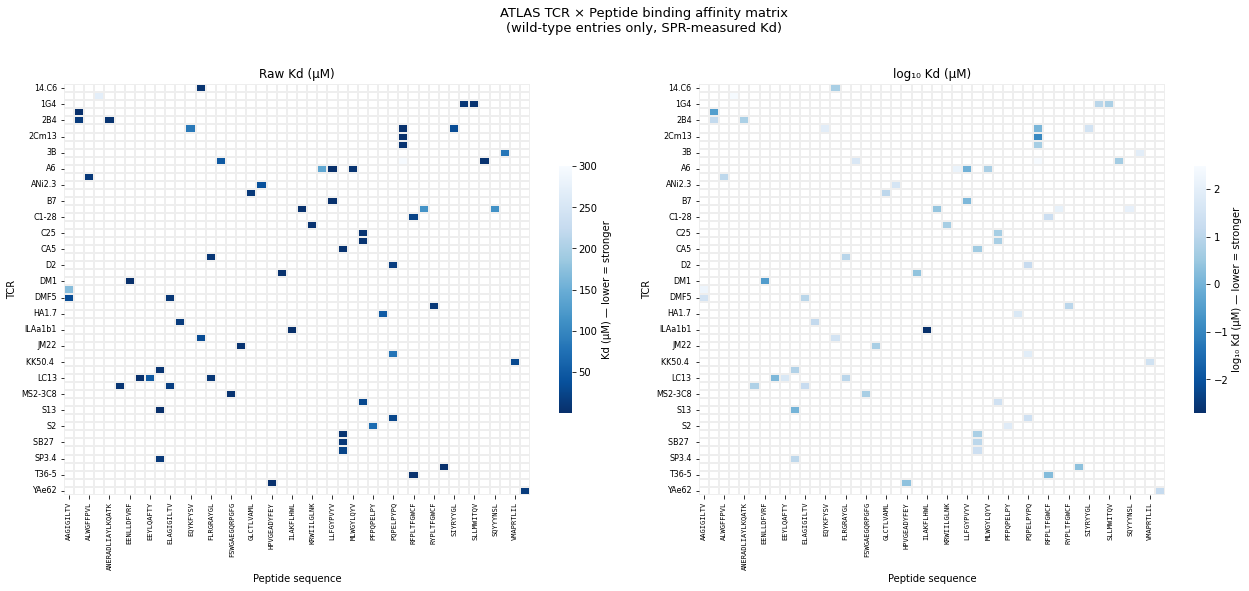

In [88]:
# ── Plot: two versions side by side ──────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# ── Left: raw Kd (µM) ────────────────────────────────────────────────────────
sns.heatmap(
    matrix_kd,
    cmap='Blues_r',          # reversed: dark = strong binding (low Kd)
    linewidths=0.4,
    linecolor='#eeeeee',
    cbar_kws={'label': 'Kd (µM) — lower = stronger', 'shrink': 0.6},
    ax=axes[0]
)
axes[0].set_title("Raw Kd (µM)", fontsize=12)
axes[0].set_xlabel("Peptide sequence", fontsize=10)
axes[0].set_ylabel("TCR", fontsize=10)
axes[0].set_xticklabels(axes[0].get_xticklabels(),
                         rotation=90, fontsize=7, fontfamily='monospace')
axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0, fontsize=8)

# ── Right: log10(Kd) — compresses the dynamic range ────────────────────────
matrix_logkd = np.log10(matrix_kd)

sns.heatmap(
    matrix_logkd,
    cmap='Blues_r',
    linewidths=0.4,
    linecolor='#eeeeee',
    cbar_kws={'label': 'log₁₀ Kd (µM) — lower = stronger', 'shrink': 0.6},
    ax=axes[1]
)
axes[1].set_title("log₁₀ Kd (µM)", fontsize=12)
axes[1].set_xlabel("Peptide sequence", fontsize=10)
axes[1].set_ylabel("TCR", fontsize=10)
axes[1].set_xticklabels(axes[1].get_xticklabels(),
                         rotation=90, fontsize=7, fontfamily='monospace')
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0, fontsize=8)

fig.suptitle(
    "ATLAS TCR × Peptide binding affinity matrix\n(wild-type entries only, SPR-measured Kd)",
    fontsize=13, y=1.02
)
plt.tight_layout()
#plt.savefig("atlas_affinity_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Fill NaN → ceiling value (95th percentile of observed Kd)
# meaning: "we didn't measure it, assume it doesn't bind"
ceiling = np.nanpercentile(matrix_kd.values, 100)
matrix_filled = matrix_kd.fillna(ceiling)

# Log transform
matrix_log = np.log10(matrix_filled)
matrix_log = matrix_filled

# Clustermap
g = sns.clustermap(
    matrix_log,
    method='ward',
    metric='euclidean',
    cmap='Blues_r',
    figsize=(14, 10),
    linewidths=0.3,
    linecolor='#eeeeee',
    dendrogram_ratio=0.15,
    cbar_pos=(0.02, 0.8, 0.03, 0.15),
    cbar_kws={'label': 'log₁₀ Kd (µM) — lower = stronger'},
    xticklabels=True,
    yticklabels=True
)

g.ax_heatmap.set_xlabel("Peptide sequence", fontsize=11)
g.ax_heatmap.set_ylabel("TCR", fontsize=11)
g.ax_heatmap.set_title(
    f"ATLAS TCR × Peptide — hierarchical clustering\n(NaN filled with {ceiling:.0f} µM ceiling)",
    fontsize=12, pad=10
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=90, fontsize=7, fontfamily='monospace'
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8
)

#plt.savefig("atlas_clustered.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Ceiling value used: {ceiling:.1f} µM")
print(f"Matrix shape: {matrix_log.shape}")
print(f"Fill rate (originally observed): {matrix_kd.notna().sum().sum() / matrix_kd.size:.1%}")

NameError: name 'matrix_kd' is not defined

In [14]:

with pd.ExcelWriter("atlas_binding_matrix.xlsx", engine='openpyxl') as writer:
    
    # Sheet 1: original Kd values with NaNs intact
    matrix_kd.to_excel(writer, sheet_name='Kd_raw_uM')
    
    # Sheet 2: NaN-filled with ceiling
    matrix_filled.to_excel(writer, sheet_name='Kd_filled_uM')
    
    # Sheet 3: log10 of filled matrix
    matrix_log.to_excel(writer, sheet_name='log10_Kd_filled')

print("Saved to atlas_binding_matrix.xlsx")

Saved to atlas_binding_matrix.xlsx


## Estimate off-diagonal

In [17]:
import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralBiclustering

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

# basic filtering
df = df[df["gene"] == "TRB"]
df = df[df["species"] == "HomoSapiens"]

df = df.dropna(subset=["cdr3", "antigen.epitope", "mhc.a"])

In [18]:
df["pmhc"] = df["antigen.epitope"] + "_" + df["mhc.a"]

# pick most common viral pMHCs
top_pmhc = df["pmhc"].value_counts().head(100).index
df = df[df["pmhc"].isin(top_pmhc)]

In [19]:
tcrs = df["cdr3"].drop_duplicates().sample(100, random_state=0).values
pmhcs = top_pmhc[:100]

In [23]:
# -----------------------------
# STEP 1: BUILD RAW PAIR LIST
# -----------------------------
pairs = []

for tcr in tcrs:
    for pmhc in pmhcs:
        peptide, hla = pmhc.split("_")

        pairs.append({
            "peptide": peptide,

            # NetTCR fields (alpha missing → empty strings)
            "A1": "",
            "A2": "",
            "A3": "",
            "B1": "",
            "B2": "",
            "B3": tcr,

            "pmhc": pmhc,
            "tcr": tcr
        })

df_infer = pd.DataFrame(pairs)

# -----------------------------
# STEP 2: HARD CLEANING (CRITICAL FOR NETTCR)
# -----------------------------

# 2.1 remove NaNs / floats / broken values
df_infer = df_infer.replace([np.nan, "nan", None], "")

# 2.2 enforce string type everywhere
seq_cols = ["peptide", "A1", "A2", "A3", "B1", "B2", "B3"]

for c in seq_cols:
    df_infer[c] = df_infer[c].astype(str)

# 2.3 remove empty sequences (NetTCR cannot handle them)
df_infer = df_infer[
    (df_infer["peptide"].str.len() > 0) &
    (df_infer["B3"].str.len() > 0)
]

# 2.4 enforce amino-acid validity (removes garbage rows)
aa_pattern = "^[ACDEFGHIKLMNPQRSTVWY]+$"

df_infer = df_infer[
    df_infer["peptide"].str.match(aa_pattern) &
    df_infer["B3"].str.match(aa_pattern)
]

# -----------------------------
# STEP 3: PEPTIDE LENGTH FILTER (NETTCR COMPATIBILITY)
# -----------------------------
# NetTCR-2.2 is most stable for MHC-I typical peptides

df_infer = df_infer[
    df_infer["peptide"].str.len().between(8, 11)
]

# optional stricter (often best for HLA-A*02:01 biology):
# df_infer = df_infer[df_infer["peptide"].str.len().isin([9, 10])]

# -----------------------------
# STEP 4: EXPORT FOR NETTCR
# -----------------------------
df_infer.to_csv("nettcr_input.csv", index=False)

print("Final inference set size:", df_infer.shape)
print("Saved to nettcr_input.csv")

Final inference set size: (8700, 9)
Saved to nettcr_input.csv


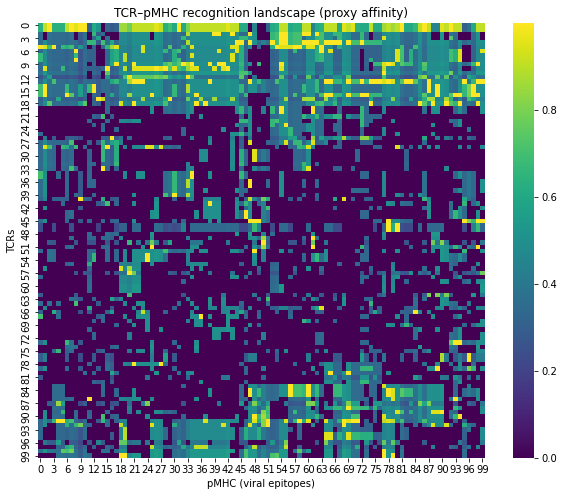

In [16]:
AA = "ACDEFGHIKLMNPQRSTVWY"
aa_to_idx = {a:i for i,a in enumerate(AA)}

def featurize(seq, max_len=20):
    # one-hot averaged embedding
    mat = np.zeros((max_len, len(AA)))
    for i, a in enumerate(seq[:max_len]):
        if a in aa_to_idx:
            mat[i, aa_to_idx[a]] = 1
    return mat.flatten()

def embed_list(seqs):
    return np.vstack([featurize(s) for s in seqs])

tcr_emb = embed_list(tcrs.values)

pmhc_emb = embed_list([p.split("_")[0] for p in pmhcs])  # peptide only

R = cosine_similarity(tcr_emb, pmhc_emb)

R = R / (R.max(axis=1, keepdims=True) + 1e-8)

# model = SpectralBiclustering(n_clusters=(6, 6), random_state=0)
# model.fit(R)

# row_order = np.argsort(model.row_labels_)
# col_order = np.argsort(model.column_labels_)

# R_sorted = R[row_order][:, col_order]

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

def ward_order(m):
    ro = leaves_list(linkage(pdist(m,   metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

row_order, col_order = ward_order(R_sorted)
R_sorted = R_sorted[np.ix_(row_order, col_order)].T  # Use np.ix_ to index rows and cols properly

plt.figure(figsize=(10, 8))
sns.heatmap(R_sorted, cmap="viridis")
plt.xlabel("pMHC (viral epitopes)")
plt.ylabel("TCRs")
plt.title("TCR–pMHC recognition landscape (proxy affinity)")
plt.show()

In [32]:
# =========================
# 1. BUILD ERGO INPUT FILE
# =========================

import numpy as np
import pandas as pd

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

# basic filtering
df = df[df["gene"] == "TRB"]
df = df.dropna(subset=["cdr3", "antigen.epitope"])

AA = set("ACDEFGHIKLMNPQRSTVWY")

def valid(seq):
    return isinstance(seq, str) and set(seq).issubset(AA)

df = df[df["cdr3"].apply(valid)]
df = df[df["antigen.epitope"].apply(valid)]

df = df[df["antigen.epitope"].str.len().between(8, 11)]

df["TRB"] = df["cdr3"].str.upper()
df["Peptide"] = df["antigen.epitope"].str.upper()

# pick subsets (~100 x 100)
top_pmhc = df["Peptide"].value_counts().head(100).index
df = df[df["Peptide"].isin(top_pmhc)]

tcrs = df["TRB"].drop_duplicates().sample(100, random_state=0).values
peps = top_pmhc[:100]

rows = []
for tcr in tcrs:
    for pep in peps:
        rows.append({
            "TRB": tcr,
            "Peptide": pep,
            "MHC": "",
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

out = pd.DataFrame(rows)
out.to_csv("ergo_input.csv", index=False)

print("Wrote: ergo_input.csv")

Wrote: ergo_input.csv


In [ ]:
# =========================
# 1. BUILD ERGO INPUT FILE (virus-diverse epitope sampling + matched TCRs)
# =========================

import numpy as np
import pandas as pd

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
df = pd.read_csv(path, sep="\t")

# basic filtering
df = df[df["gene"] == "TRB"]
df = df.dropna(subset=["cdr3", "antigen.epitope"])

AA = set("ACDEFGHIKLMNPQRSTVWY")

def valid(seq):
    return isinstance(seq, str) and set(seq).issubset(AA)

df = df[df["cdr3"].apply(valid)]
df = df[df["antigen.epitope"].apply(valid)]
df = df[df["antigen.epitope"].str.len().between(8, 11)]

df["TRB"] = df["cdr3"].str.upper()
df["Peptide"] = df["antigen.epitope"].str.upper()

# infer virus / source
virus_col = None
for c in ["antigen.species", "antigen.gene", "antigen.epitope.species", "species"]:
    if c in df.columns:
        virus_col = c
        break

if virus_col is None:
    df["virus"] = "unknown"
else:
    df["virus"] = df[virus_col].fillna("unknown").astype(str)

# keep reasonably represented viruses
virus_counts = df["virus"].value_counts()
good_viruses = virus_counts[virus_counts >= 10].index
df = df[df["virus"].isin(good_viruses)]

# sample diverse epitopes across viruses
np.random.seed(0)

selected_peps = []
for v in good_viruses:
    sub = df[df["virus"] == v]
    peps_v = sub["Peptide"].dropna().unique()
    if len(peps_v) == 0:
        continue
    k = min(3, len(peps_v))
    selected_peps.extend(np.random.choice(peps_v, size=k, replace=False))

selected_peps = list(set(selected_peps))

if len(selected_peps) > 100:
    selected_peps = list(np.random.choice(selected_peps, 100, replace=False))

df = df[df["Peptide"].isin(selected_peps)]

# select strongest TCR per epitope
tcrs = []

for pep in selected_peps:
    sub = df[df["Peptide"] == pep]

    if len(sub) == 0:
        continue

    # proxy for "strong binding": most frequently observed TCR for that epitope
    tcr = sub["TRB"].value_counts().index[0]
    tcrs.append(tcr)

tcrs = list(set(tcrs))

# pad/truncate to ~100 TCRs
if len(tcrs) > 100:
    tcrs = list(np.random.choice(tcrs, 100, replace=False))
else:
    extra = df["TRB"].drop_duplicates()
    extra = [x for x in extra if x not in tcrs]
    if len(extra) > 0:
        tcrs.extend(list(np.random.choice(extra, min(100-len(tcrs), len(extra)), replace=False)))

# build ERGO input grid
rows = []

for tcr in tcrs:
    for pep in selected_peps:
        rows.append({
            "TRB": tcr,
            "Peptide": pep,
            "MHC": "",
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

out = pd.DataFrame(rows)
out.to_csv("ergo_input_2.csv", index=False)

print("Wrote: ergo_input.csv")
## https://tcr2.cs.biu.ac.il/

Wrote: ergo_input.csv


Index(['TRB', 'Peptide', 'MHC', 'TRA', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ',
       'T-Cell-Type', 'Score'],
      dtype='object')


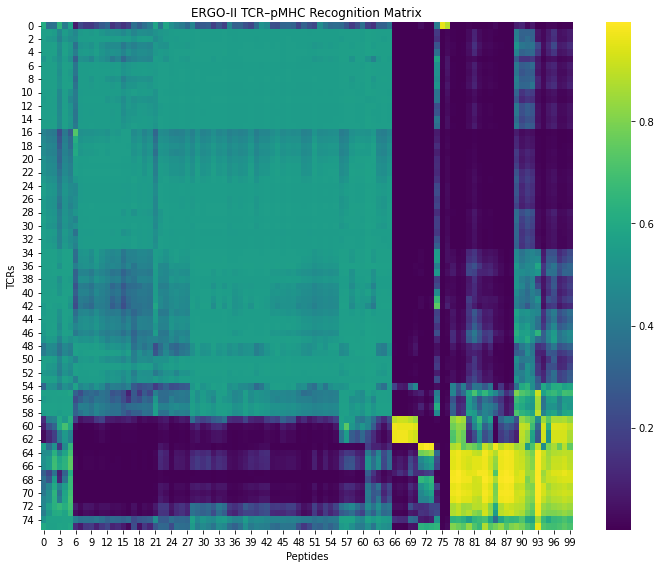

In [51]:
import numpy as np

pred = pd.read_csv("ergo_output_2.csv")

print(pred.columns)

# automatically detect score column
possible_score_cols = ["score", "Score", "prediction", "Prediction", "prob", "Probability"]

score_col = None
for c in possible_score_cols:
    if c in pred.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(f"No score column found. Columns are: {pred.columns}")

R = pred.pivot_table(
    index="TRB",
    columns="Peptide",
    values=score_col
).values

R = np.nan_to_num(R)

#R = R / (R.max(axis=0, keepdims=True) + 1e-8)

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

def ward_order(m):
    ro = leaves_list(linkage(pdist(m,   metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

row_order, col_order = ward_order(R)
R = R[np.ix_(row_order, col_order)].T  # Use np.ix_ to index rows and cols properly


# =========================
# 3. PLOT HEATMAP
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(R, cmap="viridis")

plt.xlabel("Peptides")
plt.ylabel("TCRs")
plt.title("ERGO-II TCR–pMHC Recognition Matrix")

plt.tight_layout()
plt.show()

## Atlas to Vdjdb

In [1]:
import pandas as pd
import numpy as np

# ========================================================================
# STEP 1: Load and Filter ATLAS Database
# ========================================================================

url = "https://atlas.ibbr.umd.edu/web/tables/ATLAS.tsv"
atlas = pd.read_csv(url, sep="\t", na_values=["\\N", "nan", ""])

# Parse Kd values
def parse_kd(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('>'):
        return np.nan
    val = val.split('+')[0].strip()
    try:
        return float(val)
    except ValueError:
        return np.nan

atlas['Kd_parsed'] = atlas['Kd_microM'].apply(parse_kd)

# Filter to wild-type entries with valid binding data
atlas_wt = atlas[
    (atlas['TCR_mut'] == 'WT') &
    (atlas['PEP_mut'] == 'WT') &
    (atlas['Kd_parsed'].notna())
].copy()

print(f"ATLAS WT entries: {len(atlas_wt)}")
print(f"Unique peptides: {atlas_wt['PEPseq'].nunique()}")
print(f"Unique MHCs: {atlas_wt['MHCname'].nunique()}")

# ========================================================================
# STEP 2: Select Top pMHC Combinations from ATLAS
# ========================================================================

# Create pMHC identifier (similar to VDJdb pipeline)
atlas_wt['pmhc'] = atlas_wt['PEPseq'] + "_" + atlas_wt['MHCname']

# Select based on measurement frequency or binding affinity
# Option A: Most frequently measured pMHCs
top_pmhc = atlas_wt['pmhc'].value_counts().head(50).index

# Option B: Best binders (lowest Kd)
# top_pmhc = atlas_wt.groupby('pmhc')['Kd_parsed'].min().nsmallest(50).index

atlas_selected = atlas_wt[atlas_wt['pmhc'].isin(top_pmhc)].copy()

print(f"\nSelected {len(top_pmhc)} pMHC combinations from ATLAS")
print(f"Total ATLAS entries: {len(atlas_selected)}")

# ========================================================================
# STEP 3: Load VDJdb and Match with ATLAS Selections
# ========================================================================

vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

# Filter VDJdb (similar to original pipeline)
vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

print(f"\nVDJdb entries after basic filtering: {len(vdjdb)}")

# Create pMHC identifier in VDJdb
vdjdb['pmhc'] = vdjdb['antigen.epitope'] + "_" + vdjdb['mhc.a']

# Extract peptides and MHCs from ATLAS selections
atlas_peptides = atlas_selected['PEPseq'].unique()
atlas_mhcs = atlas_selected['MHCname'].unique()
atlas_pmhcs = set(top_pmhc)

# Match VDJdb entries to ATLAS selections
# Strategy 1: Exact pMHC match
vdjdb_matched_exact = vdjdb[vdjdb['pmhc'].isin(atlas_pmhcs)].copy()

# Strategy 2: Match by peptide only (if MHC nomenclature differs)
vdjdb_matched_peptide = vdjdb[vdjdb['antigen.epitope'].isin(atlas_peptides)].copy()

# Strategy 3: Match by MHC only
vdjdb_matched_mhc = vdjdb[vdjdb['mhc.a'].isin(atlas_mhcs)].copy()

print(f"\nVDJdb matches:")
print(f"  Exact pMHC match: {len(vdjdb_matched_exact)}")
print(f"  Peptide match: {len(vdjdb_matched_peptide)}")
print(f"  MHC match: {len(vdjdb_matched_mhc)}")

# Choose matching strategy (start with exact, fall back to peptide)
if len(vdjdb_matched_exact) > 100:
    vdjdb_filtered = vdjdb_matched_exact
    match_strategy = "exact pMHC"
elif len(vdjdb_matched_peptide) > 100:
    vdjdb_filtered = vdjdb_matched_peptide
    match_strategy = "peptide"
else:
    vdjdb_filtered = vdjdb_matched_mhc
    match_strategy = "MHC"

print(f"\nUsing match strategy: {match_strategy}")
print(f"VDJdb filtered entries: {len(vdjdb_filtered)}")

# ========================================================================
# STEP 4: Create TCR × Epitope Matrix (similar to VDJdb pipeline)
# ========================================================================

# Select top TCRs and epitopes for a manageable matrix
top_epitopes = vdjdb_filtered['antigen.epitope'].value_counts().head(100).index
vdjdb_sub = vdjdb_filtered[vdjdb_filtered['antigen.epitope'].isin(top_epitopes)]

top_tcrs = vdjdb_sub['cdr3'].value_counts().head(100).index
vdjdb_sub = vdjdb_sub[vdjdb_sub['cdr3'].isin(top_tcrs)]

# Create binding matrix
matrix = vdjdb_sub.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=top_tcrs, columns=top_epitopes, fill_value=0)

print(f"\nBinding matrix shape: {matrix.shape}")
print(f"Fill rate: {(matrix > 0).sum().sum() / matrix.size:.1%}")

# ========================================================================
# STEP 5: Generate ERGO Input File
# ========================================================================

# Prepare data for ERGO
vdjdb_sub = vdjdb_sub.copy()
vdjdb_sub["TRB"] = vdjdb_sub["cdr3"].str.upper()
vdjdb_sub["Peptide"] = vdjdb_sub["antigen.epitope"].str.upper()

# Get final selections
final_peptides = vdjdb_sub["Peptide"].value_counts().head(100).index
vdjdb_sub = vdjdb_sub[vdjdb_sub["Peptide"].isin(final_peptides)]

final_tcrs = vdjdb_sub["TRB"].drop_duplicates().sample(
    min(100, vdjdb_sub["TRB"].nunique()), 
    random_state=0
).values

# Build ERGO input
rows = []
for tcr in final_tcrs:
    for pep in final_peptides[:100]:
        # Get MHC information if available
        mhc_info = vdjdb_sub[
            (vdjdb_sub["TRB"] == tcr) & 
            (vdjdb_sub["Peptide"] == pep)
        ]["mhc.a"].values
        
        mhc = mhc_info[0] if len(mhc_info) > 0 else ""
        
        rows.append({
            "TRB": tcr,
            "Peptide": pep,
            "MHC": mhc,
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

ergo_input = pd.DataFrame(rows)
ergo_input.to_csv("ergo_input_atlas_matched.csv", index=False)

print(f"\nWrote: ergo_input_atlas_matched.csv")
print(f"  {len(final_tcrs)} TCRs × {len(final_peptides)} peptides = {len(rows)} pairs")

# ========================================================================
# STEP 6: Summary Report
# ========================================================================

print("\n" + "="*70)
print("SUMMARY: ATLAS → VDJdb → ERGO Pipeline")
print("="*70)
print(f"ATLAS selections: {len(top_pmhc)} pMHC combinations")
print(f"VDJdb matches: {len(vdjdb_filtered)} entries ({match_strategy} matching)")
print(f"Final matrix: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")
print(f"ERGO input: {len(final_tcrs)} TCRs × {len(final_peptides)} peptides")
print(f"Output file: ergo_input_atlas_matched.csv")
print("="*70)

# Optional: Save matching summary
match_summary = pd.DataFrame({
    'atlas_pmhc': list(atlas_pmhcs),
    'in_vdjdb': [pmhc in vdjdb['pmhc'].values for pmhc in atlas_pmhcs]
})
match_summary.to_csv("atlas_vdjdb_match_summary.csv", index=False)
print("\nMatch summary saved to: atlas_vdjdb_match_summary.csv")

ATLAS WT entries: 175
Unique peptides: 46
Unique MHCs: 24

Selected 50 pMHC combinations from ATLAS
Total ATLAS entries: 171

VDJdb entries after basic filtering: 12333

VDJdb matches:
  Exact pMHC match: 3233
  Peptide match: 3500
  MHC match: 9533

Using match strategy: exact pMHC
VDJdb filtered entries: 3233

Binding matrix shape: (100, 15)
Fill rate: 6.7%

Wrote: ergo_input_atlas_matched.csv
  100 TCRs × 6 peptides = 600 pairs

SUMMARY: ATLAS → VDJdb → ERGO Pipeline
ATLAS selections: 50 pMHC combinations
VDJdb matches: 3233 entries (exact pMHC matching)
Final matrix: 100 TCRs × 15 epitopes
ERGO input: 100 TCRs × 6 peptides
Output file: ergo_input_atlas_matched.csv

Match summary saved to: atlas_vdjdb_match_summary.csv


In [2]:
import pandas as pd
import numpy as np

# Load ATLAS
url = "https://atlas.ibbr.umd.edu/web/tables/ATLAS.tsv"
atlas = pd.read_csv(url, sep="\t", na_values=["\\N", "nan", ""])

def parse_kd(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('>'):
        return np.nan
    val = val.split('+')[0].strip()
    try:
        return float(val)
    except ValueError:
        return np.nan

atlas['Kd_parsed'] = atlas['Kd_microM'].apply(parse_kd)
atlas_wt = atlas[
    (atlas['TCR_mut'] == 'WT') &
    (atlas['PEP_mut'] == 'WT') &
    (atlas['Kd_parsed'].notna())
].copy()

# ATLAS selections
atlas_wt['pmhc'] = atlas_wt['PEPseq'] + "_" + atlas_wt['MHCname']
top_pmhc = atlas_wt['pmhc'].value_counts().head(50).index
atlas_selected = atlas_wt[atlas_wt['pmhc'].isin(top_pmhc)].copy()

print("="*70)
print("DIAGNOSTIC: Where Did the Epitopes Go?")
print("="*70)

print(f"\n1. ATLAS: {len(top_pmhc)} pMHC combinations")
print(f"   Unique peptides in ATLAS selection: {atlas_selected['PEPseq'].nunique()}")
print(f"   Unique MHCs in ATLAS selection: {atlas_selected['MHCname'].nunique()}")

# Load VDJdb
vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")
vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

vdjdb['pmhc'] = vdjdb['antigen.epitope'] + "_" + vdjdb['mhc.a']
vdjdb_matched = vdjdb[vdjdb['pmhc'].isin(top_pmhc)].copy()

print(f"\n2. VDJdb exact pMHC match: {len(vdjdb_matched)} entries")
print(f"   How many of the 50 ATLAS pMHCs found in VDJdb: {vdjdb_matched['pmhc'].nunique()}")
print(f"   Unique epitopes: {vdjdb_matched['antigen.epitope'].nunique()}")
print(f"   Unique TCRs: {vdjdb_matched['cdr3'].nunique()}")

# Missing pMHCs
matched_pmhcs = set(vdjdb_matched['pmhc'].unique())
missing_pmhcs = set(top_pmhc) - matched_pmhcs
print(f"\n   ⚠️  {len(missing_pmhcs)} ATLAS pMHCs NOT found in VDJdb:")
for pmhc in list(missing_pmhcs)[:10]:  # show first 10
    pep, mhc = pmhc.split("_")
    count = atlas_selected[atlas_selected['pmhc'] == pmhc].shape[0]
    print(f"      - {pep} / {mhc} ({count} ATLAS measurements)")
if len(missing_pmhcs) > 10:
    print(f"      ... and {len(missing_pmhcs) - 10} more")

# Build matrix with co-occurrence filtering
top_epitopes = vdjdb_matched['antigen.epitope'].value_counts().head(100).index
vdjdb_sub = vdjdb_matched[vdjdb_matched['antigen.epitope'].isin(top_epitopes)]
top_tcrs = vdjdb_sub['cdr3'].value_counts().head(100).index
vdjdb_sub = vdjdb_sub[vdjdb_sub['cdr3'].isin(top_tcrs)]

print(f"\n3. After selecting top 100 TCRs & top 100 epitopes:")
print(f"   Entries: {len(vdjdb_sub)}")
print(f"   Unique epitopes in co-occurrence: {vdjdb_sub['antigen.epitope'].nunique()}")
print(f"   Unique TCRs: {vdjdb_sub['cdr3'].nunique()}")

# Build pivot to see actual matrix
matrix = vdjdb_sub.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=top_tcrs, columns=top_epitopes, fill_value=0)

print(f"\n4. Binding matrix: {matrix.shape}")
print(f"   Non-zero entries: {(matrix > 0).sum().sum()}")
print(f"   Epitopes with ≥1 TCR binding: {(matrix > 0).sum(axis=0).gt(0).sum()}")

# Show epitope coverage
epitope_coverage = (matrix > 0).sum(axis=0).sort_values(ascending=False)
print(f"\n   Top epitopes by TCR count:")
for ep, count in epitope_coverage.head(15).items():
    print(f"      {ep}: {int(count)} TCRs")

print("\n" + "="*70)

DIAGNOSTIC: Where Did the Epitopes Go?

1. ATLAS: 50 pMHC combinations
   Unique peptides in ATLAS selection: 42
   Unique MHCs in ATLAS selection: 23

2. VDJdb exact pMHC match: 3233 entries
   How many of the 50 ATLAS pMHCs found in VDJdb: 16
   Unique epitopes: 15
   Unique TCRs: 1288

   ⚠️  34 ATLAS pMHCs NOT found in VDJdb:
      - VMAPRTLIL / HLA-E*01:01 (1 ATLAS measurements)
      - SGEGSFQPSQENP / HLA-DQA1*03:01 | HLA-DQB1*03:02 (1 ATLAS measurements)
      - FEAQKAKANKAVD / I-Ab (2 ATLAS measurements)
      - ANERADLIAYLKQATK / I-Ek (17 ATLAS measurements)
      - RFPLTFGWCF / HLA-A*24:02 (2 ATLAS measurements)
      - EENLLDFVRF / HLA-B*44:02 (1 ATLAS measurements)
      - EGSFQPSQE / HLA-DQA1*03:01 | HLA-DQB1*03:02 (3 ATLAS measurements)
      - EEYLKAWTF / HLA-B*44:02 (1 ATLAS measurements)
      - SPLDSLWWI / H-2Ld (1 ATLAS measurements)
      - ALWGPDPAAA / HLA-A*02:01 (1 ATLAS measurements)
      ... and 24 more

3. After selecting top 100 TCRs & top 100 epitopes:
   E

In [3]:
import pandas as pd
import numpy as np

# Load and filter as before
url = "https://atlas.ibbr.umd.edu/web/tables/ATLAS.tsv"
atlas = pd.read_csv(url, sep="\t", na_values=["\\N", "nan", ""])

def parse_kd(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('>'):
        return np.nan
    val = val.split('+')[0].strip()
    try:
        return float(val)
    except ValueError:
        return np.nan

atlas['Kd_parsed'] = atlas['Kd_microM'].apply(parse_kd)
atlas_wt = atlas[
    (atlas['TCR_mut'] == 'WT') &
    (atlas['PEP_mut'] == 'WT') &
    (atlas['Kd_parsed'].notna())
].copy()

atlas_wt['pmhc'] = atlas_wt['PEPseq'] + "_" + atlas_wt['MHCname']
atlas_peptides = atlas_wt['PEPseq'].unique()

# Load VDJdb
vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

# Match by peptide (more permissive than exact pMHC)
vdjdb_matched = vdjdb[vdjdb['antigen.epitope'].isin(atlas_peptides)].copy()

print(f"VDJdb entries matching ATLAS peptides: {len(vdjdb_matched)}")
print(f"Unique epitopes: {vdjdb_matched['antigen.epitope'].nunique()}")

# ========================================================================
# STRATEGY: Epitope-first selection with viral diversity
# ========================================================================

# Add pathogen annotation for diversity
pathogen_keywords = {
    'CMV': ['NLVPMVATV', 'TPRVTGGGAM', 'IPSINVHHY'],
    'EBV': ['GLCTLVAML', 'RAKFKQLL', 'RPPIFIRRL', 'EENLLDFVRF'],
    'HIV': ['KRWIILGLNK', 'SLYNTVATL', 'KAFSPEVIPMF'],
    'Influenza': ['GILGFVFTL', 'CTELKLSDY'],
    'HCV': ['KLVALGINAV', 'CINGVCWTV'],
    'SARS-CoV-2': ['YLQPRTFLL', 'SPRWYFYYL'],
    'Melanoma': ['ELAGIGILTV', 'EAAGIGILTV', 'AAGIGILTV'],
    'Other': []
}

def assign_pathogen(epitope):
    for pathogen, epitopes in pathogen_keywords.items():
        if epitope in epitopes:
            return pathogen
    return 'Other'

vdjdb_matched['pathogen'] = vdjdb_matched['antigen.epitope'].apply(assign_pathogen)

# Count epitopes per pathogen
print("\nEpitopes per pathogen:")
print(vdjdb_matched.groupby('pathogen')['antigen.epitope'].nunique().sort_values(ascending=False))

# ========================================================================
# STEP 1: Select diverse epitopes (balanced across pathogens)
# ========================================================================

n_epitopes_per_pathogen = 3  # Adjust as needed
selected_epitopes = []

for pathogen in vdjdb_matched['pathogen'].unique():
    if pathogen == 'Other':
        continue
    
    # Get top epitopes for this pathogen (by TCR count = well-studied)
    pathogen_epitopes = vdjdb_matched[
        vdjdb_matched['pathogen'] == pathogen
    ]['antigen.epitope'].value_counts().head(n_epitopes_per_pathogen)
    
    selected_epitopes.extend(pathogen_epitopes.index.tolist())

print(f"\n✓ Selected {len(selected_epitopes)} epitopes across {len(set(vdjdb_matched[vdjdb_matched['antigen.epitope'].isin(selected_epitopes)]['pathogen']))} pathogens")

# ========================================================================
# STEP 2: For each epitope, select N cognate TCRs (high-confidence binders)
# ========================================================================

n_tcrs_per_epitope = 5  # 3-10 works well for this approach

selected_tcrs = []
epitope_tcr_map = {}

for epitope in selected_epitopes:
    # Get TCRs that bind this epitope, prioritize high confidence
    ep_data = vdjdb_matched[vdjdb_matched['antigen.epitope'] == epitope].copy()
    
    # Sort by confidence score (higher = better) then by frequency
    ep_data = ep_data.sort_values('vdjdb.score', ascending=False)
    
    # Get top N unique TCRs
    cognate_tcrs = ep_data['cdr3'].drop_duplicates().head(n_tcrs_per_epitope).tolist()
    
    selected_tcrs.extend(cognate_tcrs)
    epitope_tcr_map[epitope] = cognate_tcrs
    
    print(f"  {epitope:15s} ({ep_data['pathogen'].iloc[0]:12s}): {len(cognate_tcrs)} TCRs")

selected_tcrs = list(set(selected_tcrs))  # Remove duplicates

print(f"\n✓ Total unique TCRs: {len(selected_tcrs)}")

# ========================================================================
# STEP 3: Build the binding matrix
# ========================================================================

vdjdb_final = vdjdb_matched[
    (vdjdb_matched['cdr3'].isin(selected_tcrs)) &
    (vdjdb_matched['antigen.epitope'].isin(selected_epitopes))
]

matrix = vdjdb_final.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).fillna(0)

print(f"\n✓ Binding matrix: {matrix.shape}")
print(f"  Non-zero entries: {(matrix > 0).sum().sum()} / {matrix.size} ({(matrix > 0).sum().sum() / matrix.size * 100:.1f}%)")
print(f"  Diagonal-heavy: {(matrix > 0).sum(axis=1).mean():.1f} epitopes per TCR on average")

# Check that each epitope has cognate TCRs
epitope_coverage = (matrix > 0).sum(axis=0)
print(f"\n  Epitope coverage:")
for ep in matrix.columns:
    n_tcrs = int(epitope_coverage[ep])
    pathogen = vdjdb_matched[vdjdb_matched['antigen.epitope'] == ep]['pathogen'].iloc[0]
    print(f"    {ep:15s} ({pathogen:12s}): {n_tcrs:3d} TCRs")

# ========================================================================
# STEP 4: Generate ERGO input (all pairwise combinations for prediction)
# ========================================================================

rows = []
for tcr in selected_tcrs:
    for epitope in selected_epitopes:
        # Get MHC if available
        mhc_data = vdjdb_matched[
            (vdjdb_matched['cdr3'] == tcr) &
            (vdjdb_matched['antigen.epitope'] == epitope)
        ]
        
        mhc = mhc_data['mhc.a'].iloc[0] if len(mhc_data) > 0 else ""
        
        rows.append({
            "TRB": tcr.upper(),
            "Peptide": epitope.upper(),
            "MHC": mhc,
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

ergo_input = pd.DataFrame(rows)
ergo_input.to_csv("ergo_input_atlas_diverse.csv", index=False)

print(f"\n✓ ERGO input saved: {len(selected_tcrs)} TCRs × {len(selected_epitopes)} epitopes = {len(rows)} pairs")
print("  Known diagonal entries: ", (matrix > 0).sum().sum())
print("  ERGO will predict: ", len(rows) - (matrix > 0).sum().sum(), "off-diagonal entries")

VDJdb entries matching ATLAS peptides: 8374
Unique epitopes: 25

Epitopes per pathogen:
pathogen
Other        17
Melanoma      3
EBV           2
CMV           1
HIV           1
Influenza     1
Name: antigen.epitope, dtype: int64

✓ Selected 8 epitopes across 5 pathogens
  GILGFVFTL       (Influenza   ): 5 TCRs
  GLCTLVAML       (EBV         ): 5 TCRs
  EENLLDFVRF      (EBV         ): 1 TCRs
  NLVPMVATV       (CMV         ): 5 TCRs
  KRWIILGLNK      (HIV         ): 5 TCRs
  ELAGIGILTV      (Melanoma    ): 5 TCRs
  EAAGIGILTV      (Melanoma    ): 5 TCRs
  AAGIGILTV       (Melanoma    ): 5 TCRs

✓ Total unique TCRs: 30

✓ Binding matrix: (30, 8)
  Non-zero entries: 38 / 240 (15.8%)
  Diagonal-heavy: 1.3 epitopes per TCR on average

  Epitope coverage:
    AAGIGILTV       (Melanoma    ):   5 TCRs
    EAAGIGILTV      (Melanoma    ):   5 TCRs
    EENLLDFVRF      (EBV         ):   1 TCRs
    ELAGIGILTV      (Melanoma    ):   7 TCRs
    GILGFVFTL       (Influenza   ):   5 TCRs
    GLCTLVAML   

In [8]:
import pandas as pd
import numpy as np

# ========================================================================
# Load and filter ATLAS + VDJdb
# ========================================================================

url = "https://atlas.ibbr.umd.edu/web/tables/ATLAS.tsv"
atlas = pd.read_csv(url, sep="\t", na_values=["\\N", "nan", ""])

def parse_kd(val):
    if pd.isna(val):
        return np.nan
    val = str(val).strip()
    if val.startswith('>'):
        return np.nan
    val = val.split('+')[0].strip()
    try:
        return float(val)
    except ValueError:
        return np.nan

atlas['Kd_parsed'] = atlas['Kd_microM'].apply(parse_kd)
atlas_wt = atlas[
    (atlas['TCR_mut'] == 'WT') &
    (atlas['PEP_mut'] == 'WT') &
    (atlas['Kd_parsed'].notna())
].copy()

atlas_peptides = atlas_wt['PEPseq'].unique()

# Load VDJdb
vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

# Match by peptide to ATLAS
vdjdb_matched = vdjdb[vdjdb['antigen.epitope'].isin(atlas_peptides)].copy()

print(f"VDJdb entries matching ATLAS peptides: {len(vdjdb_matched)}")
print(f"Available epitopes: {vdjdb_matched['antigen.epitope'].nunique()}")

# ========================================================================
# Pathogen annotation for diversity
# ========================================================================

# Expanded pathogen mapping
pathogen_map = {
    # CMV
    'NLVPMVATV': 'CMV', 'TPRVTGGGAM': 'CMV', 'IPSINVHHY': 'CMV', 
    'QYDPVAALF': 'CMV', 'ATKMVQKI': 'CMV',
    
    # EBV
    'GLCTLVAML': 'EBV', 'RAKFKQLL': 'EBV', 'RPPIFIRRL': 'EBV', 
    'EENLLDFVRF': 'EBV', 'QAKWRLQTL': 'EBV', 'RYSIFFDY': 'EBV',
    
    # HIV
    'KRWIILGLNK': 'HIV', 'SLYNTVATL': 'HIV', 'KAFSPEVIPMF': 'HIV',
    'FRDYVDRFYK': 'HIV', 'KQIINMWQEV': 'HIV',
    
    # Influenza
    'GILGFVFTL': 'Influenza', 'CTELKLSDY': 'Influenza', 'ILRGSVAHK': 'Influenza',
    'SSLENFRAYV': 'Influenza', 'ASCMGLIY': 'Influenza',
    
    # HCV
    'KLVALGINAV': 'HCV', 'CINGVCWTV': 'HCV', 'ATDALMTGY': 'HCV',
    
    # SARS-CoV-2
    'YLQPRTFLL': 'SARS-CoV-2', 'SPRWYFYYL': 'SARS-CoV-2', 
    'KTFPPTEPK': 'SARS-CoV-2', 'RLQSLQTYV': 'SARS-CoV-2',
    
    # Melanoma/Cancer
    'ELAGIGILTV': 'Melanoma', 'EAAGIGILTV': 'Melanoma', 'AAGIGILTV': 'Melanoma',
    'FLRGRAYGL': 'MART-1', 'YLEPGPVTA': 'MAGE',
    
    # Dengue
    'TAFTIPSI': 'Dengue', 'IGVSNRDFV': 'Dengue',
    
    # HBV
    'FLPSDFFPSV': 'HBV', 'GLSRYVARL': 'HBV',
    
    # Other viruses
    'HPVGEADYFEY': 'Yellow Fever', 'LPEPLPQGQLTAY': 'HPV',
}

def assign_pathogen(epitope):
    return pathogen_map.get(epitope, 'Other')

vdjdb_matched['pathogen'] = vdjdb_matched['antigen.epitope'].apply(assign_pathogen)

# Count available epitopes per pathogen
print("\n" + "="*70)
print("Available epitopes per pathogen:")
print("="*70)
pathogen_counts = vdjdb_matched.groupby('pathogen').agg({
    'antigen.epitope': 'nunique',
    'cdr3': 'count'
}).rename(columns={'antigen.epitope': 'n_epitopes', 'cdr3': 'n_entries'})
pathogen_counts = pathogen_counts.sort_values('n_epitopes', ascending=False)
print(pathogen_counts)

# ========================================================================
# STRATEGY: Select 50 epitopes with maximum pathogen diversity
# Then select 1 cognate TCR per epitope = 50 TCRs
# ========================================================================

target_epitopes = 50
target_tcrs = 50
n_tcrs_per_epitope = 1  # Lean and mean!

# Step 1: Select epitopes - round-robin across pathogens for diversity
selected_epitopes = []
epitope_pathogen_map = {}

# Get all epitopes sorted by data quality (TCR count = well-studied)
epitope_quality = vdjdb_matched.groupby('antigen.epitope').agg({
    'cdr3': 'count',
    'pathogen': 'first',
    'vdjdb.score': 'mean'
}).rename(columns={'cdr3': 'n_tcrs', 'vdjdb.score': 'avg_score'})

epitope_quality = epitope_quality.sort_values(['avg_score', 'n_tcrs'], ascending=False)

# Round-robin selection across pathogens
pathogens_with_data = [p for p in pathogen_counts.index if p != 'Other']
epitopes_per_pathogen = {}

for pathogen in pathogens_with_data:
    epitopes_per_pathogen[pathogen] = epitope_quality[
        epitope_quality['pathogen'] == pathogen
    ].index.tolist()

# Round-robin until we have 50 epitopes
round_idx = 0
while len(selected_epitopes) < target_epitopes:
    for pathogen in pathogens_with_data:
        if len(selected_epitopes) >= target_epitopes:
            break
        
        available = epitopes_per_pathogen[pathogen]
        
        # Get next epitope for this pathogen that we haven't selected yet
        for ep in available:
            if ep not in selected_epitopes:
                selected_epitopes.append(ep)
                epitope_pathogen_map[ep] = pathogen
                break
    
    round_idx += 1
    if round_idx > 20:  # Safety break
        break

# If we didn't get 50, fill from "Other"
if len(selected_epitopes) < target_epitopes:
    other_epitopes = epitope_quality[epitope_quality['pathogen'] == 'Other'].index.tolist()
    for ep in other_epitopes:
        if len(selected_epitopes) >= target_epitopes:
            break
        if ep not in selected_epitopes:
            selected_epitopes.append(ep)
            epitope_pathogen_map[ep] = 'Other'

selected_epitopes = selected_epitopes[:target_epitopes]

print(f"\n✓ Selected {len(selected_epitopes)} epitopes")
print("\nEpitopes per pathogen:")
from collections import Counter
pathogen_distribution = Counter(epitope_pathogen_map.values())
for pathogen, count in sorted(pathogen_distribution.items(), key=lambda x: -x[1]):
    print(f"  {pathogen:15s}: {count:2d} epitopes")



# ========================================================================
# Generate ERGO input file
# ========================================================================

rows = []
for tcr in selected_tcrs:
    for epitope in selected_epitopes:
        # Get MHC if available
        mhc_data = vdjdb_matched[
            (vdjdb_matched['cdr3'] == tcr) &
            (vdjdb_matched['antigen.epitope'] == epitope)
        ]
        
        mhc = mhc_data['mhc.a'].iloc[0] if len(mhc_data) > 0 else ""
        
        rows.append({
            "TRB": tcr.upper(),
            "Peptide": epitope.upper(),
            "MHC": mhc,
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

ergo_input = pd.DataFrame(rows)
ergo_input.to_csv("ergo_input_50x50_diverse.csv", index=False)

print(f"✓ ERGO input saved: ergo_input_50x50_diverse.csv")
print(f"  {len(selected_tcrs)} TCRs × {len(selected_epitopes)} epitopes = {len(rows)} total pairs")

VDJdb entries matching ATLAS peptides: 8374
Available epitopes: 25

Available epitopes per pathogen:
              n_epitopes  n_entries
pathogen                           
Other                 13         93
Melanoma               3        187
EBV                    2        754
CMV                    1       1658
Dengue                 1         23
HIV                    1        226
HPV                    1         10
Influenza              1       4869
MART-1                 1        508
Yellow Fever           1         46

✓ Selected 25 epitopes

Epitopes per pathogen:
  Other          : 13 epitopes
  Melanoma       :  3 epitopes
  EBV            :  2 epitopes
  CMV            :  1 epitopes
  Dengue         :  1 epitopes
  HIV            :  1 epitopes
  HPV            :  1 epitopes
  Influenza      :  1 epitopes
  MART-1         :  1 epitopes
  Yellow Fever   :  1 epitopes
✓ ERGO input saved: ergo_input_50x50_diverse.csv
  30 TCRs × 25 epitopes = 750 total pairs


In [12]:
import pandas as pd
import numpy as np
from collections import Counter

# ========================================================================
# 1. LOAD AND FILTER VDJdb
# ========================================================================

vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

# Basic quality filters
vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

# Validate sequences
AA = set("ACDEFGHIKLMNPQRSTVWY")

def valid_seq(seq):
    return isinstance(seq, str) and len(seq) > 0 and set(seq).issubset(AA)

vdjdb = vdjdb[vdjdb['cdr3'].apply(valid_seq)]
vdjdb = vdjdb[vdjdb['antigen.epitope'].apply(valid_seq)]

# Filter epitope length (typical MHC-I = 8-11)
vdjdb = vdjdb[vdjdb['antigen.epitope'].str.len().between(8, 11)]

print(f"VDJdb entries after filtering: {len(vdjdb)}")
print(f"Unique epitopes: {vdjdb['antigen.epitope'].nunique()}")
print(f"Unique TCRs: {vdjdb['cdr3'].nunique()}")

# ========================================================================
# 2. PATHOGEN ANNOTATION
# ========================================================================

# Comprehensive pathogen mapping
pathogen_map = {
    # CMV
    'NLVPMVATV': 'CMV', 'TPRVTGGGAM': 'CMV', 'IPSINVHHY': 'CMV', 
    'QYDPVAALF': 'CMV', 'ATKMVQKI': 'CMV', 'VYALPLKML': 'CMV',
    'SDEEEAIVAYTL': 'CMV', 'TPRVTGGGAM': 'CMV',
    
    # EBV
    'GLCTLVAML': 'EBV', 'RAKFKQLL': 'EBV', 'RPPIFIRRL': 'EBV', 
    'EENLLDFVRF': 'EBV', 'QAKWRLQTL': 'EBV', 'RYSIFFDY': 'EBV',
    'FLRGRAYGL': 'EBV', 'ATIGTAMYK': 'EBV', 'CLGGLLTMV': 'EBV',
    
    # HIV
    'KRWIILGLNK': 'HIV', 'SLYNTVATL': 'HIV', 'KAFSPEVIPMF': 'HIV',
    'FRDYVDRFYK': 'HIV', 'KQIINMWQEV': 'HIV', 'QATQEVKNW': 'HIV',
    'RLRPGGKKK': 'HIV', 'KIRLRPGGK': 'HIV',
    
    # Influenza
    'GILGFVFTL': 'Influenza', 'CTELKLSDY': 'Influenza', 'ILRGSVAHK': 'Influenza',
    'SSLENFRAYV': 'Influenza', 'ASCMGLIY': 'Influenza', 'FMYSDFHFI': 'Influenza',
    'YVFVGTSRY': 'Influenza',
    
    # HCV
    'KLVALGINAV': 'HCV', 'CINGVCWTV': 'HCV', 'ATDALMTGY': 'HCV',
    'YLLPRRGPRL': 'HCV', 'DLMGYIPLV': 'HCV',
    
    # SARS-CoV-2
    'YLQPRTFLL': 'SARS-CoV-2', 'SPRWYFYYL': 'SARS-CoV-2', 
    'KTFPPTEPK': 'SARS-CoV-2', 'RLQSLQTYV': 'SARS-CoV-2',
    'QYIKWPWYI': 'SARS-CoV-2', 'LLLDRLNQL': 'SARS-CoV-2',
    
    # Melanoma/Cancer
    'ELAGIGILTV': 'Melanoma', 'EAAGIGILTV': 'Melanoma', 'AAGIGILTV': 'Melanoma',
    'YLEPGPVTA': 'MAGE-A3', 'KTWGQYWQV': 'gp100', 'YMDGTMSQV': 'MART-1',
    
    # Dengue
    'TAFTIPSI': 'Dengue', 'IGVSNRDFV': 'Dengue', 'AGFGAAYF': 'Dengue',
    
    # HBV
    'FLPSDFFPSV': 'HBV', 'GLSRYVARL': 'HBV', 'FLLTRILTI': 'HBV',
    
    # Other viruses
    'HPVGEADYFEY': 'Yellow Fever', 'LPEPLPQGQLTAY': 'HPV',
    'VYALPLKML': 'CMV', 'QYDDAVYKL': 'HPV',
}

def assign_pathogen(epitope):
    return pathogen_map.get(epitope, 'Other')

vdjdb['pathogen'] = vdjdb['antigen.epitope'].apply(assign_pathogen)

# ========================================================================
# 3. CHECK DATA AVAILABILITY PER EPITOPE
# ========================================================================

epitope_stats = vdjdb.groupby('antigen.epitope').agg({
    'cdr3': 'nunique',
    'vdjdb.score': ['mean', 'max'],
    'pathogen': 'first'
}).reset_index()

epitope_stats.columns = ['epitope', 'n_unique_tcrs', 'avg_score', 'max_score', 'pathogen']
epitope_stats = epitope_stats.sort_values(['n_unique_tcrs', 'max_score'], ascending=False)

print("\n" + "="*70)
print("EPITOPE DATA AVAILABILITY")
print("="*70)
print(f"Total epitopes in VDJdb: {len(epitope_stats)}")

# Show per-pathogen stats
pathogen_summary = epitope_stats.groupby('pathogen').agg({
    'epitope': 'count',
    'n_unique_tcrs': 'sum'
}).rename(columns={'epitope': 'n_epitopes', 'n_unique_tcrs': 'total_tcrs'})
pathogen_summary = pathogen_summary.sort_values('n_epitopes', ascending=False)

print("\nEpitopes per pathogen:")
print(pathogen_summary)

# ========================================================================
# 4. SELECT 50 EPITOPES WITH MAXIMUM PATHOGEN DIVERSITY
# ========================================================================

target_epitopes = 50
n_tcrs_per_epitope = 1  # Can set to 2 for more diagonal coverage

# Filter to epitopes with sufficient TCRs
min_tcrs_required = n_tcrs_per_epitope + 2  # Buffer for conflicts
eligible = epitope_stats[epitope_stats['n_unique_tcrs'] >= min_tcrs_required].copy()

print(f"\n✓ Eligible epitopes (≥{min_tcrs_required} unique TCRs): {len(eligible)}")

# Group by pathogen
epitopes_by_pathogen = {}
for pathogen in eligible['pathogen'].unique():
    epitopes_by_pathogen[pathogen] = eligible[
        eligible['pathogen'] == pathogen
    ].sort_values('n_unique_tcrs', ascending=False)['epitope'].tolist()

# Round-robin selection for diversity
selected_epitopes = []
epitope_pathogen_map = {}

pathogens = [p for p in epitopes_by_pathogen.keys() if p != 'Other']
pathogen_idx = {p: 0 for p in pathogens}

print(f"\n{'Pathogen':<15} {'Available':<12} {'Target':<10}")
print("-" * 40)
for p in pathogens:
    print(f"{p:<15} {len(epitopes_by_pathogen[p]):<12}")

print("\nRound-robin selection:")
round_num = 0
while len(selected_epitopes) < target_epitopes:
    added = 0
    round_num += 1
    
    for pathogen in pathogens:
        if len(selected_epitopes) >= target_epitopes:
            break
        
        idx = pathogen_idx[pathogen]
        available = epitopes_by_pathogen.get(pathogen, [])
        
        if idx < len(available):
            ep = available[idx]
            if ep not in selected_epitopes:
                selected_epitopes.append(ep)
                epitope_pathogen_map[ep] = pathogen
                added += 1
            pathogen_idx[pathogen] += 1
    
    print(f"  Round {round_num}: added {added} epitopes (total: {len(selected_epitopes)})")
    
    if added == 0:
        print(f"\n⚠️  Only {len(selected_epitopes)} epitopes available with diversity")
        break

# Fill remaining from 'Other' if needed
if len(selected_epitopes) < target_epitopes and 'Other' in epitopes_by_pathogen:
    print(f"\nFilling remaining slots from 'Other'...")
    for ep in epitopes_by_pathogen['Other']:
        if len(selected_epitopes) >= target_epitopes:
            break
        if ep not in selected_epitopes:
            selected_epitopes.append(ep)
            epitope_pathogen_map[ep] = 'Other'

print(f"\n✓ Final selection: {len(selected_epitopes)} epitopes")

# Show distribution
dist = Counter(epitope_pathogen_map.values())
print("\nFinal pathogen distribution:")
for pathogen, count in sorted(dist.items(), key=lambda x: -x[1]):
    print(f"  {pathogen:<15}: {count:2d} epitopes")

# ========================================================================
# 5. ASSIGN TCRS - STRICT 1-TO-1 MAPPING
# ========================================================================

selected_tcrs = []
tcr_to_epitope = {}
epitope_tcr_map = {}

print(f"\n{'Epitope':<15} {'Pathogen':<15} {'Avail TCRs':<12} {'Assigned':<10} {'Score':<8}")
print("-" * 65)

for epitope in selected_epitopes:
    pathogen = epitope_pathogen_map[epitope]
    
    ep_data = vdjdb[vdjdb['antigen.epitope'] == epitope].copy()
    ep_data = ep_data.sort_values('vdjdb.score', ascending=False)
    
    # Assign n_tcrs_per_epitope unique TCRs
    cognate_tcrs = []
    available_count = ep_data['cdr3'].nunique()
    
    for tcr in ep_data['cdr3'].unique():
        if tcr not in tcr_to_epitope:  # TCR not yet assigned to another epitope
            cognate_tcrs.append(tcr)
            tcr_to_epitope[tcr] = epitope
            selected_tcrs.append(tcr)
            if len(cognate_tcrs) >= n_tcrs_per_epitope:
                break
    
    epitope_tcr_map[epitope] = cognate_tcrs
    max_score = ep_data['vdjdb.score'].max()
    
    print(f"{epitope:<15} {pathogen:<15} {available_count:<12} {len(cognate_tcrs):<10} {max_score:<8}")

print(f"\n✓ Total unique TCRs selected: {len(selected_tcrs)}")
print(f"✓ Expected diagonal entries: {len(selected_epitopes) * n_tcrs_per_epitope}")

# ========================================================================
# 6. BUILD KNOWN BINDING MATRIX (DIAGONAL ONLY)
# ========================================================================

# Create rows for only the intended cognate pairs
diagonal_rows = []
for epitope, tcrs in epitope_tcr_map.items():
    for tcr in tcrs:
        score_data = vdjdb[
            (vdjdb['cdr3'] == tcr) &
            (vdjdb['antigen.epitope'] == epitope)
        ]
        score = score_data['vdjdb.score'].max()
        
        diagonal_rows.append({
            'cdr3': tcr,
            'antigen.epitope': epitope,
            'vdjdb.score': score
        })

diagonal_df = pd.DataFrame(diagonal_rows)

known_matrix = diagonal_df.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=selected_tcrs, columns=selected_epitopes, fill_value=0)

print(f"\n" + "="*70)
print("BINDING MATRIX")
print("="*70)
print(f"Shape: {known_matrix.shape}")
print(f"Total cells: {known_matrix.size:,}")
print(f"Known diagonal entries: {(known_matrix > 0).sum().sum()}")
print(f"Fill rate: {(known_matrix > 0).sum().sum() / known_matrix.size * 100:.1f}%")

# Verify diagonal structure
tcrs_per_epitope = (known_matrix > 0).sum(axis=0)
epitopes_per_tcr = (known_matrix > 0).sum(axis=1)

print(f"\nDiagonal verification:")
print(f"  Epitopes with ≥1 TCR: {(tcrs_per_epitope > 0).sum()} / {len(selected_epitopes)}")
print(f"  TCRs per epitope (mean): {tcrs_per_epitope.mean():.2f}")
print(f"  Epitopes per TCR (mean): {epitopes_per_tcr.mean():.2f}")

# ========================================================================
# 7. GENERATE ERGO INPUT FILE
# ========================================================================

rows = []
for tcr in selected_tcrs:
    for epitope in selected_epitopes:
        # Get MHC info
        mhc_data = vdjdb[
            (vdjdb['cdr3'] == tcr) &
            (vdjdb['antigen.epitope'] == epitope)
        ]
        mhc = mhc_data['mhc.a'].iloc[0] if len(mhc_data) > 0 else ""
        
        rows.append({
            "TRB": tcr.upper(),
            "Peptide": epitope.upper(),
            "MHC": mhc,
            "TRA": "",
            "TRAV": "",
            "TRAJ": "",
            "TRBV": "",
            "TRBJ": "",
            "T-Cell-Type": ""
        })

ergo_input = pd.DataFrame(rows)
ergo_input.to_csv("ergo_input_vdjdb_50x50.csv", index=False)

print(f"\n✓ ERGO input saved: ergo_input_vdjdb_50x50.csv")
print(f"  {len(selected_tcrs)} TCRs × {len(selected_epitopes)} epitopes = {len(rows)} pairs")

# Save matrices and metadata
known_matrix.to_csv("known_binding_matrix_50x50.csv")
print(f"✓ Known binding matrix saved: known_binding_matrix_50x50.csv")

metadata = pd.DataFrame([
    {
        'epitope': ep, 
        'pathogen': epitope_pathogen_map[ep],
        'n_cognate_tcrs': len(epitope_tcr_map[ep]),
        'cognate_tcrs': ','.join(epitope_tcr_map[ep])
    }
    for ep in selected_epitopes
])
metadata.to_csv("epitope_metadata_vdjdb.csv", index=False)
print(f"✓ Metadata saved: epitope_metadata_vdjdb.csv")

print("\n" + "="*70)
print("READY FOR ERGO!")
print("="*70)

VDJdb entries after filtering: 12265
Unique epitopes: 334
Unique TCRs: 5466

EPITOPE DATA AVAILABILITY
Total epitopes in VDJdb: 334

Epitopes per pathogen:
              n_epitopes  total_tcrs
pathogen                            
Other                303        1984
EBV                    6         380
SARS-CoV-2             6         247
CMV                    4        1014
HIV                    4         300
HCV                    3         237
Melanoma               3         175
Influenza              2        1282
Dengue                 1          13
MAGE-A3                1           4
Yellow Fever           1          27

✓ Eligible epitopes (≥3 unique TCRs): 134

Pathogen        Available    Target    
----------------------------------------
Influenza       2           
CMV             4           
EBV             5           
Melanoma        3           
HIV             4           
HCV             3           
SARS-CoV-2      6           
Yellow Fever    1           
Dengue

In [17]:
# ========================================================================
# CHECK WHAT ADDITIONAL FEATURES ARE AVAILABLE IN VDJdb
# ========================================================================

print("VDJdb columns available:")
print(vdjdb.columns.tolist())

# Check feature availability
print("\n" + "="*70)
print("FEATURE AVAILABILITY IN VDJdb")
print("="*70)

features = {
    'V gene (beta)': ['v.segm', 'v.beta'],
    'J gene (beta)': ['j.segm', 'j.beta'],
    'MHC': ['mhc.a', 'mhc.b'],
    'TCR alpha': ['cdr3.alpha'],
    'V gene (alpha)': ['v.alpha'],
    'J gene (alpha)': ['j.alpha'],
    'T-cell type': ['cell.subset', 'cell.type']
}

for feature_name, possible_cols in features.items():
    available = [col for col in possible_cols if col in vdjdb.columns]
    if available:
        col = available[0]
        non_null = vdjdb[col].notna().sum()
        pct = non_null / len(vdjdb) * 100
        print(f"✓ {feature_name:<20}: {col:<15} ({non_null:>6} / {len(vdjdb):>6} = {pct:>5.1f}%)")
    else:
        print(f"✗ {feature_name:<20}: Not available")

# ========================================================================
# IMPROVED ERGO INPUT WITH ALL AVAILABLE FEATURES
# ========================================================================

def extract_gene_name(gene_str):
    """Extract gene name from VDJdb format (e.g., 'TRBV7-9*01' -> 'TRBV7-9')"""
    if pd.isna(gene_str) or gene_str == '':
        return ""
    # Remove allele info (*01, *02, etc.)
    return str(gene_str).split('*')[0].strip()

print("\n" + "="*70)
print("BUILDING ENHANCED ERGO INPUT")
print("="*70)

rows = []
feature_coverage = {
    'MHC': 0,
    'TRBV': 0,
    'TRBJ': 0,
    'TRA': 0,
    'TRAV': 0,
    'TRAJ': 0,
    'T-Cell-Type': 0
}

for tcr in selected_tcrs:
    for epitope in selected_epitopes:
        # Get all VDJdb data for this pair
        pair_data = vdjdb[
            (vdjdb['cdr3'] == tcr) &
            (vdjdb['antigen.epitope'] == epitope)
        ]
        
        # If no data for this specific pair, get data for the TCR alone
        if len(pair_data) == 0:
            tcr_data = vdjdb[vdjdb['cdr3'] == tcr]
            if len(tcr_data) > 0:
                pair_data = tcr_data.iloc[[0]]  # Use first entry
        
        # Extract features
        if len(pair_data) > 0:
            row_data = pair_data.iloc[0]
            
            # MHC
            mhc = row_data.get('mhc.a', '')
            if pd.notna(mhc) and mhc != '':
                feature_coverage['MHC'] += 1
            else:
                mhc = ""
            
            # Beta V/J genes
            trbv = ""
            if 'v.segm' in vdjdb.columns:
                trbv = extract_gene_name(row_data.get('v.segm', ''))
                if trbv:
                    feature_coverage['TRBV'] += 1
            
            trbj = ""
            if 'j.segm' in vdjdb.columns:
                trbj = extract_gene_name(row_data.get('j.segm', ''))
                if trbj:
                    feature_coverage['TRBJ'] += 1
            
            # Alpha chain (if paired data available)
            tra = ""
            if 'cdr3.alpha' in vdjdb.columns:
                tra = row_data.get('cdr3.alpha', '')
                if pd.notna(tra) and tra != '':
                    feature_coverage['TRA'] += 1
                else:
                    tra = ""
            
            # Alpha V/J genes
            trav = ""
            if 'v.alpha' in vdjdb.columns:
                trav = extract_gene_name(row_data.get('v.alpha', ''))
                if trav:
                    feature_coverage['TRAV'] += 1
            
            traj = ""
            if 'j.alpha' in vdjdb.columns:
                traj = extract_gene_name(row_data.get('j.alpha', ''))
                if traj:
                    feature_coverage['TRAJ'] += 1
            
            # T-cell type
            tcell_type = ""
            if 'cell.subset' in vdjdb.columns:
                tcell_type = row_data.get('cell.subset', '')
                if pd.notna(tcell_type) and tcell_type != '':
                    feature_coverage['T-Cell-Type'] += 1
                else:
                    tcell_type = ""
        else:
            mhc = trbv = trbj = tra = trav = traj = tcell_type = ""
        
        rows.append({
            "TRB": tcr.upper(),
            "Peptide": epitope.upper(),
            "MHC": mhc,
            "TRA": tra.upper() if tra else "",
            "TRAV": trav,
            "TRAJ": traj,
            "TRBV": trbv,
            "TRBJ": trbj,
            "T-Cell-Type": tcell_type
        })

ergo_input_enhanced = pd.DataFrame(rows)

# Report feature coverage
print("\nFeature coverage in ERGO input:")
total_pairs = len(rows)
for feature, count in feature_coverage.items():
    pct = count / total_pairs * 100
    status = "✓" if pct > 50 else "⚠️" if pct > 10 else "✗"
    print(f"  {status} {feature:<15}: {count:>5} / {total_pairs:>5} pairs ({pct:>5.1f}%)")

# Save enhanced input
ergo_input_enhanced.to_csv("ergo_input_vdjdb_50x50_enhanced.csv", index=False)
print(f"\n✓ Enhanced ERGO input saved: ergo_input_vdjdb_50x50_enhanced.csv")

# Show example rows
print("\nExample rows (first 5):")
print(ergo_input_enhanced.head())

# ========================================================================
# COMPARISON: Which features help ERGO most?
# ========================================================================

print("\n" + "="*70)
print("ERGO FEATURE IMPORTANCE (expected)")
print("="*70)
print("""
Based on ERGO-II architecture:

HIGH IMPACT:
  1. TRB (CDR3β) - REQUIRED - Core binding sequence
  2. Peptide - REQUIRED - Core binding sequence
  3. TRBV, TRBJ - HIGH - V/J gene usage affects binding geometry
  4. MHC - HIGH - MHC context crucial for specificity

MODERATE IMPACT:
  5. TRA (CDR3α) - MODERATE - Paired chain improves accuracy ~10-20%
  6. TRAV, TRAJ - MODERATE - Alpha V/J genes contribute

LOW IMPACT:
  7. T-Cell-Type - LOW - May help with certain epitope classes

RECOMMENDATION:
- Always include TRBV, TRBJ if available (high impact, widely available)
- Include MHC when available (high impact)
- Include TRA if available (moderate impact, but rarely available)
- T-Cell-Type is optional
""")

print("="*70)

VDJdb columns available:
['complex.id', 'gene', 'cdr3', 'v.segm', 'j.segm', 'species', 'mhc.a', 'mhc.b', 'mhc.class', 'antigen.epitope', 'antigen.gene', 'antigen.species', 'reference.id', 'vdjdb.score', 'TCR_hash', 'method', 'meta', 'cdr3fix', 'web.method', 'web.method.seq', 'web.cdr3fix.nc', 'web.cdr3fix.unmp', 'vdjdb.pgen.score']

FEATURE AVAILABILITY IN VDJdb
✓ V gene (beta)       : v.segm          ( 12333 /  12333 = 100.0%)
✓ J gene (beta)       : j.segm          ( 12333 /  12333 = 100.0%)
✓ MHC                 : mhc.a           ( 12333 /  12333 = 100.0%)
✗ TCR alpha           : Not available
✗ V gene (alpha)      : Not available
✗ J gene (alpha)      : Not available
✗ T-cell type         : Not available

BUILDING ENHANCED ERGO INPUT

Feature coverage in ERGO input:
  ✓ MHC            :  2500 /  2500 pairs (100.0%)
  ✓ TRBV           :  2500 /  2500 pairs (100.0%)
  ✓ TRBJ           :  2500 /  2500 pairs (100.0%)
  ✗ TRA            :     0 /  2500 pairs (  0.0%)
  ✗ TRAV           

In [22]:
import pandas as pd
import numpy as np

# ========================================================================
# 1. CHECK THE INPUT FILE WE SENT TO ERGO
# ========================================================================

ergo_input = pd.read_csv("ergo_input_vdjdb_50x50_enhanced.csv")

print("="*70)
print("CHECKING ERGO INPUT FILE")
print("="*70)

print(f"\nShape: {ergo_input.shape}")
print(f"\nFirst 10 rows:")
print(ergo_input.head(10))

# Check feature completeness
features = ['TRB', 'Peptide', 'MHC', 'TRA', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'T-Cell-Type']

print("\nFeature completeness in INPUT file:")
for feat in features:
    if feat in ergo_input.columns:
        non_empty = ergo_input[feat].notna() & (ergo_input[feat] != '')
        n = non_empty.sum()
        pct = n / len(ergo_input) * 100
        status = "✓" if pct > 50 else "⚠️" if pct > 0 else "✗"
        print(f"  {status} {feat:<15}: {n:>5} / {len(ergo_input):>5} ({pct:>5.1f}%)")

# ========================================================================
# 2. IF FEATURES ARE MISSING, EXTRACT THEM PROPERLY FROM VDJdb
# ========================================================================

print("\n" + "="*70)
print("EXTRACTING FEATURES FROM VDJdb")
print("="*70)

# Load VDJdb
vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

print(f"\nVDJdb columns: {vdjdb.columns.tolist()}")

# Check which feature columns exist
vdjdb_feature_map = {
    'v.segm': 'TRBV',
    'j.segm': 'TRBJ',
    'mhc.a': 'MHC',
    'cdr3.alpha': 'TRA',
    'v.alpha': 'TRAV',
    'j.alpha': 'TRAJ',
}

print("\nFeature availability in VDJdb:")
for vdjdb_col, ergo_col in vdjdb_feature_map.items():
    if vdjdb_col in vdjdb.columns:
        non_null = vdjdb[vdjdb_col].notna().sum()
        pct = non_null / len(vdjdb) * 100
        print(f"  ✓ {vdjdb_col:<15} -> {ergo_col:<10}: {pct:>5.1f}% available")
    else:
        print(f"  ✗ {vdjdb_col:<15} -> {ergo_col:<10}: NOT FOUND")

# ========================================================================
# 3. REBUILD INPUT WITH PROPER FEATURE EXTRACTION
# ========================================================================

print("\n" + "="*70)
print("REBUILDING ERGO INPUT WITH FEATURES")
print("="*70)

# Get the TCRs and epitopes from your selection
pred = pd.read_csv("ergo_output_vdjdb_50x50.csv")
selected_tcrs = pred['TRB'].unique().tolist()
selected_epitopes = pred['Peptide'].unique().tolist()

print(f"Selected: {len(selected_tcrs)} TCRs × {len(selected_epitopes)} epitopes")

# Filter VDJdb to human MHC-I TRB
vdjdb_filtered = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['gene'] == 'TRB')
].copy()

def clean_gene(gene_str):
    """Remove allele designation from gene names"""
    if pd.isna(gene_str) or str(gene_str).strip() == '':
        return ''
    return str(gene_str).split('*')[0].strip()

# Build a lookup dictionary: TCR -> features
tcr_features = {}

for tcr in selected_tcrs:
    # Find this TCR in VDJdb
    tcr_data = vdjdb_filtered[vdjdb_filtered['cdr3'].str.upper() == tcr]
    
    if len(tcr_data) > 0:
        # Use first entry (or could aggregate/prioritize by vdjdb.score)
        row = tcr_data.iloc[0]
        
        tcr_features[tcr] = {
            'TRBV': clean_gene(row.get('v.segm', '')),
            'TRBJ': clean_gene(row.get('j.segm', '')),
            'TRA': str(row.get('cdr3.alpha', '')).upper() if pd.notna(row.get('cdr3.alpha', '')) else '',
            'TRAV': clean_gene(row.get('v.alpha', '')),
            'TRAJ': clean_gene(row.get('j.alpha', ''))
        }
    else:
        tcr_features[tcr] = {
            'TRBV': '', 'TRBJ': '', 'TRA': '', 'TRAV': '', 'TRAJ': ''
        }

# Build epitope -> MHC lookup
epitope_mhc = {}
for epitope in selected_epitopes:
    ep_data = vdjdb_filtered[vdjdb_filtered['antigen.epitope'].str.upper() == epitope]
    if len(ep_data) > 0:
        # Get most common MHC for this epitope
        mhc = ep_data['mhc.a'].value_counts().index[0] if 'mhc.a' in ep_data.columns else ''
        epitope_mhc[epitope] = mhc if pd.notna(mhc) else ''
    else:
        epitope_mhc[epitope] = ''

# Build new input
rows = []
for tcr in selected_tcrs:
    for epitope in selected_epitopes:
        feats = tcr_features.get(tcr, {})
        
        rows.append({
            'TRB': tcr,
            'Peptide': epitope,
            'MHC': epitope_mhc.get(epitope, ''),
            'TRA': feats.get('TRA', ''),
            'TRAV': feats.get('TRAV', ''),
            'TRAJ': feats.get('TRAJ', ''),
            'TRBV': feats.get('TRBV', ''),
            'TRBJ': feats.get('TRBJ', ''),
            'T-Cell-Type': ''
        })

ergo_input_fixed = pd.DataFrame(rows)

# Report coverage
print("\nFeature coverage in FIXED input:")
for feat in ['MHC', 'TRBV', 'TRBJ', 'TRA', 'TRAV', 'TRAJ']:
    non_empty = (ergo_input_fixed[feat] != '') & ergo_input_fixed[feat].notna()
    n = non_empty.sum()
    pct = n / len(ergo_input_fixed) * 100
    status = "✓" if pct > 50 else "⚠️" if pct > 10 else "✗"
    print(f"  {status} {feat:<10}: {n:>5} / {len(ergo_input_fixed):>5} ({pct:>5.1f}%)")

# Save
ergo_input_fixed.to_csv("ergo_input_vdjdb_50x50_FIXED.csv", index=False)
print(f"\n✓ Fixed input saved: ergo_input_vdjdb_50x50_FIXED.csv")

print("\nExample rows:")
print(ergo_input_fixed[ergo_input_fixed['TRBV'] != ''].head(10))

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Re-run ERGO with: ergo_input_vdjdb_50x50_FIXED.csv")
print("2. ERGO should now see V/J genes and MHC information")
print("3. Predictions should be much better with these features")
print("="*70)

CHECKING ERGO INPUT FILE

Shape: (2500, 9)

First 10 rows:
             TRB      Peptide          MHC  TRA  TRAV  TRAJ    TRBV     TRBJ  \
0  CASSIVGGNEQFF    GILGFVFTL  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
1  CASSIVGGNEQFF    NLVPMVATV  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
2  CASSIVGGNEQFF    GLCTLVAML  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
3  CASSIVGGNEQFF   ELAGIGILTV  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
4  CASSIVGGNEQFF   KRWIILGLNK  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
5  CASSIVGGNEQFF    ATDALMTGY  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
6  CASSIVGGNEQFF    YLQPRTFLL  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
7  CASSIVGGNEQFF  HPVGEADYFEY  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
8  CASSIVGGNEQFF     TAFTIPSI  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   
9  CASSIVGGNEQFF    YLEPGPVTA  HLA-A*02:01  NaN   NaN   NaN  TRBV19  TRBJ2-1   

   T-Cell-Type  
0          NaN  
1          NaN  
2        

Index(['TRB', 'Peptide', 'MHC', 'TRA', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ',
       'T-Cell-Type', 'Score'],
      dtype='object')


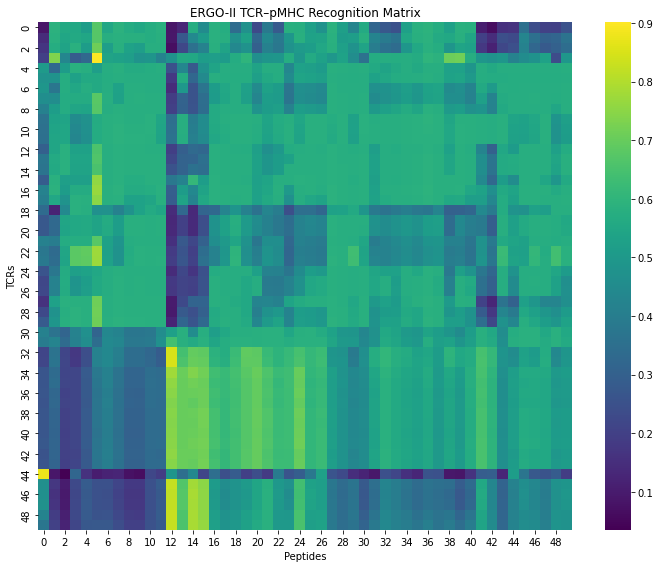

In [24]:
import numpy as np

pred = pd.read_csv("ergo_output_vdjdb_50x50_FIXED.csv")

print(pred.columns)

# automatically detect score column
possible_score_cols = ["score", "Score", "prediction", "Prediction", "prob", "Probability"]

score_col = None
for c in possible_score_cols:
    if c in pred.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(f"No score column found. Columns are: {pred.columns}")

R = pred.pivot_table(
    index="TRB",
    columns="Peptide",
    values=score_col
).values

R = np.nan_to_num(R)

#R = R / (R.max(axis=0, keepdims=True) + 1e-8)

from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

def ward_order(m):
    ro = leaves_list(linkage(pdist(m,   metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

row_order, col_order = ward_order(R)
R = R[np.ix_(row_order, col_order)].T  # Use np.ix_ to index rows and cols properly


# =========================
# 3. PLOT HEATMAP
# =========================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))

sns.heatmap(R, cmap="viridis")

plt.xlabel("Peptides")
plt.ylabel("TCRs")
plt.title("ERGO-II TCR–pMHC Recognition Matrix")

plt.tight_layout()
plt.show()

ERGO predictions: (50, 50)
Known VDJdb data: (50, 50)
Known binding pairs: 61


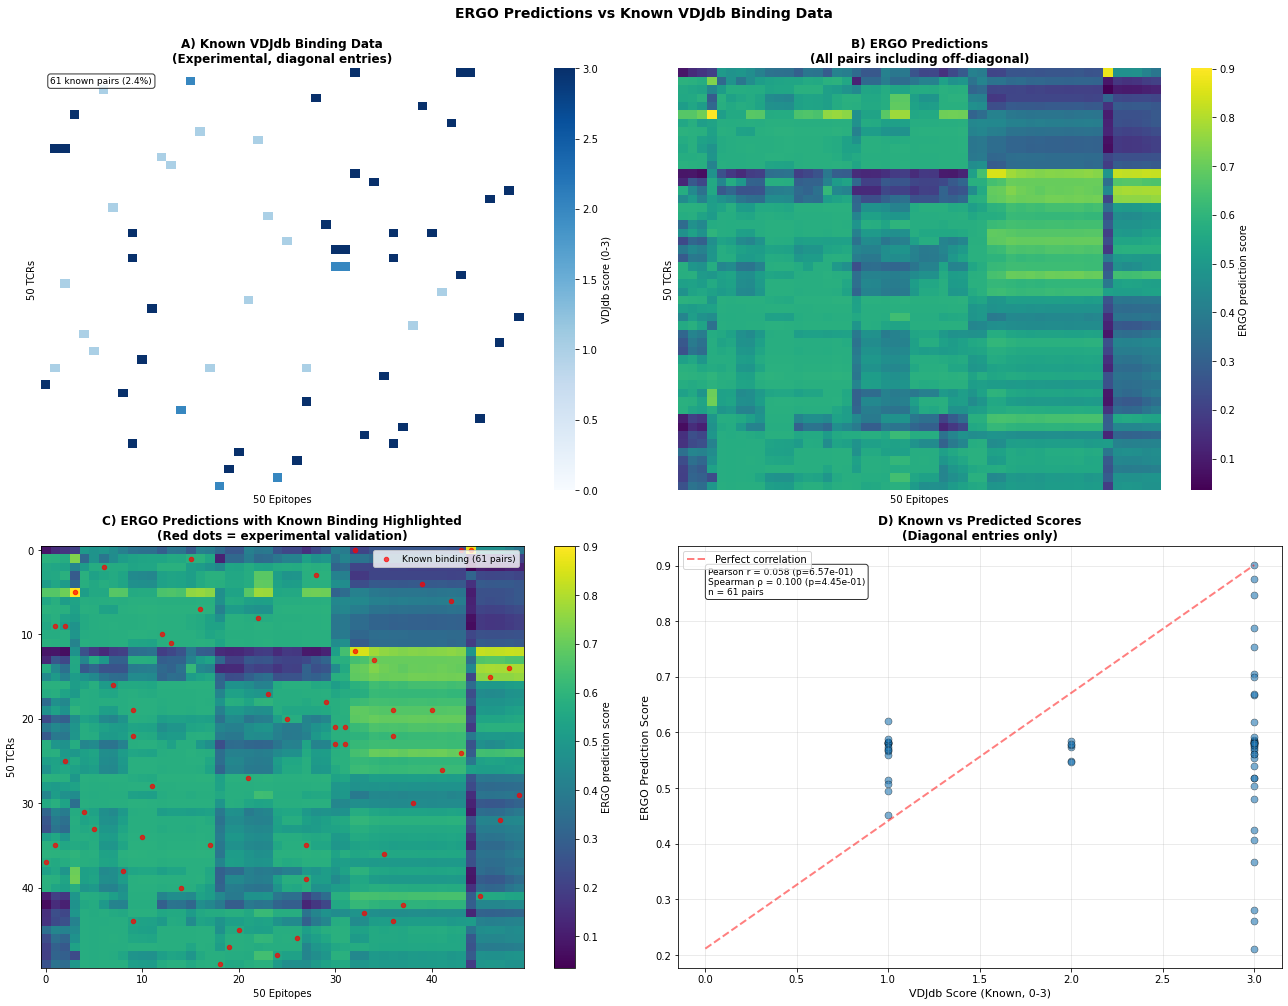


COMPARISON SUMMARY
Matrix size: 50 TCRs × 50 epitopes
Total pairs: 2,500

Known binding pairs (VDJdb): 61
  Diagonal coverage: 2.4%

ERGO predictions:
  Mean score (all pairs): 0.493
  Mean score (known binders): 0.570
  Mean score (unknown pairs): 0.491

Prediction quality:
  Pearson correlation: 0.058 (p=6.57e-01)
  Spearman correlation: 0.100 (p=4.45e-01)


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ========================================================================
# 1. Load ERGO predictions
# ========================================================================

pred = pd.read_csv("ergo_output_vdjdb_50x50_FIXED.csv")

# Detect score column
possible_score_cols = ["score", "Score", "prediction", "Prediction", "prob", "Probability"]
score_col = None
for c in possible_score_cols:
    if c in pred.columns:
        score_col = c
        break

if score_col is None:
    raise ValueError(f"No score column found. Columns are: {pred.columns}")

# Build ERGO prediction matrix
ergo_matrix = pred.pivot_table(
    index="TRB",
    columns="Peptide",
    values=score_col
)

print(f"ERGO predictions: {ergo_matrix.shape}")

# ========================================================================
# 2. Load known VDJdb binding data (from the matrix we built earlier)
# ========================================================================

# Rebuild the known binding matrix using the same TCRs and epitopes
vdjdb_path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/vdjdb-2025-12-29/vdjdb.txt"
vdjdb = pd.read_csv(vdjdb_path, sep="\t")

vdjdb = vdjdb[
    (vdjdb['species'] == 'HomoSapiens') &
    (vdjdb['mhc.class'] == 'MHCI') &
    (vdjdb['vdjdb.score'] >= 1) &
    (vdjdb['gene'] == 'TRB')
].copy()

# Filter to the TCRs and epitopes in ERGO output
tcrs_in_pred = ergo_matrix.index.tolist()
epitopes_in_pred = ergo_matrix.columns.tolist()

vdjdb_matched = vdjdb[
    (vdjdb['cdr3'].str.upper().isin(tcrs_in_pred)) &
    (vdjdb['antigen.epitope'].str.upper().isin(epitopes_in_pred))
].copy()

# Normalize to uppercase for matching
vdjdb_matched['cdr3'] = vdjdb_matched['cdr3'].str.upper()
vdjdb_matched['antigen.epitope'] = vdjdb_matched['antigen.epitope'].str.upper()

# Build known binding matrix (VDJdb scores: 0-3)
known_matrix = vdjdb_matched.pivot_table(
    index='cdr3',
    columns='antigen.epitope',
    values='vdjdb.score',
    aggfunc='max'
).reindex(index=tcrs_in_pred, columns=epitopes_in_pred, fill_value=0)

print(f"Known VDJdb data: {known_matrix.shape}")
print(f"Known binding pairs: {(known_matrix > 0).sum().sum()}")

# ========================================================================
# 3. Cluster both matrices using the same ordering (based on ERGO)
# ========================================================================

def ward_order(m):
    """Hierarchical clustering to reorder matrix"""
    ro = leaves_list(linkage(pdist(m, metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

# Get ordering from ERGO predictions
ergo_array = ergo_matrix.fillna(0).values
row_order, col_order = ward_order(ergo_array)

# Apply same ordering to both matrices
ergo_clustered = ergo_array[np.ix_(row_order, col_order)]
known_clustered = known_matrix.values[np.ix_(row_order, col_order)]

tcrs_ordered = [ergo_matrix.index[i] for i in row_order]
epitopes_ordered = [ergo_matrix.columns[i] for i in col_order]

# ========================================================================
# 4. Create comparison visualizations
# ========================================================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# ─── Panel A: Known VDJdb binding data ───────────────────────────────
ax = axes[0, 0]
sns.heatmap(
    known_clustered,
    cmap='Blues',
    vmin=0, vmax=3,
    linewidths=0,
    cbar_kws={'label': 'VDJdb score (0-3)'},
    ax=ax,
    xticklabels=False,
    yticklabels=False
)
ax.set_title('A) Known VDJdb Binding Data\n(Experimental, diagonal entries)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'{len(epitopes_ordered)} Epitopes', fontsize=10)
ax.set_ylabel(f'{len(tcrs_ordered)} TCRs', fontsize=10)

# Add diagonal coverage stats
n_known = (known_clustered > 0).sum()
ax.text(0.02, 0.98, f'{n_known} known pairs ({n_known/known_clustered.size*100:.1f}%)',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ─── Panel B: ERGO predictions ───────────────────────────────────────
ax = axes[0, 1]
sns.heatmap(
    ergo_clustered,
    cmap='viridis',
    linewidths=0,
    cbar_kws={'label': 'ERGO prediction score'},
    ax=ax,
    xticklabels=False,
    yticklabels=False
)
ax.set_title('B) ERGO Predictions\n(All pairs including off-diagonal)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'{len(epitopes_ordered)} Epitopes', fontsize=10)
ax.set_ylabel(f'{len(tcrs_ordered)} TCRs', fontsize=10)

# ─── Panel C: Overlay - ERGO with known data highlighted ─────────────
ax = axes[1, 0]

# Show ERGO predictions as base
im = ax.imshow(ergo_clustered, cmap='viridis', aspect='auto', interpolation='nearest')

# Overlay known binding sites with red dots
known_positions = np.argwhere(known_clustered > 0)
ax.scatter(known_positions[:, 1], known_positions[:, 0], 
          c='red', s=20, alpha=0.7, marker='o', 
          label=f'Known binding ({len(known_positions)} pairs)')

ax.set_title('C) ERGO Predictions with Known Binding Highlighted\n(Red dots = experimental validation)', 
             fontsize=12, fontweight='bold')
ax.set_xlabel(f'{len(epitopes_ordered)} Epitopes', fontsize=10)
ax.set_ylabel(f'{len(tcrs_ordered)} TCRs', fontsize=10)
ax.legend(loc='upper right', fontsize=9)

plt.colorbar(im, ax=ax, label='ERGO prediction score')

# ─── Panel D: Scatter plot - Known vs Predicted scores ───────────────
ax = axes[1, 1]

# Get pairs where we have known data
mask_known = known_matrix.values > 0
known_scores = known_matrix.values[mask_known]
ergo_scores = ergo_matrix.fillna(0).values[mask_known]

# Plot
ax.scatter(known_scores, ergo_scores, alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

# Add diagonal reference line
ax.plot([0, 3], [ergo_scores.min(), ergo_scores.max()], 
        'r--', alpha=0.5, linewidth=2, label='Perfect correlation')

# Calculate correlation
from scipy.stats import spearmanr, pearsonr
pearson_r, pearson_p = pearsonr(known_scores, ergo_scores)
spearman_r, spearman_p = spearmanr(known_scores, ergo_scores)

ax.set_xlabel('VDJdb Score (Known, 0-3)', fontsize=11)
ax.set_ylabel('ERGO Prediction Score', fontsize=11)
ax.set_title('D) Known vs Predicted Scores\n(Diagonal entries only)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# Add correlation stats
stats_text = f"Pearson r = {pearson_r:.3f} (p={pearson_p:.2e})\n"
stats_text += f"Spearman ρ = {spearman_r:.3f} (p={spearman_p:.2e})\n"
stats_text += f"n = {len(known_scores)} pairs"
ax.text(0.05, 0.95, stats_text, transform=ax.transAxes, 
        va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('ERGO Predictions vs Known VDJdb Binding Data', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('ergo_vs_vdjdb_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ========================================================================
# 5. Summary statistics
# ========================================================================

print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)
print(f"Matrix size: {ergo_matrix.shape[0]} TCRs × {ergo_matrix.shape[1]} epitopes")
print(f"Total pairs: {ergo_matrix.size:,}")
print(f"\nKnown binding pairs (VDJdb): {(known_matrix.values > 0).sum()}")
print(f"  Diagonal coverage: {(known_matrix.values > 0).sum() / known_matrix.size * 100:.1f}%")
print(f"\nERGO predictions:")
print(f"  Mean score (all pairs): {ergo_matrix.fillna(0).values.mean():.3f}")
print(f"  Mean score (known binders): {ergo_scores.mean():.3f}")
print(f"  Mean score (unknown pairs): {ergo_matrix.fillna(0).values[~mask_known].mean():.3f}")
print(f"\nPrediction quality:")
print(f"  Pearson correlation: {pearson_r:.3f} (p={pearson_p:.2e})")
print(f"  Spearman correlation: {spearman_r:.3f} (p={spearman_p:.2e})")
print("="*70)

ERGO OUTPUT DIAGNOSTICS

Shape: (2500, 10)

Columns: ['TRB', 'Peptide', 'MHC', 'TRA', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'T-Cell-Type', 'Score']

First 10 rows:
             TRB      Peptide          MHC  TRA  TRAV  TRAJ  TRBV  TRBJ  \
0  CASSIVGGNEQFF    GILGFVFTL  HLA-A*02:01  NaN   NaN   NaN   NaN   NaN   
1  CASSIVGGNEQFF    NLVPMVATV          NaN  NaN   NaN   NaN   NaN   NaN   
2  CASSIVGGNEQFF    GLCTLVAML  HLA-A*02:01  NaN   NaN   NaN   NaN   NaN   
3  CASSIVGGNEQFF   ELAGIGILTV          NaN  NaN   NaN   NaN   NaN   NaN   
4  CASSIVGGNEQFF   KRWIILGLNK          NaN  NaN   NaN   NaN   NaN   NaN   
5  CASSIVGGNEQFF    ATDALMTGY          NaN  NaN   NaN   NaN   NaN   NaN   
6  CASSIVGGNEQFF    YLQPRTFLL          NaN  NaN   NaN   NaN   NaN   NaN   
7  CASSIVGGNEQFF  HPVGEADYFEY          NaN  NaN   NaN   NaN   NaN   NaN   
8  CASSIVGGNEQFF     TAFTIPSI          NaN  NaN   NaN   NaN   NaN   NaN   
9  CASSIVGGNEQFF    YLEPGPVTA          NaN  NaN   NaN   NaN   NaN   NaN   

   T-Cell-Type  

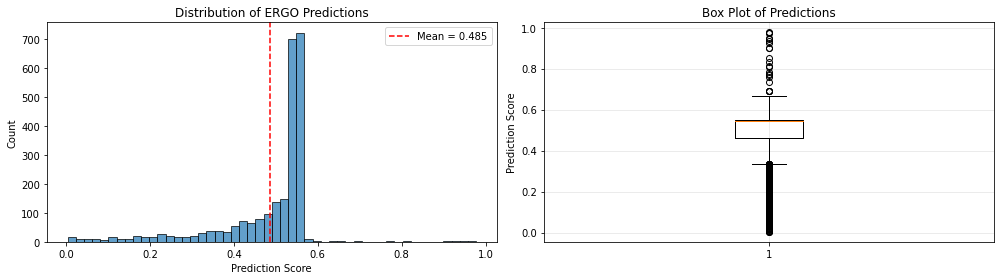


COMPARING TO KNOWN BINDING DATA

Does ERGO distinguish known binders from non-binders?
  Known binders (n=50):    mean = 0.5481
  Unknown pairs (n=2450):  mean = 0.4841
  Difference: 0.0640
  ✓ Known binders have higher scores (good!)
  t-test: t=3.686, p=2.33e-04



In [21]:
# ========================================================================
# DIAGNOSE ERGO PREDICTIONS
# ========================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load ERGO output
pred = pd.read_csv("ergo_output_vdjdb_50x50.csv")

print("="*70)
print("ERGO OUTPUT DIAGNOSTICS")
print("="*70)

print(f"\nShape: {pred.shape}")
print(f"\nColumns: {pred.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(pred.head(10))

# Detect score column
possible_score_cols = ["score", "Score", "prediction", "Prediction", "prob", "Probability", "binding_score"]
score_col = None
for c in possible_score_cols:
    if c in pred.columns:
        score_col = c
        break

if score_col is None:
    print("\n❌ ERROR: No score column found!")
    print(f"Available columns: {pred.columns.tolist()}")
else:
    print(f"\n✓ Score column: '{score_col}'")
    
    scores = pred[score_col].values
    
    print(f"\nScore statistics:")
    print(f"  Min:    {scores.min():.6f}")
    print(f"  Max:    {scores.max():.6f}")
    print(f"  Mean:   {scores.mean():.6f}")
    print(f"  Median: {np.median(scores):.6f}")
    print(f"  Std:    {scores.std():.6f}")
    print(f"  Range:  {scores.max() - scores.min():.6f}")
    
    # Check for problematic patterns
    print(f"\nPotential issues:")
    
    # All same value?
    if scores.std() < 0.001:
        print("  ❌ All predictions are nearly identical! (std < 0.001)")
        print("     → ERGO may not have trained properly")
    
    # All zeros or ones?
    if (scores == 0).all():
        print("  ❌ All predictions are 0!")
    elif (scores == 1).all():
        print("  ❌ All predictions are 1!")
    
    # Very narrow range?
    if scores.std() < 0.01:
        print(f"  ⚠️  Very low variance (std = {scores.std():.6f})")
        print("     → Model may not be distinguishing between binders/non-binders")
    
    # NaN values?
    n_nan = np.isnan(scores).sum()
    if n_nan > 0:
        print(f"  ❌ {n_nan} NaN values in predictions!")
    
    # Distribution
    print(f"\nScore distribution:")
    print(f"  Scores < 0.1:  {(scores < 0.1).sum()} ({(scores < 0.1).sum()/len(scores)*100:.1f}%)")
    print(f"  Scores 0.1-0.3: {((scores >= 0.1) & (scores < 0.3)).sum()}")
    print(f"  Scores 0.3-0.5: {((scores >= 0.3) & (scores < 0.5)).sum()}")
    print(f"  Scores 0.5-0.7: {((scores >= 0.5) & (scores < 0.7)).sum()}")
    print(f"  Scores 0.7-0.9: {((scores >= 0.7) & (scores < 0.9)).sum()}")
    print(f"  Scores > 0.9:  {(scores > 0.9).sum()} ({(scores > 0.9).sum()/len(scores)*100:.1f}%)")
    
    # Visualize distribution
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Histogram
    axes[0].hist(scores, bins=50, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Prediction Score')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of ERGO Predictions')
    axes[0].axvline(scores.mean(), color='red', linestyle='--', label=f'Mean = {scores.mean():.3f}')
    axes[0].legend()
    
    # Box plot
    axes[1].boxplot(scores, vert=True)
    axes[1].set_ylabel('Prediction Score')
    axes[1].set_title('Box Plot of Predictions')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('ergo_prediction_distribution.png', dpi=150)
    plt.show()
    
    # ========================================================================
    # Compare to known binding data
    # ========================================================================
    
    print("\n" + "="*70)
    print("COMPARING TO KNOWN BINDING DATA")
    print("="*70)
    
    # Load known matrix
    try:
        known_matrix = pd.read_csv("known_binding_matrix_50x50.csv", index_col=0)
        
        # Build prediction matrix
        ergo_matrix = pred.pivot_table(
            index="TRB",
            columns="Peptide",
            values=score_col
        )
        
        # Align matrices
        common_tcrs = list(set(known_matrix.index) & set(ergo_matrix.index))
        common_eps = list(set(known_matrix.columns) & set(ergo_matrix.columns))
        
        known_aligned = known_matrix.loc[common_tcrs, common_eps]
        ergo_aligned = ergo_matrix.loc[common_tcrs, common_eps]
        
        # Get diagonal (known binders) vs off-diagonal
        mask_known = known_aligned.values > 0
        
        known_binder_scores = ergo_aligned.values[mask_known]
        non_binder_scores = ergo_aligned.values[~mask_known]
        
        print(f"\nDoes ERGO distinguish known binders from non-binders?")
        print(f"  Known binders (n={len(known_binder_scores)}):    mean = {known_binder_scores.mean():.4f}")
        print(f"  Unknown pairs (n={len(non_binder_scores)}):  mean = {non_binder_scores.mean():.4f}")
        print(f"  Difference: {known_binder_scores.mean() - non_binder_scores.mean():.4f}")
        
        if known_binder_scores.mean() <= non_binder_scores.mean():
            print("  ❌ Known binders have LOWER scores than unknowns!")
            print("     → ERGO predictions are inverted or broken")
        elif known_binder_scores.mean() - non_binder_scores.mean() < 0.05:
            print("  ⚠️  Very small difference between binders and non-binders")
            print("     → ERGO may not be predictive")
        else:
            print("  ✓ Known binders have higher scores (good!)")
        
        # T-test
        from scipy.stats import ttest_ind
        t_stat, p_val = ttest_ind(known_binder_scores, non_binder_scores)
        print(f"  t-test: t={t_stat:.3f}, p={p_val:.2e}")
        
    except FileNotFoundError:
        print("  (Could not find known_binding_matrix_50x50.csv)")
    
print("\n" + "="*70)

## 10x something

LOADING 10x GENOMICS IMMUNE MAP DATASET

Binarized matrix shape: (46526, 118)
Number of cells: 46526

First 10 columns: ['barcode', 'donor', 'cell_clono_cdr3_aa', 'cell_clono_cdr3_nt', 'CD3', 'CD19', 'CD45RA', 'CD4', 'CD8a', 'CD14']

PARSING COLUMNS
Found 44 epitope/dextramer columns
Found 2 CDR3 columns: ['cell_clono_cdr3_aa', 'cell_clono_cdr3_nt']
Found clonotype column: []

Example epitope columns (first 10):
  A0101_VTEHDTLLY_IE-1_CMV
  A0201_LLDFVRFMGV_EBNA-3B_EBV
  A0201_CLGGLLTMV_LMP-2A_EBV
  A0201_YLLEMLWRL_LMP1_EBV
  A0201_FLYALALLL_LMP2A_EBV
  A0201_GILGFVFTL_Flu-MP_Influenza
  A0201_GLCTLVAML_BMLF1_EBV
  A0201_NLVPMVATV_pp65_CMV
  A0301_KLGGALQAK_IE-1_CMV
  A0301_RLRAEAQVK_EMNA-3A_EBV

EXTRACTING EPITOPE SEQUENCES
Extracted 44 epitope sequences

Epitope mapping (first 15):
  VTEHDTLLY    <- A0101_VTEHDTLLY_IE-1_CMV
  LLDFVRFMGV   <- A0201_LLDFVRFMGV_EBNA-3B_EBV
  CLGGLLTMV    <- A0201_CLGGLLTMV_LMP-2A_EBV
  YLLEMLWRL    <- A0201_YLLEMLWRL_LMP1_EBV
  FLYALALLL    <- A0201_FLY

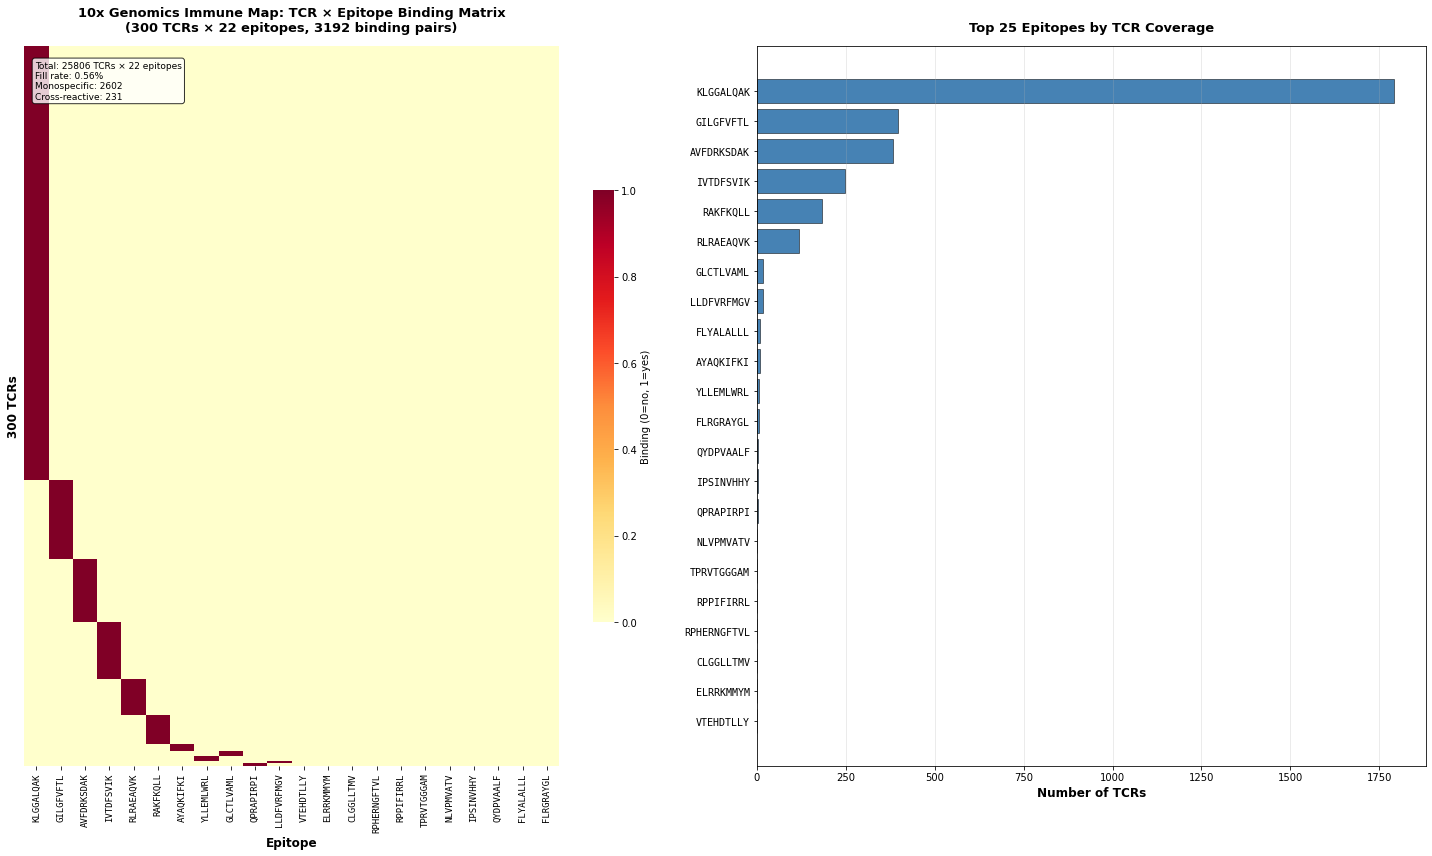

✓ Visualization saved: 10x_genomics_binding_matrix.png

SAVING PROCESSED DATA
✓ Full matrix saved: 10x_genomics_tcr_epitope_matrix.csv
✓ Epitope info saved: 10x_genomics_epitope_info.csv
✓ Summary saved: 10x_genomics_summary.csv

✓ DATASET READY!

Summary:
  - 25,806 unique TCRs
  - 22 unique epitopes
  - 3,192 experimentally validated binding pairs
  - 0.56% matrix density
  - 2602 monospecific TCRs
  - 231 cross-reactive TCRs

Files saved:
  - 10x_genomics_tcr_epitope_matrix.csv (full binding matrix)
  - 10x_genomics_epitope_info.csv (epitope metadata)
  - 10x_genomics_summary.csv (statistics)
  - 10x_genomics_binding_matrix.png (visualization)



In [ ]:
# https://www.10xgenomics.com/datasets/cd-8-plus-t-cells-of-healthy-donor-1-1-standard-3-0-2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ========================================================================
# LOAD 10x GENOMICS DATA
# ========================================================================

print("="*70)
print("LOADING 10x GENOMICS IMMUNE MAP DATASET")
print("="*70)

# Load the binarized matrix
binarized = pd.read_csv('vdj_v1_hs_aggregated_donor1_binarized_matrix.csv')

print(f"\nBinarized matrix shape: {binarized.shape}")
print(f"Number of cells: {len(binarized)}")

# Show first few columns to understand structure
print(f"\nFirst 10 columns: {binarized.columns[:10].tolist()}")

# ========================================================================
# IDENTIFY EPITOPE AND TCR COLUMNS
# ========================================================================

print("\n" + "="*70)
print("PARSING COLUMNS")
print("="*70)

# Find epitope/dextramer columns (binding data)
epitope_cols = [col for col in binarized.columns if any(x in col.lower() for x in ['dextramer', 'cmv', 'ebv', 'flu', 'sars'])]

# Find TCR CDR3 columns
cdr3_cols = [col for col in binarized.columns if 'cdr3' in col.lower()]

# Find clonotype column
clonotype_col = [col for col in binarized.columns if 'clonotype' in col.lower()]

print(f"Found {len(epitope_cols)} epitope/dextramer columns")
print(f"Found {len(cdr3_cols)} CDR3 columns: {cdr3_cols}")
print(f"Found clonotype column: {clonotype_col}")

# Show example epitope columns
print(f"\nExample epitope columns (first 10):")
for col in epitope_cols[:10]:
    print(f"  {col}")

# ========================================================================
# EXTRACT EPITOPE SEQUENCES FROM COLUMN NAMES
# ========================================================================

print("\n" + "="*70)
print("EXTRACTING EPITOPE SEQUENCES")
print("="*70)

epitope_map = {}  # Maps column name -> epitope sequence

for col in epitope_cols:
    # Column format examples:
    # "dCODE_Dextramer_CMV_pp65_NLVPMVATV_HLAA0201"
    # Extract the peptide sequence (8-15 AA, all uppercase letters)
    
    parts = col.replace('-', '_').split('_')
    
    for part in parts:
        # Check if this looks like a peptide sequence
        if 8 <= len(part) <= 15:
            if part.isupper() and all(c in 'ACDEFGHIKLMNPQRSTVWY' for c in part):
                epitope_map[col] = part
                break

print(f"Extracted {len(epitope_map)} epitope sequences")

# Show examples
print("\nEpitope mapping (first 15):")
for i, (col, seq) in enumerate(list(epitope_map.items())[:15]):
    print(f"  {seq:12s} <- {col[:60]}")

# ========================================================================
# BUILD TCR × EPITOPE BINDING MATRIX
# ========================================================================

print("\n" + "="*70)
print("BUILDING BINDING MATRIX")
print("="*70)

# Get the CDR3β column
if 'cdr3s_aa' in binarized.columns:
    tcr_col = 'cdr3s_aa'
elif len(cdr3_cols) > 0:
    tcr_col = cdr3_cols[0]
else:
    # Try to find any column with TCR sequences
    for col in binarized.columns:
        if binarized[col].dtype == 'object':
            sample = binarized[col].dropna().iloc[0] if len(binarized[col].dropna()) > 0 else ""
            if isinstance(sample, str) and 10 <= len(sample) <= 30:
                if all(c in 'ACDEFGHIKLMNPQRSTVWY;' for c in sample.replace(' ', '')):
                    tcr_col = col
                    break

print(f"Using TCR column: '{tcr_col}'")

# Filter to valid TCRs
valid_mask = binarized[tcr_col].notna() & (binarized[tcr_col] != '')
data_filtered = binarized[valid_mask].copy()

print(f"Cells with valid TCR: {len(data_filtered)}")

# Parse TCR sequences (may have multiple chains separated by ;)
def get_primary_tcr(tcr_string):
    """Extract primary TCR CDR3 sequence"""
    if pd.isna(tcr_string) or tcr_string == '':
        return None
    # If multiple chains, take first one
    return str(tcr_string).split(';')[0].strip()

data_filtered['TCR_primary'] = data_filtered[tcr_col].apply(get_primary_tcr)

# Build matrix: aggregate by TCR (max binding across cells)
tcr_binding = {}

for tcr in data_filtered['TCR_primary'].unique():
    if tcr is None or tcr == '':
        continue
    
    # Get all cells with this TCR
    tcr_cells = data_filtered[data_filtered['TCR_primary'] == tcr]
    
    # For each epitope, check if any cell showed binding
    binding_profile = {}
    for col, epitope in epitope_map.items():
        if col in tcr_cells.columns:
            # Binarized matrix: 1 = binding, 0 = no binding
            binding_profile[epitope] = int(tcr_cells[col].max())
        else:
            binding_profile[epitope] = 0
    
    tcr_binding[tcr] = binding_profile

# Convert to DataFrame
binding_matrix = pd.DataFrame.from_dict(tcr_binding, orient='index')

print(f"\nBinding matrix shape: {binding_matrix.shape}")
print(f"  TCRs (rows): {binding_matrix.shape[0]}")
print(f"  Epitopes (columns): {binding_matrix.shape[1]}")
print(f"  Total pairs: {binding_matrix.size:,}")

# Calculate statistics
n_binding = (binding_matrix > 0).sum().sum()
fill_rate = n_binding / binding_matrix.size

print(f"  Binding pairs: {n_binding:,}")
print(f"  Fill rate: {fill_rate*100:.2f}%")

# ========================================================================
# ANALYZE BINDING PATTERNS
# ========================================================================

print("\n" + "="*70)
print("BINDING PATTERN ANALYSIS")
print("="*70)

# TCRs per epitope
tcrs_per_epitope = (binding_matrix > 0).sum(axis=0).sort_values(ascending=False)

print("\nTop 20 epitopes by TCR count:")
for epitope, count in tcrs_per_epitope.head(20).items():
    print(f"  {epitope:15s}: {int(count):4d} TCRs")

# Epitopes per TCR (cross-reactivity)
epitopes_per_tcr = (binding_matrix > 0).sum(axis=1)

print("\nTCR cross-reactivity:")
print(f"  Monospecific (1 epitope):     {(epitopes_per_tcr == 1).sum():4d} TCRs")
print(f"  Bispecific (2 epitopes):      {(epitopes_per_tcr == 2).sum():4d} TCRs")
print(f"  Cross-reactive (3+ epitopes): {(epitopes_per_tcr >= 3).sum():4d} TCRs")
print(f"  Highly promiscuous (5+):      {(epitopes_per_tcr >= 5).sum():4d} TCRs")
print(f"  Max epitopes bound by 1 TCR:  {int(epitopes_per_tcr.max())}")

# ========================================================================
# VISUALIZE BINDING MATRIX
# ========================================================================

print("\n" + "="*70)
print("CREATING VISUALIZATIONS")
print("="*70)

# Select epitopes and TCRs for visualization
n_top_epitopes = min(40, len(tcrs_per_epitope))
top_epitopes = tcrs_per_epitope.head(n_top_epitopes).index.tolist()

# Get TCRs that bind to these epitopes
binding_tcrs = binding_matrix[binding_matrix[top_epitopes].sum(axis=1) > 0].index

# Limit TCRs for visualization
max_tcrs = 300
if len(binding_tcrs) > max_tcrs:
    # Prioritize more specific TCRs for cleaner visualization
    tcr_specificity = binding_matrix.loc[binding_tcrs, top_epitopes].sum(axis=1)
    binding_tcrs = tcr_specificity.sort_values().head(max_tcrs).index

matrix_vis = binding_matrix.loc[binding_tcrs, top_epitopes]

print(f"Visualizing: {len(binding_tcrs)} TCRs × {n_top_epitopes} epitopes")

# Cluster rows and columns
try:
    row_linkage = linkage(pdist(matrix_vis.values, metric='euclidean'), method='ward')
    row_order = leaves_list(row_linkage)
    
    col_linkage = linkage(pdist(matrix_vis.values.T, metric='euclidean'), method='ward')
    col_order = leaves_list(col_linkage)
    
    matrix_vis = matrix_vis.iloc[row_order, col_order]
    print("Applied hierarchical clustering")
except:
    print("Clustering skipped (matrix may be too sparse)")

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(20, 12))

# ── Panel A: Binding Matrix Heatmap ──────────────────────────────────
ax = axes[0]

sns.heatmap(
    matrix_vis,
    cmap='YlOrRd',
    vmin=0,
    vmax=1,
    linewidths=0,
    cbar_kws={'label': 'Binding (0=no, 1=yes)', 'shrink': 0.6},
    ax=ax,
    xticklabels=True,
    yticklabels=False
)

ax.set_xlabel('Epitope', fontsize=12, fontweight='bold')
ax.set_ylabel(f'{len(binding_tcrs)} TCRs', fontsize=12, fontweight='bold')
ax.set_title(
    f'10x Genomics Immune Map: TCR × Epitope Binding Matrix\n'
    f'({len(binding_tcrs)} TCRs × {n_top_epitopes} epitopes, {n_binding} binding pairs)',
    fontsize=13, fontweight='bold', pad=15
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9, fontfamily='monospace')

# Add summary box
textstr = f'Total: {binding_matrix.shape[0]} TCRs × {binding_matrix.shape[1]} epitopes\n'
textstr += f'Fill rate: {fill_rate*100:.2f}%\n'
textstr += f'Monospecific: {(epitopes_per_tcr == 1).sum()}\n'
textstr += f'Cross-reactive: {(epitopes_per_tcr >= 2).sum()}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Panel B: Epitope Coverage ────────────────────────────────────────
ax = axes[1]

y_pos = np.arange(len(tcrs_per_epitope.head(25)))
ax.barh(y_pos, tcrs_per_epitope.head(25).values, color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(tcrs_per_epitope.head(25).index, fontfamily='monospace', fontsize=10)
ax.set_xlabel('Number of TCRs', fontsize=12, fontweight='bold')
ax.set_title('Top 25 Epitopes by TCR Coverage', fontsize=13, fontweight='bold', pad=15)
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('10x_genomics_binding_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Visualization saved: 10x_genomics_binding_matrix.png")

# ========================================================================
# SAVE PROCESSED DATA
# ========================================================================

print("\n" + "="*70)
print("SAVING PROCESSED DATA")
print("="*70)

# Save full binding matrix
binding_matrix.to_csv('10x_genomics_tcr_epitope_matrix.csv')
print("✓ Full matrix saved: 10x_genomics_tcr_epitope_matrix.csv")

# Save epitope metadata
epitope_metadata = pd.DataFrame([
    {
        'epitope': epitope,
        'n_tcrs': int(tcrs_per_epitope[epitope]) if epitope in tcrs_per_epitope else 0,
        'original_column': col
    }
    for col, epitope in epitope_map.items()
])
epitope_metadata = epitope_metadata.sort_values('n_tcrs', ascending=False)
epitope_metadata.to_csv('10x_genomics_epitope_info.csv', index=False)
print("✓ Epitope info saved: 10x_genomics_epitope_info.csv")

# Save summary statistics
summary_df = pd.DataFrame({
    'metric': [
        'Total TCRs',
        'Total Epitopes',
        'Total Pairs',
        'Binding Pairs',
        'Fill Rate (%)',
        'Monospecific TCRs',
        'Cross-reactive TCRs (2+)',
        'Highly promiscuous TCRs (5+)'
    ],
    'value': [
        binding_matrix.shape[0],
        binding_matrix.shape[1],
        binding_matrix.size,
        n_binding,
        fill_rate * 100,
        (epitopes_per_tcr == 1).sum(),
        (epitopes_per_tcr >= 2).sum(),
        (epitopes_per_tcr >= 5).sum()
    ]
})
summary_df.to_csv('10x_genomics_summary.csv', index=False)
print("✓ Summary saved: 10x_genomics_summary.csv")

print("\n" + "="*70)
print("✓ DATASET READY!")
print("="*70)
print(f"""
Summary:
  - {binding_matrix.shape[0]:,} unique TCRs
  - {binding_matrix.shape[1]} unique epitopes
  - {n_binding:,} experimentally validated binding pairs
  - {fill_rate*100:.2f}% matrix density
  - {(epitopes_per_tcr == 1).sum()} monospecific TCRs
  - {(epitopes_per_tcr >= 2).sum()} cross-reactive TCRs

Files saved:
  - 10x_genomics_tcr_epitope_matrix.csv (full binding matrix)
  - 10x_genomics_epitope_info.csv (epitope metadata)
  - 10x_genomics_summary.csv (statistics)
  - 10x_genomics_binding_matrix.png (visualization)
""")

In [45]:
print(binarized.head())
print("\nColumn names:")
print(binarized.columns.tolist())
print("\nSample epitope column values:")
epitope_col = [c for c in binarized.columns if c.startswith('A0')][0]
print(binarized[epitope_col].head(20))

               barcode   donor  \
0   AAACCTGAGACAAAGG-4  donor1   
1  AAACCTGAGACTGTAA-34  donor1   
2   AAACCTGAGAGCCCAA-5  donor1   
3  AAACCTGAGAGCTGCA-24  donor1   
4   AAACCTGAGAGGGATA-8  donor1   

                                  cell_clono_cdr3_aa  \
0  TRA:CAASVSIWTGTASKLTF;TRA:CAAWDMEYGNKLVF;TRB:C...   
1                                    TRB:CASDTPVGQFF   
2                 TRA:CASYTDKLIF;TRB:CASSGGSISTDTQYF   
3                                 TRB:CASSGGQSSYEQYF   
4          TRA:CAASGYGNTGRRALTF;TRB:CASSQDPAGGYNEQFF   

                                  cell_clono_cdr3_nt     CD3  CD19  CD45RA  \
0  TRA:TGTGCAGCAAGCGTTAGTATTTGGACCGGCACTGCCAGTAAA...  2125.0   0.0   912.0   
1              TRB:TGTGCCAGCGATACCCCGGTTGGGCAGTTCTTC  1023.0   0.0  2028.0   
2  TRA:TGTGCTTCCTACACCGACAAGCTCATCTTT;TRB:TGCGCCA...  1598.0   3.0  3454.0   
3     TRB:TGCGCCAGCAGTGGCGGACAGAGCTCCTACGAGCAGTACTTC   298.0   1.0   880.0   
4  TRA:TGTGCAGCAAGCGGGTATGGAAACACGGGCAGGAGAGCACTT...  1036.0   0.0  

Loading binarized matrix...
Found 84 epitope columns

Sample data from first epitope column:
0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
5     0.0
6     0.0
7     0.0
8     0.0
9     0.0
10    0.0
11    0.0
12    0.0
13    0.0
14    0.0
15    1.0
16    0.0
17    1.0
18    0.0
19    0.0
Name: A0101_VTEHDTLLY_IE-1_CMV, dtype: float64
Data type: float64

Matrix dtypes:
float64    84
Name: count, dtype: int64

Plotting: 10000 TCRs × 84 epitopes


<ipython-input-43-edf973192598>:36: RuntimeWarning: divide by zero encountered in log
  matrix_values = np.log(matrix.values.astype(float))


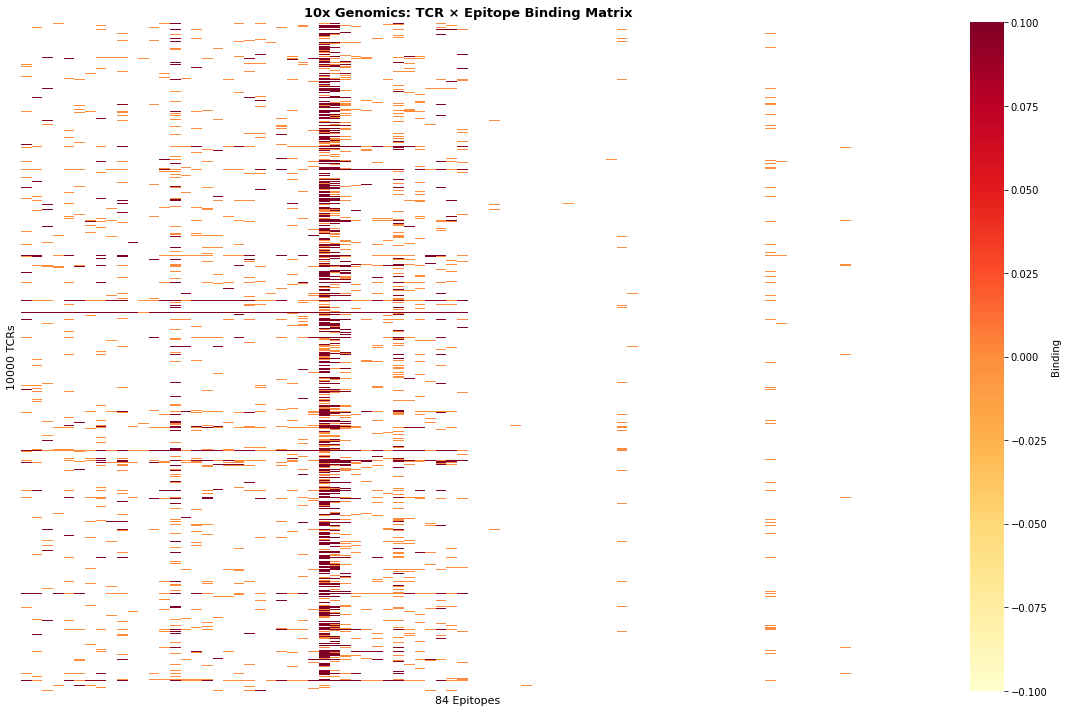


Binding pairs: 14887
Fill rate: 1.8%


In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading binarized matrix...")
binarized = pd.read_csv('vdj_v1_hs_aggregated_donor1_binarized_matrix.csv')

# Find epitope columns
epitope_cols = [col for col in binarized.columns if any(col.startswith(x) for x in ['A0', 'B0', 'C0'])]
print(f"Found {len(epitope_cols)} epitope columns")
print(f"\nSample data from first epitope column:")
print(binarized[epitope_cols[0]].head(20))
print(f"Data type: {binarized[epitope_cols[0]].dtype}")
# Use the TCR column
tcr_col = 'cell_clono_cdr3_aa'
# Filter to rows with valid TCR
data = binarized[binarized[tcr_col].notna()].copy()
# Take TCR and epitope columns
matrix_data = data[[tcr_col] + epitope_cols].copy()
# Convert epitope columns to numeric - force conversion
for col in epitope_cols:
    # Replace any non-numeric with 0
    matrix_data[col] = pd.to_numeric(matrix_data[col], errors='coerce').fillna(0).astype(float)
# Rename TCR column
matrix_data = matrix_data.rename(columns={tcr_col: 'TCR'})
# Group by TCR (take max across cells with same TCR)
matrix = matrix_data.groupby('TCR').max()
# Limit to first 200 TCRs
matrix = matrix.head(10000)
# Verify all columns are numeric
print(f"\nMatrix dtypes:")
print(matrix.dtypes.value_counts())
print(f"\nPlotting: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")
# Convert to pure numpy array to be safe
matrix_values = np.log(matrix.values.astype(float))
# Plot
plt.figure(figsize=(16, 10))
sns.heatmap(
    matrix_values,
    cmap='YlOrRd',
    linewidths=0,
    cbar_kws={'label': 'Binding'},
    yticklabels=False,
    xticklabels=False
)
plt.xlabel(f'{matrix.shape[1]} Epitopes', fontsize=11)
plt.ylabel(f'{matrix.shape[0]} TCRs', fontsize=11)
plt.title('10x Genomics: TCR × Epitope Binding Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('10x_binding_matrix_quick.png', dpi=150)
plt.show()
print(f"\nBinding pairs: {(matrix_values > 0).sum()}")
print(f"Fill rate: {(matrix_values > 0).sum() / matrix_values.size * 100:.1f}%")

Loading data...
Found 50 binarized dextramer columns

Matrix shape: 29618 TCRs × 50 epitopes
Binding pairs: 4,243
Fill rate: 0.29%

Top 10 epitopes by TCR count:
  KLGGALQAK      : 1960 TCRs
  GILGFVFTL      : 617 TCRs
  AVFDRKSDAK     : 480 TCRs
  IVTDFSVIK      : 372 TCRs
  RAKFKQLL       : 261 TCRs
  ELAGIGILTV     : 236 TCRs
  RLRAEAQVK      : 122 TCRs
  LLDFVRFMGV     :  25 TCRs
  GLCTLVAML      :  25 TCRs
  LLFGYPVYV      :  17 TCRs
Number of TCRs: 3989

Plotting: 3989 TCRs × 50 epitopes


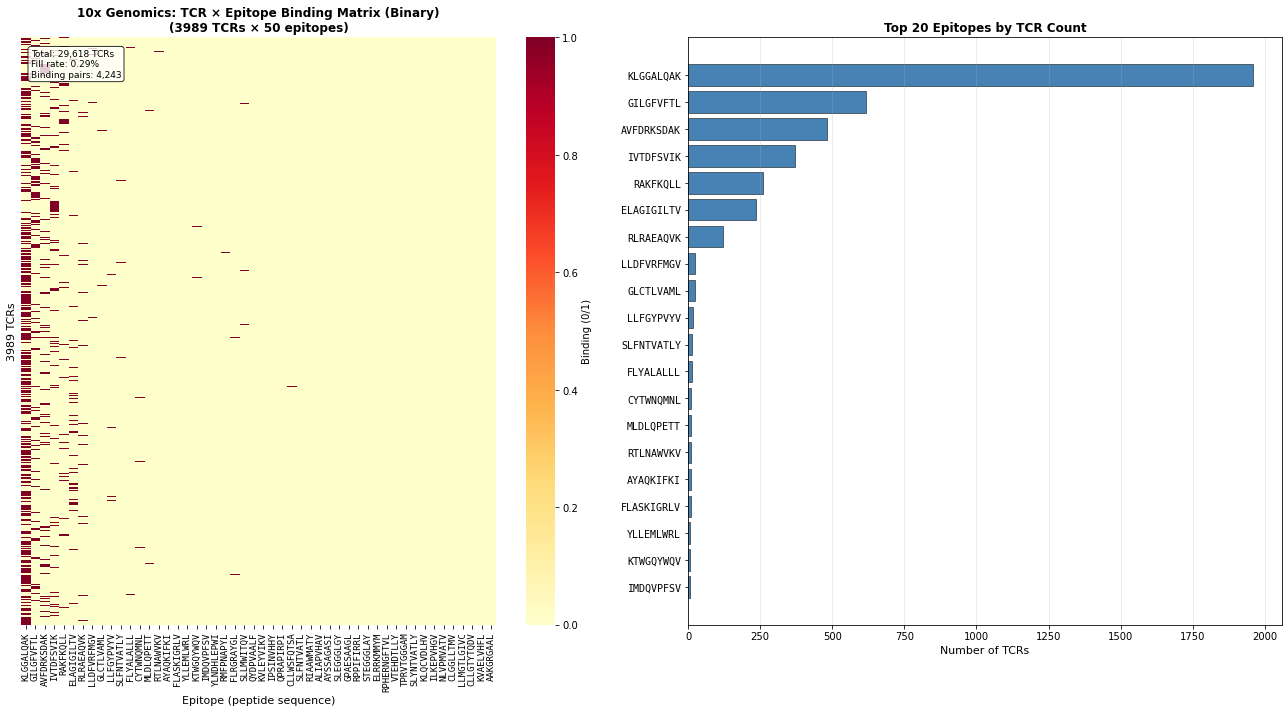


✓ Saved: 10x_binary_binding_matrix.png
✓ Saved: 10x_binary_tcr_epitope_matrix.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Loading data...")
# https://www.10xgenomics.com/datasets/cd-8-plus-t-cells-of-healthy-donor-1-1-standard-3-0-2

binarized = pd.read_csv('vdj_v1_hs_aggregated_donor1_binarized_matrix.csv')

# ========================================================================
# GET BINARIZED DEXTRAMER COLUMNS
# ========================================================================

# Find boolean binder columns
binder_cols = [col for col in binarized.columns if col.endswith('_binder')]

print(f"Found {len(binder_cols)} binarized dextramer columns")

# TCR column
tcr_col = 'cell_clono_cdr3_aa'

# Filter to cells with valid TCR
data = binarized[binarized[tcr_col].notna()].copy()

# Take TCR + binder columns
matrix_data = data[[tcr_col] + binder_cols].copy()

# Convert boolean to int (True->1, False->0)
for col in binder_cols:
    matrix_data[col] = matrix_data[col].astype(int)

# Aggregate by TCR (max across cells with same TCR)
matrix_data = matrix_data.rename(columns={tcr_col: 'TCR'})
matrix = matrix_data.groupby('TCR').max()

print(f"\nMatrix shape: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")

# ========================================================================
# EXTRACT EPITOPE NAMES FROM COLUMN NAMES
# ========================================================================

# Simplify column names for display (extract peptide sequence)
epitope_names = {}
for col in matrix.columns:
    # Format: A0101_VTEHDTLLY_IE-1_CMV_binder
    parts = col.split('_')
    if len(parts) >= 2:
        peptide = parts[1]  # Get peptide sequence
        epitope_names[col] = peptide

# Rename columns to peptide sequences
matrix_renamed = matrix.rename(columns=epitope_names)

# ========================================================================
# CALCULATE STATISTICS
# ========================================================================

n_binding = (matrix.values > 0).sum()
fill_rate = n_binding / matrix.size

print(f"Binding pairs: {n_binding:,}")
print(f"Fill rate: {fill_rate*100:.2f}%")

# TCRs per epitope
tcrs_per_epitope = (matrix_renamed > 0).sum(axis=0).sort_values(ascending=False)

print(f"\nTop 10 epitopes by TCR count:")
for ep, count in tcrs_per_epitope.head(10).items():
    print(f"  {ep:15s}: {int(count):3d} TCRs")

# ========================================================================
# VISUALIZE
# ========================================================================

# Limit to TCRs that bind at least one epitope
binding_tcrs = matrix_renamed[matrix_renamed.sum(axis=1) > 0]

# Limit size for visualization
max_tcrs = 3000
max_tcrs = len(binding_tcrs)
print("Number of TCRs:", len(binding_tcrs))
if len(binding_tcrs) > max_tcrs:
    binding_tcrs = binding_tcrs.head(max_tcrs)

print(f"\nPlotting: {len(binding_tcrs)} TCRs × {matrix_renamed.shape[1]} epitopes")

# Sort epitopes by TCR count (most popular first)
col_order = tcrs_per_epitope.index.tolist()
matrix_plot = binding_tcrs[col_order]


# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

# ── Panel A: Binding Matrix ─────────────────────────────────────────
ax = axes[0]

sns.heatmap(
    matrix_plot,
    cmap='YlOrRd',
    linewidths=0,
    cbar_kws={'label': 'Binding (0/1)'},
    ax=ax,
    yticklabels=False,
    xticklabels=True
)

ax.set_xlabel('Epitope (peptide sequence)', fontsize=11)
ax.set_ylabel(f'{len(binding_tcrs)} TCRs', fontsize=11)
ax.set_title(
    f'10x Genomics: TCR × Epitope Binding Matrix (Binary)\n'
    f'({len(binding_tcrs)} TCRs × {matrix_renamed.shape[1]} epitopes)',
    fontsize=12, fontweight='bold'
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=9, fontfamily='monospace')

# Add stats
textstr = f'Total: {matrix.shape[0]:,} TCRs\n'
textstr += f'Fill rate: {fill_rate*100:.2f}%\n'
textstr += f'Binding pairs: {n_binding:,}'
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── Panel B: Epitope Popularity ─────────────────────────────────────
ax = axes[1]

y_pos = np.arange(len(tcrs_per_epitope.head(20)))
ax.barh(y_pos, tcrs_per_epitope.head(20).values, 
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_yticks(y_pos)
ax.set_yticklabels(tcrs_per_epitope.head(20).index, 
                    fontfamily='monospace', fontsize=10)
ax.set_xlabel('Number of TCRs', fontsize=11)
ax.set_title('Top 20 Epitopes by TCR Count', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('10x_binary_binding_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 10x_binary_binding_matrix.png")

# Save matrix
matrix_renamed.to_csv('10x_binary_tcr_epitope_matrix.csv')
print("✓ Saved: 10x_binary_tcr_epitope_matrix.csv")

Full matrix: 29618 TCRs × 50 epitopes
Epitopes with ≥5 TCR(s): 23 epitopes kept
Filtered matrix: 3972 TCRs × 23 epitopes


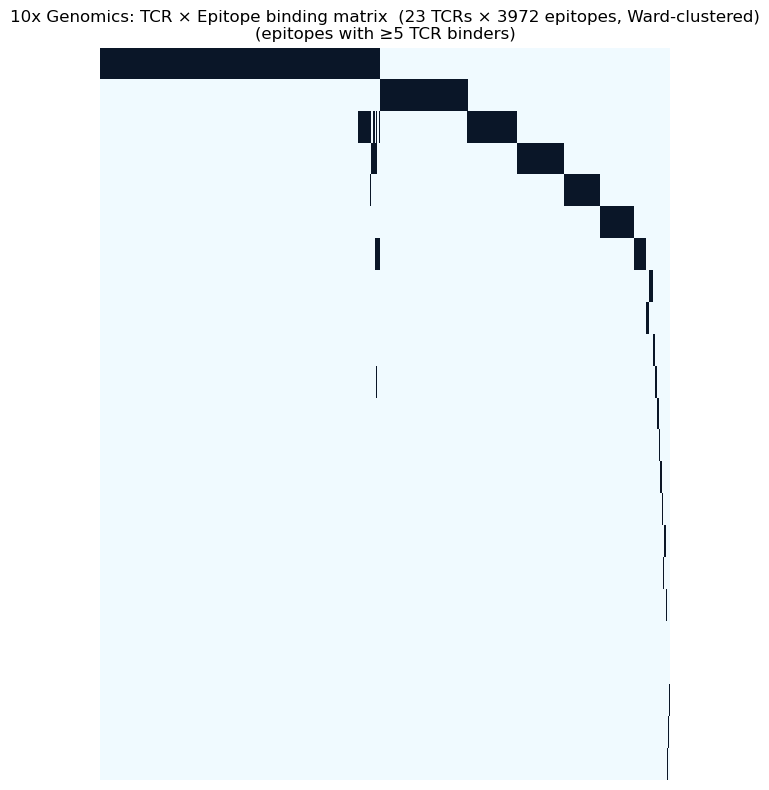

Exported: /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix.csv  (23 TCRs × 3972 epitopes)


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ========================================================================
# LOAD AND BUILD BINARY MATRIX
# ========================================================================

binarized = pd.read_csv('vdj_v1_hs_aggregated_donor1_binarized_matrix.csv')

# Get binarized dextramer columns
binder_cols = [col for col in binarized.columns if col.endswith('_binder')]
tcr_col = 'cell_clono_cdr3_aa'

# Build matrix
data = binarized[binarized[tcr_col].notna()][[tcr_col] + binder_cols].copy()
for col in binder_cols:
    data[col] = data[col].astype(int)

matrix = data.rename(columns={tcr_col: 'TCR'}).groupby('TCR').max()

print(f"Full matrix: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")

# ========================================================================
# FILTER OPTIONS
# ========================================================================

# ----- Filtering logic: binders per epitope and epitopes per binder -----
# Set filter thresholds (set to None to disable a filter)
min_tcrs_per_epitope = 5     # Each epitope must have at least this many TCR binders
max_tcrs_per_epitope = 2000   # ...and at most this many TCR binders (or None for no max)
min_epitopes_per_tcr = 1      # Each TCR must bind at least this many epitopes
max_epitopes_per_tcr = None   # ...and at most this many epitopes (or None for no max)

# Epitope-level filtering
tcrs_per_epitope = (matrix > 0).sum(axis=0)
mask_epitopes = tcrs_per_epitope >= min_tcrs_per_epitope
if max_tcrs_per_epitope is not None:
    mask_epitopes &= (tcrs_per_epitope <= max_tcrs_per_epitope)
matrix = matrix.loc[:, mask_epitopes]

# TCR-level filtering (done after epitope filtering, since some TCRs may lose all their binders)
epitopes_per_tcr = (matrix > 0).sum(axis=1)
mask_tcrs = epitopes_per_tcr >= min_epitopes_per_tcr
if max_epitopes_per_tcr is not None:
    mask_tcrs &= (epitopes_per_tcr <= max_epitopes_per_tcr)
matrix = matrix.loc[mask_tcrs, :]

print(f"Epitopes with ≥{min_tcrs_per_epitope} TCR(s): {matrix.shape[1]} epitopes kept")
print(f"Filtered matrix: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")

# ========================================================================
# WARD CLUSTERING
# ========================================================================

def ward_order(m):
    ro = leaves_list(linkage(pdist(m, metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

mat = matrix.values
row_order, col_order = ward_order(mat)
# mat is a numpy ndarray after this transformation
mat = 1 - mat[np.ix_(row_order, col_order)]
mat = mat.T

# ========================================================================
# PLOT
# ========================================================================

lake_colors = ["#0a1628","#0d2b4e","#0e4272","#0e5c8a","#1278a0",
               "#2a9ab5","#5bbccc","#9dd8e0","#cdeef5","#f0faff"]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(mat, aspect='auto', cmap=lake_cmap, vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

title = f"10x Genomics: TCR × Epitope binding matrix  ({mat.shape[0]} TCRs × {mat.shape[1]} epitopes, Ward-clustered)"
if min_tcrs_per_epitope > 1:
    title += f"\n(epitopes with ≥{min_tcrs_per_epitope} TCR binders)"
ax.set_title(title, fontsize=12)

plt.tight_layout()
#plt.savefig("10x_tcr_epitope_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Export filtered matrix for three-panel plot ─────────────────────────────
GENOMICS_CSV = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix.csv"

# Because mat is now a numpy ndarray, we need something to export.
# Let's create a DataFrame wrapper, using the clustered row/col order
# Get TCR and epitope labels according to the clustering order
tcr_labels = matrix.index[row_order] if hasattr(matrix, 'index') and hasattr(row_order, '__len__') and len(matrix.index) == mat.shape[1] else [f"TCR_{i}" for i in range(mat.shape[1])]
epitope_labels = matrix.columns[col_order] if hasattr(matrix, 'columns') and hasattr(col_order, '__len__') and len(matrix.columns) == mat.shape[0] else [f"Epitope_{i}" for i in range(mat.shape[0])]
# mat was transposed, so rows are epitopes, columns are TCRs
df_mat = pd.DataFrame(mat, index=epitope_labels, columns=tcr_labels)
df_mat.to_csv(GENOMICS_CSV)
print(f"Exported: {GENOMICS_CSV}  ({mat.shape[0]} TCRs × {mat.shape[1]} epitopes)")

Full matrix: 29618 TCRs × 50 epitopes
Epitopes with ≥1 TCR(s): 31 epitopes kept
Filtered matrix: 3989 TCRs × 31 epitopes


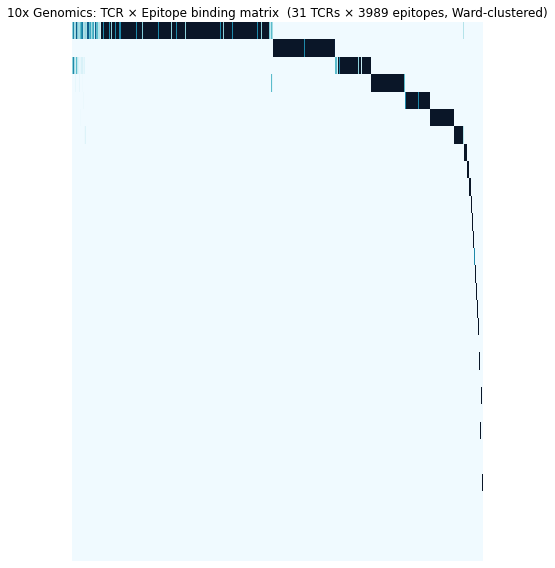

Exported: /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv  (31 TCRs × 3989 epitopes)


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# ========================================================================
# LOAD AND BUILD BINARY MATRIX
# ========================================================================

binarized = pd.read_csv('vdj_v1_hs_aggregated_donor1_binarized_matrix.csv')

# Get binarized dextramer columns
binder_cols = [col for col in binarized.columns if col.endswith('_binder')]
tcr_col = 'cell_clono_cdr3_aa'

# Build matrix
data = binarized[binarized[tcr_col].notna()][[tcr_col] + binder_cols].copy()
for col in binder_cols:
    data[col] = data[col].astype(int)

# Use MEAN to get the fraction of cells with this TCR that bind each epitope
matrix = data.rename(columns={tcr_col: 'TCR'}).groupby('TCR').mean()

print(f"Full matrix: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")

# ========================================================================
# FILTER OPTIONS
# ========================================================================

# ----- Filtering logic: binders per epitope and epitopes per binder -----
# Set filter thresholds (set to None to disable a filter)
min_tcrs_per_epitope = 1     # Each epitope must have at least this many TCR binders
max_tcrs_per_epitope = 5000   # ...and at most this many TCR binders (or None for no max)
min_epitopes_per_tcr = 0.1      # Each TCR must bind at least this many epitopes
max_epitopes_per_tcr = None   # ...and at most this many epitopes (or None for no max)

# Epitope-level filtering
tcrs_per_epitope = (matrix > 0).sum(axis=0)
mask_epitopes = tcrs_per_epitope >= min_tcrs_per_epitope
if max_tcrs_per_epitope is not None:
    mask_epitopes &= (tcrs_per_epitope <= max_tcrs_per_epitope)
matrix = matrix.loc[:, mask_epitopes]

# TCR-level filtering (done after epitope filtering, since some TCRs may lose all their binders)
epitopes_per_tcr = (matrix > 0).sum(axis=1)
mask_tcrs = epitopes_per_tcr >= min_epitopes_per_tcr
if max_epitopes_per_tcr is not None:
    mask_tcrs &= (epitopes_per_tcr <= max_epitopes_per_tcr)
matrix = matrix.loc[mask_tcrs, :]

print(f"Epitopes with ≥{min_tcrs_per_epitope} TCR(s): {matrix.shape[1]} epitopes kept")
print(f"Filtered matrix: {matrix.shape[0]} TCRs × {matrix.shape[1]} epitopes")

# ========================================================================
# WARD CLUSTERING
# ========================================================================

def ward_order(m, metric='euclidean', method='ward'):
    ro = leaves_list(linkage(pdist(m, metric=metric), method=method))
    co = leaves_list(linkage(pdist(m.T, metric=metric), method=method))
    return ro, co

mat = matrix.values
metric = 'correlation'
method = 'ward'
row_order, col_order = ward_order(mat, metric=metric, method=method)
# mat is a numpy ndarray after this transformation
mat = 1 - mat[np.ix_(row_order, col_order)]
mat = mat.T

# ========================================================================
# PLOT
# ========================================================================

lake_colors = ["#0a1628","#0d2b4e","#0e4272","#0e5c8a","#1278a0",
               "#2a9ab5","#5bbccc","#9dd8e0","#cdeef5","#f0faff"]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)

fig, ax = plt.subplots(figsize=(6, 8))
ax.imshow(mat, aspect='auto', cmap=lake_cmap, vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(False)

title = f"10x Genomics: TCR × Epitope binding matrix  ({mat.shape[0]} TCRs × {mat.shape[1]} epitopes, Ward-clustered)"
if min_tcrs_per_epitope > 1:
    title += f"\n(epitopes with ≥{min_tcrs_per_epitope} TCR binders)"
ax.set_title(title, fontsize=12)

plt.tight_layout()
#plt.savefig("10x_tcr_epitope_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Export filtered matrix for three-panel plot ─────────────────────────────
GENOMICS_CSV = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv"

# Because mat is now a numpy ndarray, we need something to export.
# Let's create a DataFrame wrapper, using the clustered row/col order
# Get TCR and epitope labels according to the clustering order
tcr_labels = matrix.index[row_order] if hasattr(matrix, 'index') and hasattr(row_order, '__len__') and len(matrix.index) == mat.shape[1] else [f"TCR_{i}" for i in range(mat.shape[1])]
epitope_labels = matrix.columns[col_order] if hasattr(matrix, 'columns') and hasattr(col_order, '__len__') and len(matrix.columns) == mat.shape[0] else [f"Epitope_{i}" for i in range(mat.shape[0])]
# mat was transposed, so rows are epitopes, columns are TCRs
df_mat = pd.DataFrame(mat, index=epitope_labels, columns=tcr_labels)
df_mat.to_csv(GENOMICS_CSV)
print(f"Exported: {GENOMICS_CSV}  ({mat.shape[0]} TCRs × {mat.shape[1]} epitopes)")

Score matrix: 6164 TCRs × 38 epitopes
Score range: 0.0000 - 1.0000

TCRs with binding score > 0.99: 6164


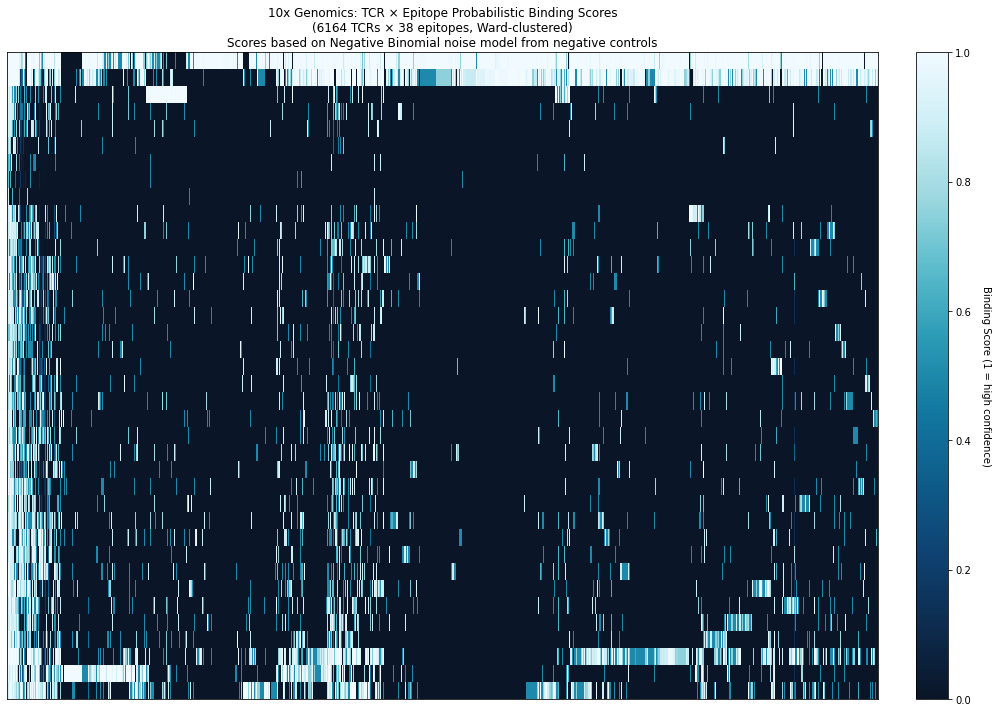


✓ Saved: 10x_tcr_epitope_probabilistic_scores.png


In [31]:
# ========================================================================
# AGGREGATE BINDING SCORES BY TCR
# ========================================================================

# Get epitope columns
epitope_cols = [col for col in binding_scores.columns if col.startswith(('A0', 'B0', 'C0'))]

# Aggregate by TCR - use max binding score across cells
score_matrix = binding_scores[['TCR'] + epitope_cols].groupby('TCR').max()

# Filter to TCRs with at least one strong binding (score > 0.9)
score_threshold = 0.99
score_matrix = score_matrix[(score_matrix > score_threshold).sum(axis=1) > 0]

print(f"Score matrix: {score_matrix.shape[0]} TCRs × {score_matrix.shape[1]} epitopes")
print(f"Score range: {score_matrix.values.min():.4f} - {score_matrix.values.max():.4f}")
print(f"\nTCRs with binding score > {score_threshold}: {score_matrix.shape[0]}")

# ========================================================================
# PLOT BINDING SCORE HEATMAP
# ========================================================================

# Ward clustering
mat = score_matrix.values
row_order, col_order = ward_order(mat)
mat =  mat[np.ix_(row_order, col_order)].T

# Plot
lake_colors = ["#0a1628","#0d2b4e","#0e4272","#0e5c8a","#1278a0",
               "#2a9ab5","#5bbccc","#9dd8e0","#cdeef5","#f0faff"]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(mat, aspect='auto', cmap=lake_cmap, 
               vmin=0, vmax=1, interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.8)

ax.set_title(
    f"10x Genomics: TCR × Epitope Probabilistic Binding Scores\n"
    f"({score_matrix.shape[0]} TCRs × {score_matrix.shape[1]} epitopes, Ward-clustered)\n"
    f"Scores based on Negative Binomial noise model from negative controls",
    fontsize=12
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Binding Score (1 = high confidence)', rotation=270, labelpad=20)

plt.tight_layout()
#plt.savefig("10x_tcr_epitope_probabilistic_scores.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Saved: 10x_tcr_epitope_probabilistic_scores.png")

## Plot together

(693, 78)
Index(['SFR', 'XLYOFNOQVPJJNP-UHFFFAOYSA-N', 'VHUUQVKOLVNVRT-UHFFFAOYSA-N',
       'KIDHWZJUCRJVML-UHFFFAOYSA-N', 'VHRGRCVQAFMJIZ-UHFFFAOYSA-N'],
      dtype='object')
Index(['ac1A', 'ac1B', 'ac2A', 'ac2B', 'ac3A'], dtype='object')
Clean matrix: (648, 74)
Value range: -1.000 – 0.000


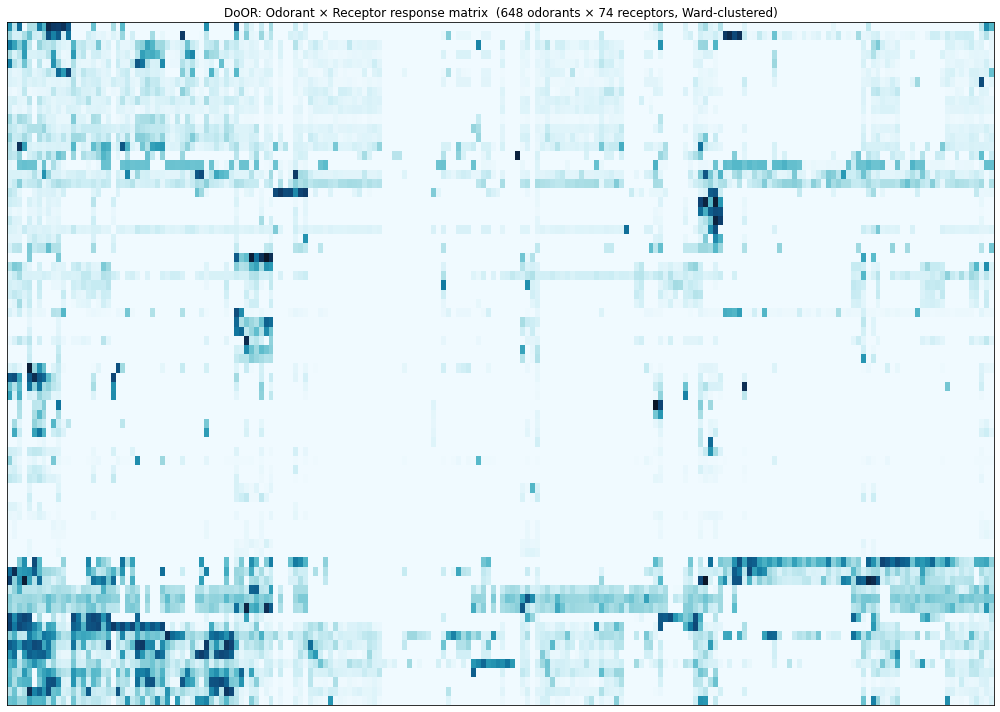

In [68]:
# The consensus matrix is on GitHub as a CSV
import pandas as pd

path = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/door_response_matrix.csv"
door = pd.read_csv(path, sep=';', index_col=0)

print(door.shape)       # expect (693, 78)
print(door.index[:5])   # odorant IDs
print(door.columns[:5]) # receptor names


# Convert to float (some entries may be strings)
door = door.apply(pd.to_numeric, errors='coerce')

# Drop rows/cols that are all NaN
door = door.dropna(how='all', axis=0).dropna(how='all', axis=1)
door = -door

# Fill remaining NaN with 0 (no response recorded)
door = door.fillna(0)

print(f"Clean matrix: {door.shape}")
print(f"Value range: {door.values.min():.3f} – {door.values.max():.3f}")

# ── Ward clustering ───────────────────────────────────────────────────────────
def ward_order(m):
    ro = leaves_list(linkage(pdist(m,   metric='euclidean'), method='ward'))
    co = leaves_list(linkage(pdist(m.T, metric='euclidean'), method='ward'))
    return ro, co

mat_sub = door.values[:200, :]  # Ensure it's a square matrix for clustering

row_order, col_order = ward_order(mat_sub)
mat = mat_sub[np.ix_(row_order, col_order)].T  # Use np.ix_ to index rows and cols properly
#mat = mat_sub

# ── Plot ──────────────────────────────────────────────────────────────────────
lake_colors = ["#0a1628","#0d2b4e","#0e4272","#0e5c8a","#1278a0",
               "#2a9ab5","#5bbccc","#9dd8e0","#cdeef5","#f0faff"]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(mat, aspect='auto', cmap=lake_cmap,
          vmin=door.values.min(), vmax=door.values.max(),
#          vmin = 0, vmax = 6,
          interpolation='nearest')
ax.set_xticks([])
ax.set_yticks([])
for sp in ax.spines.values():
    sp.set_visible(True)
    sp.set_linewidth(0.8)
ax.set_title(
    f"DoOR: Odorant × Receptor response matrix  ({door.shape[0]} odorants × {door.shape[1]} receptors, Ward-clustered)",
    fontsize=12
)
plt.tight_layout()
#plt.savefig("door_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

In [70]:
# Save clustered matrix as a DataFrame before writing to Excel
subbed_df = pd.DataFrame(mat)
with pd.ExcelWriter("door_data_subbed.xlsx", engine='openpyxl') as writer:
    subbed_df.to_excel(writer, sheet_name='subbed')


(306, 96)
(200, 74)
(23, 3972)


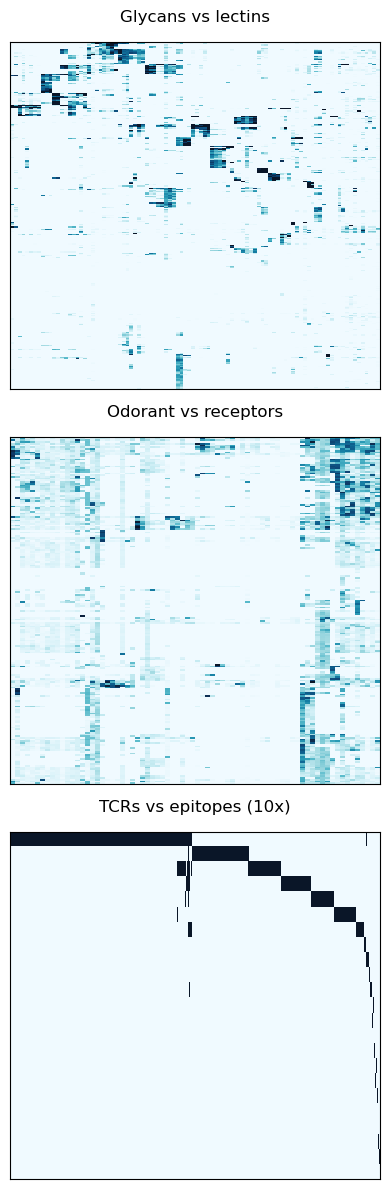

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Set to True to use Ward clustering (clustered heatmaps); False to keep raw/original order
DO_WARD_CLUSTERING = True

# ── LakeColors approximation ──────────────────────────────────────────────────
lake_colors = [
    "#0a1628", "#0d2b4e", "#0e4272", "#0e5c8a", "#1278a0",
    "#2a9ab5", "#5bbccc", "#9dd8e0", "#cdeef5", "#f0faff"
]
lake_cmap       = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)
lake_cmap_r     = mcolors.LinearSegmentedColormap.from_list("LakeColors_r", lake_colors[::-1])

metric = 'cosine'
metric = 'euclidean'
def ward_order(matrix):
    """Return row and column leaf orders from Ward clustering."""
    row_order = leaves_list(linkage(pdist(matrix,           metric='euclidean'), method='ward'))
    col_order = leaves_list(linkage(pdist(matrix.T,         metric='euclidean'), method='ward'))
    return row_order, col_order

def plot_matrix(ax, data, cmap, vmin, vmax, do_cluster):
    if do_cluster:
        row_order, col_order = ward_order(data)
        reordered = data[np.ix_(row_order, col_order)]
    else:
        reordered = data
    im = ax.imshow(reordered, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.8)
    return im

# Use white background for the entire figure
fig, axes = plt.subplots(3, 1, figsize=(4, 12), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# ── Plot 1: GlycanData.xlsx ───────────────────────────────────────────────────
raw1 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/GlycanData.xlsx",
    header=None, sheet_name=0
).values
dat1 = raw1[::2, ::1].astype(float)
print(dat1.shape)

plot_matrix(axes[0], dat1, cmap=lake_cmap_r, vmin=0, vmax=10, do_cluster=DO_WARD_CLUSTERING)
axes[0].set_title("Glycans vs lectins", fontsize=12, color='black', pad=15)

# # ── Plot 2: 2000016_TableS3.xls ──────────────────────────────────────────────
# raw2 = pd.read_excel(
#     "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/2000016_TableS3.xls",
#     header=None, sheet_name=0
# ).values
# dat2 = raw2[1:, 1:].astype(float).T

# plot_matrix(axes[1], dat2, cmap=lake_cmap, vmin=-6, vmax=0, do_cluster=DO_WARD_CLUSTERING)
# axes[1].set_title("Odorant vs receptors", fontsize=12, color='black', pad=15)

# ── Plot 2: door_data_subbed.xlsx ──────────────────────────────────────────────
raw2 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/door_data_subbed.xlsx",
    header=None, sheet_name=0
).values
dat2 = raw2[1:, 1:].astype(float).T
print(dat2.shape)

plot_matrix(axes[1], dat2, cmap=lake_cmap, vmin=dat2.min(), vmax=dat2.max(), do_cluster=DO_WARD_CLUSTERING)
axes[1].set_title("Odorant vs receptors", fontsize=12, color='black', pad=15)

# # ── Plot 3: atlas_binding_matrix.xlsx ────────────────────────────────────────
# df3  = pd.read_excel(
#     "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/atlas_binding_matrix.xlsx",
#     sheet_name="Kd_filled_uM", index_col=0
# )
# dat3 = (-df3.values.astype(float)).T
# print(dat3.shape)

# plot_matrix(axes[2], dat3, cmap=lake_cmap_r, vmin=dat3.min(), vmax=dat3.max(), do_cluster=DO_WARD_CLUSTERING)
# axes[2].set_title("Antigens vs antibodies", fontsize=12, color='black', pad=15)

# ── Plot 3: 10x TCR × epitope binding matrix ─────────────────────────────────
df3 = pd.read_csv(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv",
    index_col=0
)
dat3 = df3.values.astype(float)
print(dat3.shape)

plot_matrix(axes[2], dat3, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING)
axes[2].set_title("TCRs vs epitopes (10x)", fontsize=12, color='black', pad=15)

plt.tight_layout()
plt.savefig("three_matrices.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

(306, 96)
(200, 74)
(23, 3972)


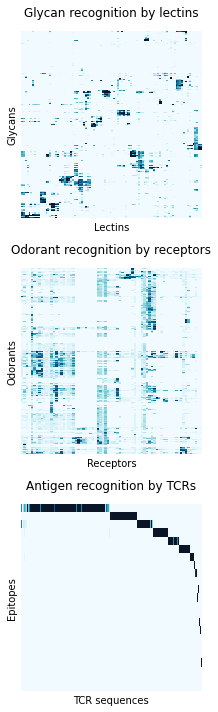

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Set to True to use Ward clustering (clustered heatmaps); False to keep raw/original order
DO_WARD_CLUSTERING = True

# ── LakeColors approximation ──────────────────────────────────────────────────
lake_colors = [
    "#0a1628", "#0d2b4e", "#0e4272", "#0e5c8a", "#1278a0",
    "#2a9ab5", "#5bbccc", "#9dd8e0", "#cdeef5", "#f0faff"
]
lake_cmap       = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)
lake_cmap_r     = mcolors.LinearSegmentedColormap.from_list("LakeColors_r", lake_colors[::-1])


metric = 'correlation'
method = 'ward'

def ward_order(matrix,):
    """Return row and column leaf orders from Ward clustering."""
    row_order = leaves_list(linkage(pdist(matrix,           metric=metric), method=method))
    col_order = leaves_list(linkage(pdist(matrix.T,         metric=metric), method=method))
    return row_order, col_order

def plot_matrix(ax, data, cmap, vmin, vmax, do_cluster, title=None, bottomx_label=None, lefty_label=None):
    if do_cluster:
        row_order, col_order = ward_order(data)
        reordered = data[np.ix_(row_order, col_order)]
    else:
        reordered = data
    im = ax.imshow(reordered, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.0)
    if title:
        ax.set_title(title, fontsize=12, color='black', pad=15)
    if bottomx_label:
        ax.set_xlabel(bottomx_label, fontsize=10)
    if lefty_label:
        ax.set_ylabel(lefty_label, fontsize=10)
    return im

# Use white background for the entire figure
fig, axes = plt.subplots(3, 1, figsize=(3, 10), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# ── Plot 1: GlycanData.xlsx ───────────────────────────────────────────────────
raw1 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/GlycanData.xlsx",
    header=None, sheet_name=0
).values
dat1 = raw1[::2, ::1].astype(float)
print(dat1.shape)

plot_matrix(
    axes[0], dat1, cmap=lake_cmap_r, vmin=0, vmax=10, do_cluster=DO_WARD_CLUSTERING,
    title="Glycan recognition by lectins", bottomx_label="Lectins", lefty_label="Glycans"
)

# ── Plot 2: door_data_subbed.xlsx ──────────────────────────────────────────────
raw2 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/door_data_subbed.xlsx",
    header=None, sheet_name=0
).values
dat2 = raw2[1:, 1:].astype(float).T
print(dat2.shape)

plot_matrix(
    axes[1], dat2, cmap=lake_cmap, vmin=dat2.min(), vmax=dat2.max(), do_cluster=DO_WARD_CLUSTERING,
    title="Odorant recognition by receptors", bottomx_label="Receptors", lefty_label="Odorants"
)

# ── Plot 3: 10x TCR × epitope binding matrix ─────────────────────────────────
df3 = pd.read_csv(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv",
    index_col=0
)
dat3 = df3.values.astype(float)
print(dat3.shape)

plot_matrix(
    axes[2], dat3, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
    title="Antigen recognition by TCRs", bottomx_label="TCR sequences", lefty_label="Epitopes"
)

plt.tight_layout()
plt.savefig("three_matrices.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# Set to True to use Ward clustering (clustered heatmaps); False to keep raw/original order
DO_WARD_CLUSTERING = True

# ── LakeColors approximation ──────────────────────────────────────────────────
lake_colors = [
    "#0a1628", "#0d2b4e", "#0e4272", "#0e5c8a", "#1278a0",
    "#2a9ab5", "#5bbccc", "#9dd8e0", "#cdeef5", "#f0faff"
]
lake_cmap       = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)
lake_cmap_r     = mcolors.LinearSegmentedColormap.from_list("LakeColors_r", lake_colors[::-1])


metric = 'correlation'
method = 'ward'

def ward_order(matrix,):
    """Return row and column leaf orders from Ward clustering."""
    row_order = leaves_list(linkage(pdist(matrix,           metric=metric), method=method))
    col_order = leaves_list(linkage(pdist(matrix.T,         metric=metric), method=method))
    return row_order, col_order

def plot_matrix(ax, data, cmap, vmin, vmax, do_cluster, title=None, bottomx_label=None, lefty_label=None):
    if do_cluster:
        row_order, col_order = ward_order(data)
        reordered = data[np.ix_(row_order, col_order)]
    else:
        reordered = data
    im = ax.imshow(reordered, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.0)
    if title:
        ax.set_title(title, fontsize=12, color='black', pad=15)
    if bottomx_label:
        ax.set_xlabel(bottomx_label, fontsize=10)
    if lefty_label:
        ax.set_ylabel(lefty_label, fontsize=10)
    return im

# Use white background for the entire figure
fig, axes = plt.subplots(3, 1, figsize=(3, 10), facecolor='white')
for ax in axes:
    ax.set_facecolor('white')

# ── Plot 1: GlycanData.xlsx ───────────────────────────────────────────────────
raw1 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/GlycanData.xlsx",
    header=None, sheet_name=0
).values
dat1 = raw1[::2, ::1].astype(float)
print(dat1.shape)

plot_matrix(
    axes[0], dat1, cmap=lake_cmap_r, vmin=0, vmax=10, do_cluster=DO_WARD_CLUSTERING,
    title="Glycan recognition by lectins", bottomx_label="Lectins", lefty_label="Glycans"
)

# ── Plot 2: door_data_subbed.xlsx ──────────────────────────────────────────────
raw2 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/door_data_subbed.xlsx",
    header=None, sheet_name=0
).values
dat2 = raw2[1:, 1:].astype(float).T
print(dat2.shape)

plot_matrix(
    axes[1], dat2, cmap=lake_cmap, vmin=dat2.min(), vmax=dat2.max(), do_cluster=DO_WARD_CLUSTERING,
    title="Odorant recognition by receptors", bottomx_label="Receptors", lefty_label="Odorants"
)

# ── Plot 3: 10x TCR × epitope binding matrix ─────────────────────────────────
df3 = pd.read_csv(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv",
    index_col=0
)
dat3 = df3.values.astype(float)
print(dat3.shape)

plot_matrix(
    axes[2], dat3, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
    title="Antigen recognition by TCRs", bottomx_label="TCR sequences", lefty_label="Epitopes"
)

plt.tight_layout()
#plt.savefig("three_matrices.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Dataset 1 (Glycans):
  Original range: -1.16 - 34.07
  Normalized range: 0.00 - 1.00
  (Reversed: lower raw values → higher binding scores)

Dataset 2 (Odorants):
  Original range: -1.00 - 0.00
  Normalized range: 0.00 - 1.00
  (Normal: higher raw values → higher binding scores)

Dataset 3 (TCRs):
  Original range: 0.00 - 1.00
  Normalized range: 0.00 - 1.00
  (Normal: higher raw values → higher binding scores)

All datasets now: 0 = no binding, 1 = binding


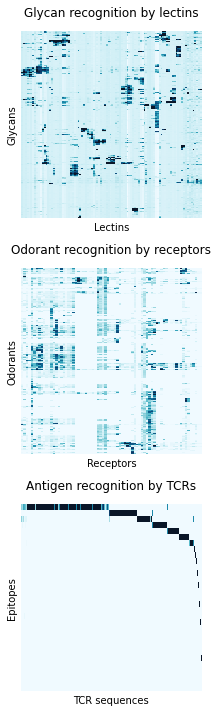

In [91]:
# ========================================================================
# NORMALIZE & PLOT ALL DATASETS TO 0-1 SCALE (0 = no bind, 1 = bind)
# ========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist

# --- Configurable options ---
transform = None
lower_clip_percentile = 0
upper_clip_percentile = 99
DO_WARD_CLUSTERING = True
metric = 'correlation'
method = 'ward'

# NEW: Option to save individual figures from plot_all_normalized_matrices
SAVE_EACH = False  # Set to True to save each plot separately
SAVE_DIR = "./normalized_plots/"  # Edit or use full path as needed
SAVE_FORMAT = "png"  # e.g., "png", "pdf", etc.

import os
if SAVE_EACH and not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR, exist_ok=True)

# --- Helper colormap setup ---
lake_colors = [
    "#0a1628", "#0d2b4e", "#0e4272", "#0e5c8a", "#1278a0",
    "#2a9ab5", "#5bbccc", "#9dd8e0", "#cdeef5", "#f0faff"
]
lake_cmap       = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)
lake_cmap_r     = mcolors.LinearSegmentedColormap.from_list("LakeColors_r", lake_colors[::-1])

def normalize_to_binding_scale(data, reverse=False, transform='linear', clip_percentile=99):
    """
    Normalize data to 0-1 where 0 = no binding, 1 = binding.

    transform options:
    - 'linear': standard min-max scaling
    - 'log': log10(x + 1) - good for wide dynamic range
    - 'sqrt': square root - softer than log
    - 'percentile': clip to 95th percentile, then scale
    - 'asinh': inverse hyperbolic sine - handles zeros, used in flow cytometry
    """
    arr = np.array(data, dtype=np.float64, copy=True)
    # Clip to percentile to control outliers
    vmin = np.percentile(arr, lower_clip_percentile)
    vmax = np.percentile(arr, upper_clip_percentile)
    arr = np.clip(arr, vmin, vmax)

    # Linear min-max scaling
    norm = (arr - arr.min()) / (arr.max() - arr.min())

    # Reverse if needed
    if reverse:
        norm = 1 - norm

    if transform is None or transform == 'linear':
        pass
    elif transform == 'log':
        norm = np.log10(norm + 1)
    elif transform == 'sqrt':
        norm = np.sqrt(norm)
    elif transform == 'asinh':
        norm = np.arcsinh(norm)
    elif transform == 'percentile':
        p95 = np.percentile(norm, 95)
        norm = np.clip(norm, 0, p95)
    else:
        raise ValueError(f"Unknown transform: {transform}")
    return norm

def ward_order(matrix):
    """Return row and column leaf order from Ward clustering."""
    row_order = leaves_list(linkage(pdist(matrix,   metric=metric), method=method))
    col_order = leaves_list(linkage(pdist(matrix.T, metric=metric), method=method))
    return row_order, col_order

def plot_matrix(ax, data, cmap, vmin, vmax, do_cluster, title=None, bottomx_label=None, lefty_label=None, flipud=False):
    arr = np.array(data)
    if do_cluster:
        row_order, col_order = ward_order(arr)
        arr = arr[np.ix_(row_order, col_order)]
    if flipud:
        arr = np.flipud(arr)
    im = ax.imshow(arr, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.0)
    if title:
        ax.set_title(title, fontsize=12, color='black', pad=15)
    if bottomx_label:
        ax.set_xlabel(bottomx_label, fontsize=10)
    if lefty_label:
        ax.set_ylabel(lefty_label, fontsize=10)
    return im

def load_and_normalize_datasets(transform=None, clip_percentile=99.5):
    # Dataset 1: Glycan data (LOWER = more bind, use reverse)
    raw1 = pd.read_excel(
        "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/GlycanData.xlsx",
        header=None, sheet_name=0
    ).values
    dat1 = raw1[::2, :].astype(float)
    dat1_norm = normalize_to_binding_scale(dat1, reverse=True, transform=transform, clip_percentile=clip_percentile)

    # Dataset 2: Odorant data (HIGHER = more bind)
    raw2 = pd.read_excel(
        "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/door_data_subbed.xlsx",
        header=None, sheet_name=0
    ).values
    dat2 = raw2[1:, 1:].astype(float).T
    dat2_norm = normalize_to_binding_scale(dat2, reverse=False, transform=transform, clip_percentile=clip_percentile)

    # Dataset 3: TCR x epitope matrix (already [0,1]; just clip/transform if wanted)
    df3 = pd.read_csv(
        "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/10x_tcr_epitope_matrix_probs.csv",
        index_col=0
    )
    dat3 = df3.values.astype(float)
    dat3_norm = normalize_to_binding_scale(dat3, reverse=False, transform=transform, clip_percentile=clip_percentile)

    # Print ranges for debug
    print("Dataset 1 (Glycans):")
    print(f"  Original range: {dat1.min():.2f} - {dat1.max():.2f}")
    print(f"  Normalized range: {dat1_norm.min():.2f} - {dat1_norm.max():.2f}")
    print(f"  (Reversed: lower raw values → higher binding scores)\n")

    print("Dataset 2 (Odorants):")
    print(f"  Original range: {dat2.min():.2f} - {dat2.max():.2f}")
    print(f"  Normalized range: {dat2_norm.min():.2f} - {dat2_norm.max():.2f}")
    print(f"  (Normal: higher raw values → higher binding scores)\n")

    print("Dataset 3 (TCRs):")
    print(f"  Original range: {dat3.min():.2f} - {dat3.max():.2f}")
    print(f"  Normalized range: {dat3_norm.min():.2f} - {dat3_norm.max():.2f}")
    print(f"  (Normal: higher raw values → higher binding scores)\n")

    print("="*60)
    print("All datasets now: 0 = no binding, 1 = binding")
    print("="*60)

    return dat1_norm, dat2_norm, dat3_norm

def plot_all_normalized_matrices(transform=None, clip_percentile=99.5, save_each=False, save_dir="./normalized_plots/", save_format="png"):
    dat1_norm, dat2_norm, dat3_norm = load_and_normalize_datasets(transform, clip_percentile)
    
    # Plot all together as before (the grid)
    fig, axes = plt.subplots(3, 1, figsize=(3, 10), facecolor='white')
    for ax in axes:
        ax.set_facecolor('white')

    plot_matrix(
        axes[0], dat1_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,   
        title="Glycan recognition by lectins", bottomx_label="Lectins", lefty_label="Glycans", flipud=True
    )
    plot_matrix(
        axes[1], dat2_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
        title="Odorant recognition by receptors", bottomx_label="Receptors", lefty_label="Odorants", flipud=True
    )
    plot_matrix(
        axes[2], dat3_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
        title="Antigen recognition by TCRs", bottomx_label="TCR sequences", lefty_label="Epitopes"
    )
    plt.tight_layout()
    #plt.savefig("three_matrices.png", dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # --- Add: Save each matrix as a separate figure if required
    if save_each:
        # List of (data, title, xlabel, ylabel, flipud, filename)
        plot_params = [
            (dat1_norm, "Glycan recognition by lectins", "Lectins", "Glycans", True, "glycan_vs_lectin"),
            (dat2_norm, "Odorant recognition by receptors", "Receptors", "Odorants", True, "odorant_vs_receptor"),
            (dat3_norm, "Antigen recognition by TCRs", "TCR sequences", "Epitopes", False, "tcr_vs_epitope"),
        ]
        for arr, title, xlabel, ylabel, flipud_flag, fname in plot_params:
            fig1, ax1 = plt.subplots(1, 1, figsize=(4, 4), facecolor='white')
            ax1.set_facecolor('white')
            plot_matrix(
                ax1, arr, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
                title=title, bottomx_label=xlabel, lefty_label=ylabel, flipud=flipud_flag,
            )
            plt.tight_layout()
            savename = os.path.join(save_dir, f"{fname}.{save_format}")
            fig1.savefig(savename, dpi=150, bbox_inches='tight', facecolor='white')
            print(f"Saved: {savename}")
            plt.close(fig1)

# Actually run
plot_all_normalized_matrices(
    transform=transform, 
    clip_percentile=upper_clip_percentile, 
    save_each=SAVE_EACH, 
    save_dir=SAVE_DIR, 
    save_format=SAVE_FORMAT
)

### plotting and saving

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import font_manager
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist
import os

# --- Set global font to Arial ---
plt.rcParams['font.family'] = 'Arial'

# --- Global configurable options ---
transform = None
lower_clip_percentile = 0
upper_clip_percentile = 99
DO_WARD_CLUSTERING = True
metric = 'correlation'
method = 'ward'

SAVE_DIR = "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/"
SAVE_FORMAT = "png"

if SAVE_EACH and not os.path.exists(SAVE_DIR):
    os.makedirs(SAVE_DIR, exist_ok=True)

# --- Helper colormap setup ---
lake_colors = [
    "#0a1628", "#0d2b4e", "#0e4272", "#0e5c8a", "#1278a0",
    "#2a9ab5", "#5bbccc", "#9dd8e0", "#cdeef5", "#f0faff"
]
lake_cmap = mcolors.LinearSegmentedColormap.from_list("LakeColors", lake_colors)
lake_cmap_r = mcolors.LinearSegmentedColormap.from_list("LakeColors_r", lake_colors[::-1])

def normalize_to_binding_scale(data, reverse=False, transform='linear', clip_percentile=99):
    """
    Normalize data to 0-1 where 0 = no binding, 1 = binding.

    transform options:
    - 'linear': standard min-max scaling
    - 'log': log10(x + 1) - good for wide dynamic range
    - 'sqrt': square root - softer than log
    - 'percentile': clip to 95th percentile, then scale
    - 'asinh': inverse hyperbolic sine - handles zeros, used in flow cytometry
    """
    arr = np.array(data, dtype=np.float64, copy=True)
    vmin = np.percentile(arr, lower_clip_percentile)
    vmax = np.percentile(arr, upper_clip_percentile)
    arr = np.clip(arr, vmin, vmax)
    norm = (arr - arr.min()) / (arr.max() - arr.min())
    
    if reverse:
        norm = 1 - norm

    if transform is None or transform == 'linear':
        pass
    elif transform == 'log':
        norm = np.log10(norm + 1)
    elif transform == 'sqrt':
        norm = np.sqrt(norm)
    elif transform == 'asinh':
        norm = np.arcsinh(norm)
    elif transform == 'percentile':
        p95 = np.percentile(norm, 95)
        norm = np.clip(norm, 0, p95)
    else:
        raise ValueError(f"Unknown transform: {transform}")
    return norm

def ward_order(matrix):
    """Return row and column leaf order from Ward clustering."""
    row_order = leaves_list(linkage(pdist(matrix, metric=metric), method=method))
    col_order = leaves_list(linkage(pdist(matrix.T, metric=metric), method=method))
    return row_order, col_order

def plot_matrix(ax, data, cmap, vmin, vmax, do_cluster, title=None, bottomx_label=None, lefty_label=None, flipud=False):
    arr = np.array(data)
    if do_cluster:
        row_order, col_order = ward_order(arr)
        arr = arr[np.ix_(row_order, col_order)]
    if flipud:
        arr = np.flipud(arr)
    im = ax.imshow(arr, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax,
                   interpolation='nearest')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.0)
    if title:
        ax.set_title(title, fontsize=30, color='black', pad=15, fontname='Arial')
    if bottomx_label:
        ax.set_xlabel(bottomx_label, fontsize=26, fontname='Arial')
    if lefty_label:
        ax.set_ylabel(lefty_label, fontsize=26, fontname='Arial')
    return im

fs1 = 2.25 * 2
fs2 = 2.75 * 2
print("Setup complete!")

Setup complete!


Dataset 1 (Glycans):
  Original range: -1.16 - 34.07
  Normalized range: 0.00 - 1.00
  (Reversed: lower raw values → higher binding scores)

Saved: /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/glycan_vs_lectin.png


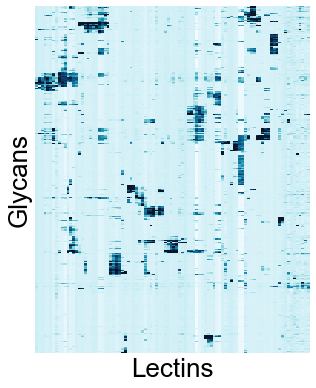

In [51]:
# Dataset 1: Glycan data (LOWER = more bind, use reverse)
raw1 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Data/GlycanData.xlsx",
    header=None, sheet_name=0
).values
dat1 = raw1[::2, :].astype(float)
dat1_norm = normalize_to_binding_scale(dat1, reverse=True, transform=transform, clip_percentile=upper_clip_percentile)

print("Dataset 1 (Glycans):")
print(f"  Original range: {dat1.min():.2f} - {dat1.max():.2f}")
print(f"  Normalized range: {dat1_norm.min():.2f} - {dat1_norm.max():.2f}")
print(f"  (Reversed: lower raw values → higher binding scores)\n")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(fs1, fs2), facecolor='white')
ax.set_facecolor('white')
plot_matrix(
    ax, dat1_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
    #title="Glycan recognition by lectins", 
    bottomx_label="Lectins", lefty_label="Glycans", flipud=True
)
plt.tight_layout()


savename = os.path.join(SAVE_DIR, f"glycan_vs_lectin.{SAVE_FORMAT}")
fig.savefig(savename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {savename}")

plt.show()

Dataset 2 (Odorants):
  Original range: -1.00 - 0.00
  Normalized range: 0.00 - 1.00
  (Normal: higher raw values → higher binding scores)

Saved: /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/odorant_vs_receptor.png


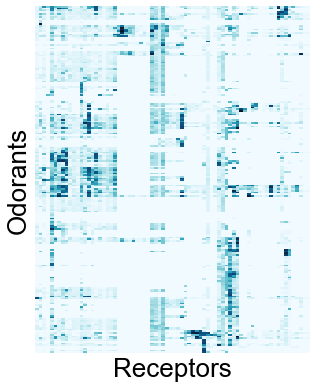

In [52]:
# Dataset 2: Odorant data (HIGHER = more bind)
raw2 = pd.read_excel(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Data/door_data_subbed.xlsx",
    header=None, sheet_name=0
).values
dat2 = raw2[1:, 1:].astype(float).T
dat2_norm = normalize_to_binding_scale(dat2, reverse=False, transform=transform, clip_percentile=upper_clip_percentile)

print("Dataset 2 (Odorants):")
print(f"  Original range: {dat2.min():.2f} - {dat2.max():.2f}")
print(f"  Normalized range: {dat2_norm.min():.2f} - {dat2_norm.max():.2f}")
print(f"  (Normal: higher raw values → higher binding scores)\n")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(fs1, fs2), facecolor='white')
ax.set_facecolor('white')
plot_matrix(
    ax, dat2_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
    #title="Odorant recognition by receptors", 
    bottomx_label="Receptors", lefty_label="Odorants", flipud=True
)
plt.tight_layout()


savename = os.path.join(SAVE_DIR, f"odorant_vs_receptor.{SAVE_FORMAT}")
fig.savefig(savename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {savename}")

plt.show()

Dataset 3 (TCRs):
  Original range: 0.00 - 1.00
  Normalized range: 0.00 - 1.00
  (Normal: higher raw values → higher binding scores)

Saved: /Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Figures/tcr_vs_epitope.png


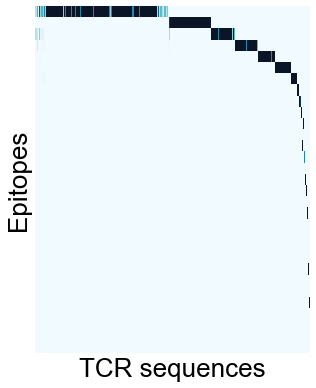


All datasets: 0 = no binding, 1 = binding


In [53]:
# Dataset 3: TCR x epitope matrix (already [0,1]; just clip/transform if wanted)
df3 = pd.read_csv(
    "/Users/csfloyd/Dropbox/Projects/GlycanAnalysis/Data/10x_tcr_epitope_matrix_probs.csv",
    index_col=0
)
dat3 = df3.values.astype(float)
dat3_norm = normalize_to_binding_scale(dat3, reverse=False, transform=transform, clip_percentile=upper_clip_percentile)

print("Dataset 3 (TCRs):")
print(f"  Original range: {dat3.min():.2f} - {dat3.max():.2f}")
print(f"  Normalized range: {dat3_norm.min():.2f} - {dat3_norm.max():.2f}")
print(f"  (Normal: higher raw values → higher binding scores)\n")

# Plot
fig, ax = plt.subplots(1, 1, figsize=(fs1, fs2), facecolor='white')
ax.set_facecolor('white')
plot_matrix(
    ax, dat3_norm, cmap=lake_cmap, vmin=0, vmax=1, do_cluster=DO_WARD_CLUSTERING,
    #title="Antigen recognition by TCRs", 
    bottomx_label="TCR sequences", lefty_label="Epitopes", flipud=False
)
plt.tight_layout()


savename = os.path.join(SAVE_DIR, f"tcr_vs_epitope.{SAVE_FORMAT}")
fig.savefig(savename, dpi=300, bbox_inches='tight', facecolor='white')
print(f"Saved: {savename}")

plt.show()

print("\n" + "="*60)
print("All datasets: 0 = no binding, 1 = binding")
print("="*60)